In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
from skrebate import ReliefF
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import random
import copy

warnings.filterwarnings("ignore")  # Optional: Suppress warnings for cleaner output

# Set environment variables to limit parallel threads
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['TORCH_NUM_THREADS'] = '1'  # For PyTorch

# ----------------------------
# Data Preparation Function
# ----------------------------

def prepare_data(file_path):
    # Load the dataset
    data = pd.read_excel(file_path)
    
    # Define feature groups
    feature_groups = {
        'Genotype': [
            # (List of genotype features as provided)
            'rs11225395', 'rs1144393', 'rs650108', 'rs591058', 'rs2252070', 'rs4986938', 'rs1800012', 'rs4789932', 
            'rs9340799', 'rs970547', 'rs1800795', 'rs13946', 'rs12722', 'class1_SNP_risk_score', 'rs7528684', 
            'rs4919510', 'rs1937810', 'rs6481512', 'rs1249269', 'rs12574452', 'rs12429486', 'rs4454832', 'rs2761884', 
            'rs62051384', 'rs4362400', 'rs2586488', 'rs2277698', 'rs1045485', 'rs143383', 'rs17576', 'rs2305948', 
            'rs1011814', 'rs11154027', 'rs2234693', 'rs1643821', 'rs2010963', 'rs10263021', 'rs149047058', 'rs420257', 
            'rs42517', 'rs42522', 'rs42531', 'rs413826', 'rs2104772', 'rs1330363', 'class12_SNP_risk_score', 'rs3753841', 
            'rs57104447', 'rs1887632', 'rs4654760', 'rs1137101', 'rs2306033', 'rs2277268', 'rs4988321', 'rs11232681', 
            'rs1718119', 'rs3751143', 'rs1544410', 'rs2228570', 'rs4328262', 'rs1021188', 'rs74544784', 'rs78391032', 
            'rs77569527', 'rs117544024', 'rs912336', 'rs3218791', 'rs911263', 'rs2525504', 'rs17756404', 'rs4903399', 
            'rs10132091', 'rs17583842', 'rs1676303', 'rs11629171', 'rs2281518', 'rs2285053', 'rs71404070', 'rs710079', 
            'rs2858056', 'rs820218', 'rs3018362', 'rs1800470', 'rs1800469', 'rs25487', 'rs25489', 'rs2289360', 
            'rs183364169', 'rs11177', 'rs6617', 'rs3219008', 'rs13107325', 'rs60713544', 'rs145648292', 'rs4244032', 
            'rs12656106', 'rs3045', 'rs187483', 'rs4701616', 'rs144414988', 'rs1800629', 'rs10484958', 'rs4730153', 
            'rs1800797', 'rs1554606', 'rs2237352', 'rs4725069', 'rs12154667', 'rs1548456', 'rs3216902', 'rs35360670', 
            'rs13317', 'rs1800972', 'rs7035322', 'rs7021589', 'rs72758637', 'rs10759753', 'rs3789870', 'rs1138545', 
            'rs3196378', 'rs1134170', 'rs10992075', 'rs1590', 'rs144371252', 'rs761804508', 'class123_SNP_risk_score', 'sex'
        ],
        'History': [
            # (List of history features as provided)
            'Age', 'lower_limb_days_total', 'average_run_hours', 'average_interval_training_frequency', 
            'EDEQ_total', 'tracking_period_injury', 'past_stress_injury', 'LEAF-Q', 'Athlete_Score', 
            'average_run_frequency', 'past_month_injury'
        ],
        'Phenotype': [
            # (List of phenotype features as provided)
            'hip_abduction_peak_torque', 'total_ad_ab_ratio', 'knee_extension_peak_torque', 
            'knee_flexion_peak_torque', 'navicular_drop', 'navicular_drop_asymmetry', 'Q_angle', 
            'Q_angle_asymmetry', 'VALR_12', 'Impact_peak_12', 'Duty_factor_12', 'BMI', 'BMD_spine',
            'hip_abduction_peak_torque_asymmetry', 'hip_adduction_peak_torque', 
            'hip_adduction_peak_torque_asymmetry', 'knee_extension_peak_torque_asymmetry', 
            'knee_flexion_peak_torque_asymmetry', 'total_fl_ex_ratio', 'leg_lean_mass', 
            'hip_abduction_peak_angle', 'hip_abduction_peak_angle_asymmetry', 'hip_adduction_peak_angle', 
            'hip_adduction_peak_angle_asymmetry', 'ad_ab_ratio_asymmetry', 'knee_extension_peak_angle', 
            'knee_extension_peak_angle_asymmetry', 'knee_flexion_peak_angle', 
            'knee_flexion_peak_angle_asymmetry', 'fl_ex_ratio_asymmetry', 'VILR_10', 'VALR_10', 
            'VILR_asymmetry_10', 'VALR_asymmetry_10', 'Impact_peak_10', 
            'Impact_peak_asymmetry_10', 'Flight_time_10', 'Contact_time_10', 
            'Duty_factor_10', 'Step_frequency_10', 'Cadence_asymmetry_10', 
            'Duty_factor_asymmetry_10', 'VILR_12', 'VILR_asymmetry_12', 'VALR_asymmetry_12', 
            'Impact_peak_asymmetry_12', 'Flight_time_12', 'Contact_time_12', 
            'Step_frequency_12', 'Cadence_asymmetry_12', 'Duty_factor_asymmetry_12', 
            'Alt_strike', 'height', 'Mass', 'thigh_lean_mass', 'thigh_ffmi', 
            'lower_leg_lean_mass', 'lower_leg_ffmi', 'leg_ffmi', 'total_lean_mass', 
            'total_ffmi', 'calf_size', 'BMD_hip', 'BMD_body',
        ],
        'Behaviour': [
            # (List of behaviour features as provided)
            'fat_intake_avg', 'past_month_distance', 'past_month_ratio', 'SC_past_season', 
            'non_running_past_season', 'fat_intake_BW', 'fat_percentage_avg', 
            'average_energy_availability', 'protein_intake_BW', 'omega3_intake_BW', 
            'vitaminD_intake_BW', 'vitaminC_intake_BW', 'vitaminE_intake_BW', 
            'calcium_intake_BW', 'copper_intake_BW', 'iron_intake_BW', 'glycine_intake_BW', 
            'arginine_intake_BW', 'past_month_min', 'past_week_ratio', 'past_month_volume_low', 
            'past_week_ratio_low', 'past_month_ratio_low', 'past_month_volume_moderate', 
            'past_week_ratio_moderate', 'past_month_ratio_moderate', 'past_month_volume_high', 
            'past_week_ratio_high', 'past_month_ratio_high', 'past_month_volume_very_high', 
            'past_week_ratio_very_high', 'past_month_ratio_very_high', 'past_month_calculated_volume', 
            'past_week_ratio_calculated_volume', 'past_month_ratio_calculated_volume', 
            'resistance_training_past_month', 'resistance_training_past_season', 
            'bodyweight_exercises_past_month', 'bodyweight_exercises_past_season', 
            'core_stability_past_month', 'core_stability_past_season', 
            'balance_training_past_month', 'balance_training_past_season', 
            'plyometrics_past_month', 'plyometrics_past_season', 'drills_past_month', 
            'drills_past_season', 'circuit_training_past_month', 'circuit_training_past_season', 
            'barefoot_past_month', 'barefoot_past_season', 'stretching_past_month', 
            'stretching_past_season', 'SC_past_month', 'non_running_past_month'
        ]
    }
    
    # Define predictors and outcome
    X = data.drop(columns=['RRI'])  # Predictors
    y = data['RRI']  # Outcome
    
    # Ensure that the feature groups exist in the dataset
    for group in feature_groups:
        feature_groups[group] = [feature for feature in feature_groups[group] if feature in X.columns]
    
    return X, y, feature_groups

# ----------------------------
# ReliefF Feature Ranking Function
# ----------------------------

def perform_reliefF_feature_ranking(X, y, feature_groups):
    # Initialize dictionaries to store global rankings and scores
    global_ranked_features = {}
    global_ranked_scores = {}
    
    # Combine all features into a single dataset for global ranking
    all_features = [feature for group in feature_groups.values() for feature in group]
    X_all = X[all_features].values
    y_all = y.values
    
    # Apply ReliefF globally across all features
    relief = ReliefF(n_neighbors=100, n_jobs=-1)
    relief.fit(X_all, y_all)
    
    # Create a global ranking of features
    global_feature_scores = pd.Series(relief.feature_importances_, index=all_features)
    global_ranked_features = global_feature_scores.sort_values(ascending=False).index.tolist()
    global_ranked_scores = global_feature_scores.sort_values(ascending=False)
    
    return global_ranked_features, global_ranked_scores

# ----------------------------
# Feature Selection Based on Global Ranking
# ----------------------------

def select_features(global_ranked_features, global_ranked_scores, feature_groups, best_params):
    # Select top features for each group based on the global ranking
    selected_genotype_features = [
        feature for feature in global_ranked_features if feature in feature_groups['Genotype']
    ][:best_params['n_genotype']]
    
    selected_history_features = [
        feature for feature in global_ranked_features if feature in feature_groups['History']
    ][:best_params['n_history']]
    
    selected_phenotype_features = [
        feature for feature in global_ranked_features if feature in feature_groups['Phenotype']
    ][:best_params['n_pheno']]
    
    selected_behaviour_features = [
        feature for feature in global_ranked_features if feature in feature_groups['Behaviour']
    ][:best_params['n_behaviour']]
    
    # Combine selected features
    current_selected_features = selected_genotype_features + selected_history_features + \
                                 selected_phenotype_features + selected_behaviour_features
    
    return {
        'Genotype': selected_genotype_features,
        'History': selected_history_features,
        'Phenotype': selected_phenotype_features,
        'Behaviour': selected_behaviour_features
    }, current_selected_features

# ----------------------------
# Custom Dataset Class
# ----------------------------

class CustomDataset(Dataset):
    def __init__(self, genotype, history, phenotype, behaviour, labels):
        self.genotype = torch.tensor(genotype, dtype=torch.float32)
        self.history = torch.tensor(history, dtype=torch.float32)
        self.phenotype = torch.tensor(phenotype, dtype=torch.float32)
        self.behaviour = torch.tensor(behaviour, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.genotype[idx],
            self.history[idx],
            self.phenotype[idx],
            self.behaviour[idx],
            self.labels[idx]
        )

# ----------------------------
# FeatureAttention and MaskedLinear Layers
# ----------------------------

class FeatureAttention(nn.Module):
    def __init__(self, feature_dim):
        super(FeatureAttention, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, max(1, feature_dim // 2)),
            nn.ReLU(),
            nn.Linear(max(1, feature_dim // 2), feature_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        weights = self.attention(x)
        return x * weights

class MaskedLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(MaskedLinear, self).__init__()
        # Initialize the linear layer
        self.linear = nn.Linear(in_features, out_features, bias)
        # Initialize mask parameters with the same shape as weights
        self.mask_param = nn.Parameter(torch.ones_like(self.linear.weight))
        if bias:
            self.bias = self.linear.bias
        else:
            self.register_parameter('bias', None)
    
    def forward(self, x):
        # Apply sigmoid to mask parameters to get gating probabilities
        mask = torch.sigmoid(self.mask_param)
        # Apply the mask to the weights
        masked_weight = self.linear.weight * mask
        return nn.functional.linear(x, masked_weight, self.bias)
    
    def get_binary_mask(self, threshold=0.5):
        """
        Returns a binary mask based on the gating parameters and a specified threshold.
        """
        with torch.no_grad():
            mask = torch.sigmoid(self.mask_param)
            binary_mask = (mask > threshold).float()
        return binary_mask

# ----------------------------
# Modified Model Definition with Optional Attention and Mask
# ----------------------------

class CustomMLPWithOptionalComponents(nn.Module):
    def __init__(self, genotype_size, history_size, phenotype_size, behaviour_size,
                 use_attention=True, use_mask=False):
        super(CustomMLPWithOptionalComponents, self).__init__()
        
        self.use_attention = use_attention
        self.use_mask = use_mask

        # Attention for Genotype Features
        if self.use_attention:
            self.attention_genotype = FeatureAttention(genotype_size)
        
        # Define the main layers with MaskedLinear or Linear based on use_mask
        LinearLayer = MaskedLinear if self.use_mask else nn.Linear

        # Genotype to History
        self.genotype_to_history = LinearLayer(genotype_size, history_size, bias=False)
        self.bn_genotype_to_history = nn.BatchNorm1d(history_size)
        self.genotype_to_history_bias = nn.Parameter(torch.zeros(history_size))
        if self.use_attention:
            self.attention_history = FeatureAttention(history_size + 1)  # +1 for extra input

        # History to Phenotype
        self.history_to_pheno = LinearLayer(history_size + 1, phenotype_size, bias=False)
        self.bn_history_to_pheno = nn.BatchNorm1d(phenotype_size)
        self.history_to_pheno_bias = nn.Parameter(torch.zeros(phenotype_size))
        if self.use_attention:
            self.attention_pheno = FeatureAttention(phenotype_size + 1)
        
        # Phenotype to Behaviour
        self.pheno_to_behaviour = LinearLayer(phenotype_size + 1, behaviour_size, bias=False)
        self.bn_pheno_to_behaviour = nn.BatchNorm1d(behaviour_size)
        self.pheno_to_behaviour_bias = nn.Parameter(torch.zeros(behaviour_size))
        if self.use_attention:
            self.attention_behaviour = FeatureAttention(behaviour_size + 1)
        
        # Behaviour to Output
        self.behaviour_to_output = LinearLayer(behaviour_size + 1, 1)
        
        # Extra regular node layers (no batch norm needed)
        self.genotype_to_history_extra = LinearLayer(genotype_size, 1, bias=True)
        self.history_to_pheno_extra = LinearLayer(history_size + 1, 1, bias=True)
        self.pheno_to_behaviour_extra = LinearLayer(phenotype_size + 1, 1, bias=True)
        
        # Activation function
        self.relu = torch.nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        # Initialize weights using Xavier/Glorot initialization
        for layer in [
            self.genotype_to_history, 
            self.history_to_pheno, 
            self.pheno_to_behaviour, 
            self.behaviour_to_output,
            self.genotype_to_history_extra,
            self.history_to_pheno_extra,
            self.pheno_to_behaviour_extra
        ]:
            if self.use_mask and isinstance(layer, MaskedLinear):
                nn.init.xavier_uniform_(layer.linear.weight)
                if layer.linear.bias is not None:
                    nn.init.zeros_(layer.linear.bias)
            elif isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)
    
    def forward(self, genotype, history, phenotype, behaviour):
        # Genotype to History with optional attention
        if self.use_attention:
            genotype_att = self.attention_genotype(genotype)
        else:
            genotype_att = genotype
        main_history_input = self.genotype_to_history(genotype_att) * history
        main_history_input = self.bn_genotype_to_history(main_history_input)
        main_history_input = main_history_input + self.genotype_to_history_bias
        
        # Extra input (no batch norm)
        extra_history_input = self.genotype_to_history_extra(genotype_att)
        combined_history_input = torch.cat([main_history_input, extra_history_input], dim=1)
        history_output = self.relu(combined_history_input)
        
        # History to Phenotype with optional attention
        if self.use_attention:
            history_att = self.attention_history(history_output)
        else:
            history_att = history_output
        main_pheno_input = self.history_to_pheno(history_att) * phenotype
        main_pheno_input = self.bn_history_to_pheno(main_pheno_input)
        main_pheno_input = main_pheno_input + self.history_to_pheno_bias
        
        # Extra input for phenotype (no batch norm)
        extra_pheno_input = self.history_to_pheno_extra(history_att)
        combined_pheno_input = torch.cat([main_pheno_input, extra_pheno_input], dim=1)
        pheno_output = self.relu(combined_pheno_input) 
        
        # Phenotype to Behaviour with optional attention
        if self.use_attention:
            pheno_att = self.attention_pheno(pheno_output)
        else:
            pheno_att = pheno_output
        main_behaviour_input = self.pheno_to_behaviour(pheno_att) * behaviour
        main_behaviour_input = self.bn_pheno_to_behaviour(main_behaviour_input)
        main_behaviour_input = main_behaviour_input + self.pheno_to_behaviour_bias

        # Extra input for behaviour (no batch norm)
        extra_behaviour_input = self.pheno_to_behaviour_extra(pheno_att)
        combined_behaviour_input = torch.cat([main_behaviour_input, extra_behaviour_input], dim=1)
        behaviour_output = self.relu(combined_behaviour_input) 
        
        # Behaviour to Output with optional attention
        if self.use_attention:
            behaviour_att = self.attention_behaviour(behaviour_output)
        else:
            behaviour_att = behaviour_output
        final_input = self.behaviour_to_output(behaviour_att)
        final_output = self.sigmoid(final_input)
        
        return final_output  # Retain shape [batch_size, 1]

In [2]:
# ----------------------------
# Custom Model with Activation Capturing
# ----------------------------

class CustomMLPWithActivations(CustomMLPWithOptionalComponents):
    def __init__(self, *args, **kwargs):
        super(CustomMLPWithActivations, self).__init__(*args, **kwargs)
        self.activations = {}  # Dictionary to store activations
    
    def forward(self, genotype, history, phenotype, behaviour):
        # Reset activations
        self.activations = {}
        
        # Genotype to History with optional attention
        if self.use_attention:
            genotype_att = self.attention_genotype(genotype)
            self.activations['genotype_attention'] = genotype_att.detach().cpu().numpy()
        else:
            genotype_att = genotype
            self.activations['genotype_attention'] = genotype_att.detach().cpu().numpy()
        
        main_history_input = self.genotype_to_history(genotype_att) * history
        self.activations['genotype_to_history'] = main_history_input.detach().cpu().numpy()
        
        main_history_input = self.bn_genotype_to_history(main_history_input)
        main_history_input = main_history_input + self.genotype_to_history_bias
        self.activations['bn_genotype_to_history'] = main_history_input.detach().cpu().numpy()
        
        # Extra input (no batch norm)
        extra_history_input = self.genotype_to_history_extra(genotype_att)
        self.activations['genotype_to_history_extra'] = extra_history_input.detach().cpu().numpy()
        
        combined_history_input = torch.cat([main_history_input, extra_history_input], dim=1)
        history_output = self.relu(combined_history_input)
        self.activations['history_output'] = history_output.detach().cpu().numpy()
        
        # History to Phenotype with optional attention
        if self.use_attention:
            history_att = self.attention_history(history_output)
            self.activations['history_attention'] = history_att.detach().cpu().numpy()
        else:
            history_att = history_output
            self.activations['history_attention'] = history_att.detach().cpu().numpy()
        
        main_pheno_input = self.history_to_pheno(history_att) * phenotype
        self.activations['history_to_pheno'] = main_pheno_input.detach().cpu().numpy()
        
        main_pheno_input = self.bn_history_to_pheno(main_pheno_input)
        main_pheno_input = main_pheno_input + self.history_to_pheno_bias
        self.activations['bn_history_to_pheno'] = main_pheno_input.detach().cpu().numpy()
        
        # Extra input for phenotype (no batch norm)
        extra_pheno_input = self.history_to_pheno_extra(history_att)
        self.activations['history_to_pheno_extra'] = extra_pheno_input.detach().cpu().numpy()
        
        combined_pheno_input = torch.cat([main_pheno_input, extra_pheno_input], dim=1)
        pheno_output = self.relu(combined_pheno_input) 
        self.activations['pheno_output'] = pheno_output.detach().cpu().numpy()
        
        # Phenotype to Behaviour with optional attention
        if self.use_attention:
            pheno_att = self.attention_pheno(pheno_output)
            self.activations['pheno_attention'] = pheno_att.detach().cpu().numpy()
        else:
            pheno_att = pheno_output
            self.activations['pheno_attention'] = pheno_att.detach().cpu().numpy()
        
        main_behaviour_input = self.pheno_to_behaviour(pheno_att) * behaviour
        self.activations['pheno_to_behaviour'] = main_behaviour_input.detach().cpu().numpy()
        
        main_behaviour_input = self.bn_pheno_to_behaviour(main_behaviour_input)
        main_behaviour_input = main_behaviour_input + self.pheno_to_behaviour_bias
        self.activations['bn_pheno_to_behaviour'] = main_behaviour_input.detach().cpu().numpy()
        
        # Extra input for behaviour (no batch norm)
        extra_behaviour_input = self.pheno_to_behaviour_extra(pheno_att)
        self.activations['pheno_to_behaviour_extra'] = extra_behaviour_input.detach().cpu().numpy()
        
        combined_behaviour_input = torch.cat([main_behaviour_input, extra_behaviour_input], dim=1)
        behaviour_output = self.relu(combined_behaviour_input) 
        self.activations['behaviour_output'] = behaviour_output.detach().cpu().numpy()
        
        # Behaviour to Output with optional attention
        if self.use_attention:
            behaviour_att = self.attention_behaviour(behaviour_output)
            self.activations['behaviour_attention'] = behaviour_att.detach().cpu().numpy()
        else:
            behaviour_att = behaviour_output
            self.activations['behaviour_attention'] = behaviour_att.detach().cpu().numpy()
        
        # Compute behaviour_to_output before sigmoid
        behaviour_to_output = self.behaviour_to_output(behaviour_att)
        self.activations['behaviour_to_output'] = behaviour_to_output.detach().cpu().numpy()
        
        # Apply sigmoid activation
        final_output = self.sigmoid(behaviour_to_output)
        self.activations['final_output'] = final_output.detach().cpu().numpy()
        
        return final_output  # Retain shape [batch_size, 1]

In [3]:
def train_model(run_id, X_train, y_train, selected_features, best_params, device, model_save_dir):
    """
    Trains the model, saves it, and extracts route contributions for a specific sample.
    
    Args:
        run_id (int): Identifier for the current run (1 to 10).
        X_train (pd.DataFrame): Feature dataframe.
        y_train (pd.Series): Target series.
        selected_features (dict): Selected features per group.
        best_params (dict): Best hyperparameters.
        device (torch.device): Computation device.
        sample_index (int): Index of the sample for analysis.
        model_save_dir (str): Directory to save trained models.
    
    Returns:
        float: Model prediction for the sample.
        dict: Route contributions for the sample.
        dict: Bias contributions for the sample.
        dict: Node contributions for the sample.
        dict: Weight matrices for the sample.
    """
    # Set a unique seed for each run to ensure different initializations
    SEED = 42 + run_id  # Different seed for each run
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Prepare data based on selected features
    X_current = X_train[selected_features['Genotype'] + selected_features['History'] + 
                        selected_features['Phenotype'] + selected_features['Behaviour']].copy()
    
    # Split feature groups
    X_genotype_current = X_current[selected_features['Genotype']].values.astype(np.float32)
    X_history_current = X_current[selected_features['History']].values.astype(np.float32)
    X_phenotype_current = X_current[selected_features['Phenotype']].values.astype(np.float32)
    X_behaviour_current = X_current[selected_features['Behaviour']].values.astype(np.float32)
    
    # Convert target to numpy array
    y_current = y_train.values.astype(np.float32)
    
    # Create Dataset and DataLoader
    dataset = CustomDataset(
        genotype=X_genotype_current,
        history=X_history_current,
        phenotype=X_phenotype_current,
        behaviour=X_behaviour_current,
        labels=y_current
    )
    
    loader = DataLoader(dataset, batch_size=best_params['batch_size'], shuffle=True)
    
    # Initialize the model
    model = CustomMLPWithOptionalComponents(
        genotype_size=X_genotype_current.shape[1],
        history_size=X_history_current.shape[1],
        phenotype_size=X_phenotype_current.shape[1],
        behaviour_size=X_behaviour_current.shape[1],
        use_attention=True,
        use_mask=False
    ).to(device)
    
    # Define optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=best_params['learning_rate'])
    criterion = nn.BCELoss()
    
    # Training loop
    model.train()
    for epoch in range(best_params['epochs']):
        epoch_loss = 0.0
        for batch in loader:
            genotype, history, phenotype, behaviour, labels = batch
            genotype = genotype.to(device)
            history = history.to(device)
            phenotype = phenotype.to(device)
            behaviour = behaviour.to(device)
            labels = labels.to(device).unsqueeze(1)  # Reshape labels to [batch_size, 1]
            
            optimizer.zero_grad()
            outputs = model(genotype, history, phenotype, behaviour)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item() * genotype.size(0)
        avg_epoch_loss = epoch_loss / len(loader.dataset)
        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Run {run_id} | Epoch [{epoch + 1}/{best_params['epochs']}], Loss: {avg_epoch_loss:.4f}")
    
    print(f"Run {run_id}: Training completed.")
    
    # Save the trained model's state_dict
    model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
    torch.save(model.state_dict(), model_path)
    print(f"Run {run_id}: Trained model saved to '{model_path}'.")
    
    # 1. Genotype to History Layer
    W1_main =  model.genotype_to_history.linear.weight.detach().cpu().numpy() if model.use_mask else model.genotype_to_history.weight.detach().cpu().numpy()          # Shape: [n_history, n_genotype]
    W1_extra = model.genotype_to_history_extra.linear.weight.detach().cpu().numpy() if model.use_mask else model.genotype_to_history_extra.weight.detach().cpu().numpy()   # Shape: [1, n_genotype]
    W1_total = np.vstack([W1_main, W1_extra])               # Shape: [n_history + 1, n_genotype]
    
    # 2. History to Phenotype Layer
    W2_main = model.history_to_pheno.linear.weight.detach().cpu().numpy() if model.use_mask else model.history_to_pheno.weight.detach().cpu().numpy()             # Shape: [n_pheno, n_history + 1]
    W2_extra = model.history_to_pheno_extra.linear.weight.detach().cpu().numpy() if model.use_mask else model.history_to_pheno_extra.weight.detach().cpu().numpy()      # Shape: [1, n_history + 1]
    W2_total = np.vstack([W2_main, W2_extra])               # Shape: [n_pheno + 1, n_history + 1]
    
    # 3. Phenotype to Behaviour Layer
    W3_main = model.pheno_to_behaviour.linear.weight.detach().cpu().numpy() if model.use_mask else model.pheno_to_behaviour.weight.detach().cpu().numpy()           # Shape: [n_behaviour, n_pheno + 1]
    W3_extra = model.pheno_to_behaviour_extra.linear.weight.detach().cpu().numpy() if model.use_mask else model.pheno_to_behaviour_extra.weight.detach().cpu().numpy()    # Shape: [1, n_pheno + 1]
    W3_total = np.vstack([W3_main, W3_extra])               # Shape: [n_behaviour + 1, n_pheno + 1]
    
    # 4. Behaviour to Output Layer
    W4 = model.behaviour_to_output.linear.weight.detach().cpu().numpy() if model.use_mask else model.behaviour_to_output.weight.detach().cpu().numpy()               # Shape: [1, n_behaviour + 1]

    # Extract weight matrices
    weight_matrices = {}
    
    # Assuming the model has attributes for each layer's weight matrices
    weight_matrices['W1_total'] = W1_total
    weight_matrices['W2_total'] = W2_total
    weight_matrices['W3_total'] = W3_total
    weight_matrices['W4'] = W4

    return weight_matrices

def analyze_model(run_id, X_train, y_train, selected_features, device, sample_index, model_save_dir):
    """
    Loads a trained model, performs analysis on a specific sample index, and extracts route and node contributions.
    
    Args:
        run_id (int): Identifier for the run (1 to 10).
        X_train (pd.DataFrame): Feature dataframe.
        y_train (pd.Series): Target series.
        selected_features (dict): Selected features per group.
        device (torch.device): Computation device.
        sample_index (int): Index of the sample for analysis.
        model_save_dir (str): Directory where trained models are saved.
    
    Returns:
        tuple: (prediction, route_contrib, bias_contrib, node_contrib, weight_matrices)
    """
    # Prepare data based on selected features
    X_current = X_train[selected_features['Genotype'] + selected_features['History'] + 
                        selected_features['Phenotype'] + selected_features['Behaviour']].copy()
    
    # Split feature groups
    X_genotype_current = X_current[selected_features['Genotype']].values.astype(np.float32)
    X_history_current = X_current[selected_features['History']].values.astype(np.float32)
    X_phenotype_current = X_current[selected_features['Phenotype']].values.astype(np.float32)
    X_behaviour_current = X_current[selected_features['Behaviour']].values.astype(np.float32)
    
    # Convert target to numpy array
    y_current = y_train.values.astype(np.float32)
    
    # Define model path
    model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file '{model_path}' does not exist.")
    
    # Initialize the updated model for activation capturing
    comparison_model = CustomMLPWithActivations(
        genotype_size=X_genotype_current.shape[1],
        history_size=X_history_current.shape[1],
        phenotype_size=X_phenotype_current.shape[1],
        behaviour_size=X_behaviour_current.shape[1],
        use_attention=True,
        use_mask=False
    ).to(device)
    
    # Load the trained parameters
    comparison_model.load_state_dict(torch.load(model_path, map_location=device))
    comparison_model.eval()  # Set to evaluation mode
    print(f"Run {run_id}: Trained model loaded for analysis.")
    
    # Select sample index
    sample_genotype = X_genotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_genotype]
    sample_history = X_history_current[sample_index].reshape(1, -1)    # Shape: [1, n_history]
    sample_phenotype = X_phenotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_pheno]
    sample_behaviour = X_behaviour_current[sample_index].reshape(1, -1)  # Shape: [1, n_behaviour]
    sample_label = y_current[sample_index]
    
    # Convert to tensors and add batch dimension
    sample_genotype_tensor = torch.tensor(sample_genotype, dtype=torch.float32).to(device)
    sample_history_tensor = torch.tensor(sample_history, dtype=torch.float32).to(device)
    sample_phenotype_tensor = torch.tensor(sample_phenotype, dtype=torch.float32).to(device)
    sample_behaviour_tensor = torch.tensor(sample_behaviour, dtype=torch.float32).to(device)
    sample_label_tensor = torch.tensor([sample_label], dtype=torch.float32).to(device)
    
    # Perform forward pass and capture activations
    with torch.no_grad():
        output = comparison_model(
            genotype=sample_genotype_tensor,
            history=sample_history_tensor,
            phenotype=sample_phenotype_tensor,
            behaviour=sample_behaviour_tensor
        )
    
    # Extract activations
    activations = comparison_model.activations
    
    print(f"Run {run_id}: Model Prediction for Sample Index {sample_index}: {output.item()}\n")
    
    # ----------------------------
    # Manual Forward Pass and Route Contribution Calculation
    # ----------------------------
    
    # Define helper functions
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    def relu(x):
        return np.maximum(0, x)
    
    # Extract model parameters for manual calculations
    params = {}
    
    # Genotype Attention Parameters
    if comparison_model.use_attention:
        params['genotype_attention_weights1'] = comparison_model.attention_genotype.attention[0].weight.data.cpu().numpy()
        params['genotype_attention_bias1'] = comparison_model.attention_genotype.attention[0].bias.data.cpu().numpy()
        params['genotype_attention_weights2'] = comparison_model.attention_genotype.attention[2].weight.data.cpu().numpy()
        params['genotype_attention_bias2'] = comparison_model.attention_genotype.attention[2].bias.data.cpu().numpy()
    
    # Genotype to History Layer (nn.Linear)
    params['genotype_to_history_weight'] = comparison_model.genotype_to_history.weight.data.cpu().numpy()
    params['genotype_to_history_bias'] = comparison_model.genotype_to_history_bias.data.cpu().numpy()
    
    # BatchNorm for Genotype to History
    params['bn_genotype_to_history_weight'] = comparison_model.bn_genotype_to_history.weight.data.cpu().numpy()
    params['bn_genotype_to_history_bias_bn'] = comparison_model.bn_genotype_to_history.bias.data.cpu().numpy()
    params['bn_genotype_to_history_running_mean'] = comparison_model.bn_genotype_to_history.running_mean.data.cpu().numpy()
    params['bn_genotype_to_history_running_var'] = comparison_model.bn_genotype_to_history.running_var.data.cpu().numpy()
    params['bn_genotype_to_history_eps'] = comparison_model.bn_genotype_to_history.eps
    
    # Genotype to History Extra Layer (nn.Linear)
    params['genotype_to_history_extra_weight'] = comparison_model.genotype_to_history_extra.weight.data.cpu().numpy()
    params['genotype_to_history_extra_bias'] = comparison_model.genotype_to_history_extra.bias.data.cpu().numpy()
    
    # History Attention Parameters
    if comparison_model.use_attention:
        params['history_attention_weights1'] = comparison_model.attention_history.attention[0].weight.data.cpu().numpy()
        params['history_attention_bias1'] = comparison_model.attention_history.attention[0].bias.data.cpu().numpy()
        params['history_attention_weights2'] = comparison_model.attention_history.attention[2].weight.data.cpu().numpy()
        params['history_attention_bias2'] = comparison_model.attention_history.attention[2].bias.data.cpu().numpy()
    
    # History to Pheno Layer (nn.Linear)
    params['history_to_pheno_weight'] = comparison_model.history_to_pheno.weight.data.cpu().numpy()
    params['history_to_pheno_bias'] = comparison_model.history_to_pheno_bias.data.cpu().numpy()
    
    # BatchNorm for History to Pheno
    params['bn_history_to_pheno_weight'] = comparison_model.bn_history_to_pheno.weight.data.cpu().numpy()
    params['bn_history_to_pheno_bias_bn'] = comparison_model.bn_history_to_pheno.bias.data.cpu().numpy()
    params['bn_history_to_pheno_running_mean'] = comparison_model.bn_history_to_pheno.running_mean.data.cpu().numpy()
    params['bn_history_to_pheno_running_var'] = comparison_model.bn_history_to_pheno.running_var.data.cpu().numpy()
    params['bn_history_to_pheno_eps'] = comparison_model.bn_history_to_pheno.eps
    
    # History to Pheno Extra Layer (nn.Linear)
    params['history_to_pheno_extra_weight'] = comparison_model.history_to_pheno_extra.weight.data.cpu().numpy()
    params['history_to_pheno_extra_bias'] = comparison_model.history_to_pheno_extra.bias.data.cpu().numpy()
    
    # Phenotype Attention Parameters
    if comparison_model.use_attention:
        params['pheno_attention_weights1'] = comparison_model.attention_pheno.attention[0].weight.data.cpu().numpy()
        params['pheno_attention_bias1'] = comparison_model.attention_pheno.attention[0].bias.data.cpu().numpy()
        params['pheno_attention_weights2'] = comparison_model.attention_pheno.attention[2].weight.data.cpu().numpy()
        params['pheno_attention_bias2'] = comparison_model.attention_pheno.attention[2].bias.data.cpu().numpy()
    
    # Phenotype to Behaviour Layer (nn.Linear)
    params['pheno_to_behaviour_weight'] = comparison_model.pheno_to_behaviour.weight.data.cpu().numpy()
    params['pheno_to_behaviour_bias'] = comparison_model.pheno_to_behaviour_bias.data.cpu().numpy()
    
    # BatchNorm for Phenotype to Behaviour
    params['bn_pheno_to_behaviour_weight'] = comparison_model.bn_pheno_to_behaviour.weight.data.cpu().numpy()
    params['bn_pheno_to_behaviour_bias_bn'] = comparison_model.bn_pheno_to_behaviour.bias.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_mean'] = comparison_model.bn_pheno_to_behaviour.running_mean.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_var'] = comparison_model.bn_pheno_to_behaviour.running_var.data.cpu().numpy()
    params['bn_pheno_to_behaviour_eps'] = comparison_model.bn_pheno_to_behaviour.eps
    
    # Phenotype to Behaviour Extra Layer (nn.Linear)
    params['pheno_to_behaviour_extra_weight'] = comparison_model.pheno_to_behaviour_extra.weight.data.cpu().numpy()
    params['pheno_to_behaviour_extra_bias'] = comparison_model.pheno_to_behaviour_extra.bias.data.cpu().numpy()
    
    # Behaviour Attention Parameters
    if comparison_model.use_attention:
        params['behaviour_attention_weights1'] = comparison_model.attention_behaviour.attention[0].weight.data.cpu().numpy()
        params['behaviour_attention_bias1'] = comparison_model.attention_behaviour.attention[0].bias.data.cpu().numpy()
        params['behaviour_attention_weights2'] = comparison_model.attention_behaviour.attention[2].weight.data.cpu().numpy()
        params['behaviour_attention_bias2'] = comparison_model.attention_behaviour.attention[2].bias.data.cpu().numpy()
    
    # Behaviour to Output Layer (nn.Linear)
    params['behaviour_to_output_weight'] = comparison_model.behaviour_to_output.weight.data.cpu().numpy()
    params['behaviour_to_output_bias'] = comparison_model.behaviour_to_output.bias.data.cpu().numpy()
    
    # ----------------------------
    # Manual Forward Pass Calculations
    # ----------------------------
    
    manual_activations = {}
    
    # Convert input tensors to NumPy arrays
    genotype_input = sample_genotype_tensor.cpu().numpy()  # Shape: [1, n_genotype]
    history_input_np = sample_history_tensor.cpu().numpy()    # Shape: [1, n_history]
    phenotype_input_np = sample_phenotype_tensor.cpu().numpy()  # Shape: [1, n_pheno]
    behaviour_input_np = sample_behaviour_tensor.cpu().numpy()  # Shape: [1, n_behaviour]
    
    # 1. Genotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        genotype_att_hidden = relu(
            np.dot(genotype_input, params['genotype_attention_weights1'].T) + params['genotype_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        genotype_att_output = sigmoid(
            np.dot(genotype_att_hidden, params['genotype_attention_weights2'].T) + params['genotype_attention_bias2']
        )
        # Apply attention weights
        genotype_att = genotype_input * genotype_att_output  # Element-wise multiplication
        manual_activations['genotype_attention'] = genotype_att
    else:
        genotype_att = genotype_input
        manual_activations['genotype_attention'] = genotype_att
    
    # 2. Genotype to History
    genotype_to_history = np.dot(genotype_att, params['genotype_to_history_weight'].T)  # Shape: [1, n_history]
    genotype_to_history *= history_input_np  # Element-wise multiplication with history input
    manual_activations['genotype_to_history'] = genotype_to_history.copy()
    
    # 3. BatchNorm for Genotype to History
    bn_gth = (genotype_to_history - params['bn_genotype_to_history_running_mean']) / \
             np.sqrt(params['bn_genotype_to_history_running_var'] + params['bn_genotype_to_history_eps'])
    bn_gth = bn_gth * params['bn_genotype_to_history_weight'] + params['bn_genotype_to_history_bias_bn']
    bn_gth += params['genotype_to_history_bias']  # Add bias
    manual_activations['bn_genotype_to_history'] = bn_gth.copy()
    
    # 4. Genotype to History Extra
    genotype_to_history_extra = np.dot(genotype_att, params['genotype_to_history_extra_weight'].T) + params['genotype_to_history_extra_bias']  # Shape: [1,1]
    manual_activations['genotype_to_history_extra'] = genotype_to_history_extra.copy()
    
    # 5. Combine Genotype to History and Extra
    combined_history_input = np.concatenate([bn_gth, genotype_to_history_extra], axis=1)  # Shape: [1, n_history +1]
    manual_history_output = relu(combined_history_input)
    manual_activations['history_output'] = manual_history_output.copy()
    
    # 6. History Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        history_att_hidden = relu(
            np.dot(manual_history_output, params['history_attention_weights1'].T) + params['history_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        history_att_output = sigmoid(
            np.dot(history_att_hidden, params['history_attention_weights2'].T) + params['history_attention_bias2']
        )
        # Apply attention weights
        history_att = manual_history_output * history_att_output  # Element-wise multiplication
        manual_activations['history_attention'] = history_att.copy()
    else:
        history_att = manual_history_output
        manual_activations['history_attention'] = history_att.copy()
    
    # 7. History to Pheno
    history_to_pheno = np.dot(history_att, params['history_to_pheno_weight'].T)  # Shape: [1, n_pheno]
    history_to_pheno *= phenotype_input_np  # Element-wise multiplication with phenotype input
    manual_activations['history_to_pheno'] = history_to_pheno.copy()
    
    # 8. BatchNorm for History to Pheno
    bn_htp = (history_to_pheno - params['bn_history_to_pheno_running_mean']) / \
             np.sqrt(params['bn_history_to_pheno_running_var'] + params['bn_history_to_pheno_eps'])
    bn_htp = bn_htp * params['bn_history_to_pheno_weight'] + params['bn_history_to_pheno_bias_bn']
    bn_htp += params['history_to_pheno_bias']  # Add bias
    manual_activations['bn_history_to_pheno'] = bn_htp.copy()
    
    # 9. History to Pheno Extra
    history_to_pheno_extra = np.dot(history_att, params['history_to_pheno_extra_weight'].T) + params['history_to_pheno_extra_bias']  # Shape: [1,1]
    manual_activations['history_to_pheno_extra'] = history_to_pheno_extra.copy()
    
    # 10. Combine History to Pheno and Extra
    combined_pheno_input = np.concatenate([bn_htp, history_to_pheno_extra], axis=1)  # Shape: [1, n_pheno +1]
    manual_pheno_output = relu(combined_pheno_input)
    manual_activations['pheno_output'] = manual_pheno_output.copy()
    
    # 11. Phenotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        pheno_att_hidden = relu(
            np.dot(manual_pheno_output, params['pheno_attention_weights1'].T) + params['pheno_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        pheno_att_output = sigmoid(
            np.dot(pheno_att_hidden, params['pheno_attention_weights2'].T) + params['pheno_attention_bias2']
        )
        # Apply attention weights
        pheno_att = manual_pheno_output * pheno_att_output  # Element-wise multiplication
        manual_activations['pheno_attention'] = pheno_att.copy()
    else:
        pheno_att = manual_pheno_output
        manual_activations['pheno_attention'] = pheno_att.copy()
    
    # 12. Phenotype to Behaviour
    pheno_to_behaviour = np.dot(pheno_att, params['pheno_to_behaviour_weight'].T)  # Shape: [1, n_behaviour]
    pheno_to_behaviour *= behaviour_input_np  # Element-wise multiplication with behaviour input
    manual_activations['pheno_to_behaviour'] = pheno_to_behaviour.copy()
    
    # 13. BatchNorm for Phenotype to Behaviour
    bn_ptb = (pheno_to_behaviour - params['bn_pheno_to_behaviour_running_mean']) / \
             np.sqrt(params['bn_pheno_to_behaviour_running_var'] + params['bn_pheno_to_behaviour_eps'])
    bn_ptb = bn_ptb * params['bn_pheno_to_behaviour_weight'] + params['bn_pheno_to_behaviour_bias_bn']
    bn_ptb += params['pheno_to_behaviour_bias']  # Add bias
    manual_activations['bn_pheno_to_behaviour'] = bn_ptb.copy()
    
    # 14. Phenotype to Behaviour Extra
    pheno_to_behaviour_extra = np.dot(pheno_att, params['pheno_to_behaviour_extra_weight'].T) + params['pheno_to_behaviour_extra_bias']  # Shape: [1,1]
    manual_activations['pheno_to_behaviour_extra'] = pheno_to_behaviour_extra.copy()
    
    # 15. Combine Phenotype to Behaviour and Extra
    combined_behaviour_input = np.concatenate([bn_ptb, pheno_to_behaviour_extra], axis=1)  # Shape: [1, n_behaviour +1]
    manual_behaviour_output = relu(combined_behaviour_input)
    manual_activations['behaviour_output'] = manual_behaviour_output.copy()
    
    # 16. Behaviour Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        behaviour_att_hidden = relu(
            np.dot(manual_behaviour_output, params['behaviour_attention_weights1'].T) + params['behaviour_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        behaviour_att_output = sigmoid(
            np.dot(behaviour_att_hidden, params['behaviour_attention_weights2'].T) + params['behaviour_attention_bias2']
        )
        # Apply attention weights
        behaviour_att = manual_behaviour_output * behaviour_att_output  # Element-wise multiplication
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    else:
        behaviour_att = manual_behaviour_output
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    
    # 17. Behaviour to Output
    behaviour_to_output_manual = np.dot(behaviour_att, params['behaviour_to_output_weight'].T) + params['behaviour_to_output_bias']  # Shape: [1,1]
    manual_final_output = sigmoid(behaviour_to_output_manual)
    manual_activations['final_output'] = manual_final_output.copy()
    
    # Also, store manual_behaviour_to_output for comparison
    manual_activations['behaviour_to_output'] = behaviour_to_output_manual.copy()


    # Initialize the route contributions dictionary
    # Each route will map to a dictionary containing 'contrib' and its components
    route_contributions = {}
    
    # ----------------------------
    # Extract Weight Matrices and BatchNorm Parameters
    # ----------------------------
    
    # 1. Genotype to History Layer
    W1_main = params['genotype_to_history_weight']          # Shape: [n_history, n_genotype]
    W1_extra = params['genotype_to_history_extra_weight']   # Shape: [1, n_genotype]
    W1_total = np.vstack([W1_main, W1_extra])               # Shape: [n_history + 1, n_genotype]
    
    # 2. History to Phenotype Layer
    W2_main = params['history_to_pheno_weight']             # Shape: [n_pheno, n_history + 1]
    W2_extra = params['history_to_pheno_extra_weight']      # Shape: [1, n_history + 1]
    W2_total = np.vstack([W2_main, W2_extra])               # Shape: [n_pheno + 1, n_history + 1]
    
    # 3. Phenotype to Behaviour Layer
    W3_main = params['pheno_to_behaviour_weight']           # Shape: [n_behaviour, n_pheno + 1]
    W3_extra = params['pheno_to_behaviour_extra_weight']    # Shape: [1, n_pheno + 1]
    W3_total = np.vstack([W3_main, W3_extra])               # Shape: [n_behaviour + 1, n_pheno + 1]
    
    # 4. Behaviour to Output Layer
    W4 = params['behaviour_to_output_weight']               # Shape: [1, n_behaviour + 1]
    b4 = params['behaviour_to_output_bias']                 # Shape: [1]
    
    # ----------------------------
    # Extract BatchNorm Scaling Factors
    # ----------------------------
    
    # 1. BatchNorm for Genotype to History
    bn_gth_gamma = params['bn_genotype_to_history_weight']           # Shape: [n_history]
    bn_gth_running_var = params['bn_genotype_to_history_running_var'] # Shape: [n_history]
    bn_gth_eps = params['bn_genotype_to_history_eps']                # Scalar
    
    # 2. BatchNorm for History to Phenotype
    bn_htp_gamma = params['bn_history_to_pheno_weight']              # Shape: [n_pheno]
    bn_htp_running_var = params['bn_history_to_pheno_running_var']  # Shape: [n_pheno]
    bn_htp_eps = params['bn_history_to_pheno_eps']                   # Scalar
    
    # 3. BatchNorm for Phenotype to Behaviour
    bn_ptb_gamma = params['bn_pheno_to_behaviour_weight']            # Shape: [n_behaviour]
    bn_ptb_running_var = params['bn_pheno_to_behaviour_running_var']# Shape: [n_behaviour]
    bn_ptb_eps = params['bn_pheno_to_behaviour_eps']                 # Scalar
    
    # ----------------------------
    # Determine Number of Nodes per Layer
    # ----------------------------
    
    n_genotype = genotype_input.shape[1]
    n_history = W1_main.shape[0]
    n_pheno = W2_main.shape[0]
    n_behaviour = W3_main.shape[0]
    
    # Total nodes including extra nodes
    total_history_nodes = n_history + 1
    total_pheno_nodes = n_pheno + 1
    total_behaviour_nodes = n_behaviour + 1
    
    # ----------------------------
    # Iterate Over All Possible Routes
    # ----------------------------
    
    for i in range(n_genotype):  # Genotype features
        for j in range(total_history_nodes):  # History nodes (including extra)
            genotype_input_i = genotype_input[0, i]
            # Check if History node 'j' is active (ReLU activated)
            if manual_activations['history_output'][0, j] <= 0:
                continue  # ReLU not activated for History node 'j'
    
            # Weight from Genotype_i to History_j
            W1_ji = W1_total[j, i]  # Scalar
    
            # Scaling factor for Genotype to History (BatchNorm)
            if j < n_history:
                scaling_j = bn_gth_gamma[j] / np.sqrt(bn_gth_running_var[j] + bn_gth_eps)
                history_input_np_j = history_input_np[0, j]
                history_feature_name = selected_features['History'][j]
            else:
                scaling_j = 1.0  # No scaling for extra node
                history_input_np_j = 1.0
                history_feature_name = 'History_extra'
           
            for k in range(total_pheno_nodes):  # Phenotype nodes (including extra)
                # Check if Phenotype node 'k' is active
                if manual_activations['pheno_output'][0, k] <= 0:
                    continue  # ReLU not activated for Phenotype node 'k'
    
                # Weight from History_j to Phenotype_k
                W2_kj = W2_total[k, j]  # Scalar
    
                # Scaling factor for History to Phenotype (BatchNorm)
                if k < n_pheno:
                    scaling_k = bn_htp_gamma[k] / np.sqrt(bn_htp_running_var[k] + bn_htp_eps)
                    phenotype_input_np_k = phenotype_input_np[0, k]
                    phenotype_feature_name = selected_features['Phenotype'][k]
                else:
                    scaling_k = 1.0  # No scaling for extra node
                    phenotype_input_np_k = 1.0
                    phenotype_feature_name = 'Phenotype_extra'
    
                for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
                    # Check if Behaviour node 'l' is active
                    if manual_activations['behaviour_output'][0, l] <= 0:
                        continue  # ReLU not activated for Behaviour node 'l'
    
                    # Weight from Phenotype_k to Behaviour_l
                    W3_lk = W3_total[l, k]  # Scalar
    
                    # Scaling factor for Phenotype to Behaviour (BatchNorm)
                    if l < n_behaviour:
                        scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                        behaviour_input_np_l = behaviour_input_np[0, l]
                        behaviour_feature_name = selected_features['Behaviour'][l]
                    else:
                        scaling_l = 1.0  # No scaling for extra node
                        behaviour_input_np_l = 1.0
                        behaviour_feature_name = 'Behaviour_extra'
    
                    # Weight from Behaviour_l to Output
                    W4_0l = W4[0, l]  # Scalar
    
                    # Contribution calculation
                    contrib = (
                        W1_ji * genotype_input_i * genotype_att_output[0, i] *
                        W2_kj * scaling_j * history_input_np_j * history_att_output[0, j] *
                        W3_lk * scaling_k * phenotype_input_np_k * pheno_att_output[0, k] *
                        W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l]
                    )
    
                    # Define the route as a tuple of node identifiers
                    route = (
                        f"Genotype_{selected_features['Genotype'][i]}",
                        f"History_{history_feature_name}",
                        f"Phenotype_{phenotype_feature_name}",
                        f"Behaviour_{behaviour_feature_name}"
                    )
    
                    # Accumulate the contribution and store components for the route
                    if route in route_contributions:
                        # If the route already exists, sum the contributions
                        route_contributions[route]['contrib'] += contrib
                    else:
                        # Initialize the route with its components and contribution
                        route_contributions[route] = {
                            'contrib': contrib,
                            'components': {
                                'gth_weight': W1_ji,
                                'genotype_input': genotype_input_i,
                                'genotype_attention': genotype_att_output[0, i],
                                'htp_weight': W2_kj,
                                'bn_history': scaling_j,
                                'history_input': history_input_np_j,
                                'history_attention': history_att_output[0, j],
                                'ptb_weight': W3_lk,
                                'bn_pheno': scaling_k,
                                'phenotype_input': phenotype_input_np_k,
                                'pheno_attention': pheno_att_output[0, k],
                                'bto_weight': W4_0l,
                                'bn_behaviour': scaling_l,
                                'behaviour_input': behaviour_input_np_l,
                                'behaviour_attention': behaviour_att_output[0, l]
                                
                            }
                        }

    # Calculate the sum of all contributions
    sum_contribs = sum(route['contrib'] for route in route_contributions.values())
    # ----------------------------
    # Bias Contributions Calculation
    # ----------------------------
    
    # Initialize the bias contributions dictionary
    bias_contributions = {}
    
    bn_gth_mean = params['bn_genotype_to_history_running_mean']
    bias_gth_bn = params['bn_genotype_to_history_bias_bn']
    bias_genotype_to_history = params['genotype_to_history_bias']
    
    bn_gth_bias = bias_gth_bn - (bn_gth_gamma * bn_gth_mean) / np.sqrt(bn_gth_running_var + bn_gth_eps)
    
    overall_gth_bias = bn_gth_bias + bias_genotype_to_history
    bias_gth_extra = params['genotype_to_history_extra_bias']
    
    bias_gth = np.concatenate([overall_gth_bias, bias_gth_extra], axis=0)
    
    bn_htp_mean = params['bn_history_to_pheno_running_mean']
    bias_htp_bn = params['bn_history_to_pheno_bias_bn']
    bias_history_to_pheno = params['history_to_pheno_bias']
    
    bn_htp_bias = bias_htp_bn - (bn_htp_gamma * bn_htp_mean) / np.sqrt(bn_htp_running_var + bn_htp_eps)
    
    overall_htp_bias = bn_htp_bias + bias_history_to_pheno
    bias_htp_extra = params['history_to_pheno_extra_bias']
    
    bias_htp = np.concatenate([overall_htp_bias, bias_htp_extra], axis=0)
    
    bn_ptb_mean = params['bn_pheno_to_behaviour_running_mean']
    bias_ptb_bn = params['bn_pheno_to_behaviour_bias_bn']
    bias_pheno_to_behaviour = params['pheno_to_behaviour_bias']
    
    bn_ptb_bias = bias_ptb_bn - (bn_ptb_gamma * bn_ptb_mean) / np.sqrt(bn_ptb_running_var + bn_ptb_eps)
    
    overall_ptb_bias = bn_ptb_bias + bias_pheno_to_behaviour
    bias_ptb_extra = params['pheno_to_behaviour_extra_bias']
    
    bias_ptb = np.concatenate([overall_ptb_bias, bias_ptb_extra], axis=0)
    
    # Propagate bias_gth_activation through History to Pheno
    for j in range(total_history_nodes):  # History nodes
        if manual_activations['history_output'][0, j] <= 0:
            continue  # ReLU not activated
    
        # Define history_feature_name based on node index
        if j < n_history:
            history_feature_name = selected_features['History'][j]
        else:
            history_feature_name = 'History_extra'
    
        for k in range(total_pheno_nodes):  # Phenotype nodes (including extra)
            # Check if Phenotype node 'k' is active
            if manual_activations['pheno_output'][0, k] <= 0:
                continue  # ReLU not activated for Phenotype node 'k'
    
            # Define phenotype_feature_name based on node index
            if k < n_pheno:
                phenotype_feature_name = selected_features['Phenotype'][k]
            else:
                phenotype_feature_name = 'Phenotype_extra'
    
            # Weight from History_j to Phenotype_k
            W2_kj = W2_total[k, j]  # Scalar
    
            # Scaling factor for History to Phenotype (BatchNorm)
            if k < n_pheno:
                scaling_k = bn_htp_gamma[k] / np.sqrt(bn_htp_running_var[k] + bn_htp_eps)
                phenotype_input_np_k = phenotype_input_np[0, k]
            else:
                scaling_k = 1.0  # No scaling for extra node
                phenotype_input_np_k = 1.0
    
            for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
                # Check if Behaviour node 'l' is active
                if manual_activations['behaviour_output'][0, l] <= 0:
                    continue  # ReLU not activated for Behaviour node 'l'
    
                # Define behaviour_feature_name based on node index
                if l < n_behaviour:
                    behaviour_feature_name = selected_features['Behaviour'][l]
                else:
                    behaviour_feature_name = 'Behaviour_extra'
    
                # Weight from Phenotype_k to Behaviour_l
                W3_lk = W3_total[l, k]  # Scalar
    
                # Scaling factor for Phenotype to Behaviour (BatchNorm)
                if l < n_behaviour:
                    scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                    behaviour_input_np_l = behaviour_input_np[0, l]
                else:
                    scaling_l = 1.0  # No scaling for extra node
                    behaviour_input_np_l = 1.0
    
                # Weight from Behaviour_l to Output
                W4_0l = W4[0, l]  # Scalar
    
                # Contribution calculation
                contrib = (
                    W2_kj * history_att_output[0, j] *
                    W3_lk * scaling_k * phenotype_input_np_k * pheno_att_output[0, k] *
                    W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l] *
                    bias_gth[j]
                )
    
                # Define the route as a tuple of node identifiers
                route = (
                    "Bias_genotype_to_history",
                    f"History_{history_feature_name}",
                    f"Phenotype_{phenotype_feature_name}",
                    f"Behaviour_{behaviour_feature_name}"
                )
    
                # Accumulate the contribution for the route
                if route in bias_contributions:
                    bias_contributions[route] += contrib
                else:
                    bias_contributions[route] = contrib
    
    # Propagate bias_htp_activation through Pheno to Behaviour
    for k in range(total_pheno_nodes):  # Phenotype nodes
        if manual_activations['pheno_output'][0, k] <= 0:
            continue  # ReLU not activated for Phenotype node 'k'
    
        # Define phenotype_feature_name based on node index
        if k < n_pheno:
            phenotype_feature_name = selected_features['Phenotype'][k]
        else:
            phenotype_feature_name = 'Phenotype_extra'
    
        for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
            # Check if Behaviour node 'l' is active
            if manual_activations['behaviour_output'][0, l] <= 0:
                continue  # ReLU not activated for Behaviour node 'l'
    
            # Define behaviour_feature_name based on node index
            if l < n_behaviour:
                behaviour_feature_name = selected_features['Behaviour'][l]
            else:
                behaviour_feature_name = 'Behaviour_extra'
    
            # Weight from Phenotype_k to Behaviour_l
            W3_lk = W3_total[l, k]  # Scalar
    
            # Scaling factor for Phenotype to Behaviour (BatchNorm)
            if l < n_behaviour:
                scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                behaviour_input_np_l = behaviour_input_np[0, l]
            else:
                scaling_l = 1.0  # No scaling for extra node
                behaviour_input_np_l = 1.0
    
            # Weight from Behaviour_l to Output
            W4_0l = W4[0, l]  # Scalar
    
            # Contribution calculation
            contrib = (
                W3_lk * pheno_att_output[0, k] *
                W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l] *
                bias_htp[k]
            )
    
            # Define the route as a tuple of node identifiers
            route = (
                "Bias_history_to_pheno",
                f"Phenotype_{phenotype_feature_name}",
                f"Behaviour_{behaviour_feature_name}"
            )
    
            # Accumulate the contribution for the route
            if route in bias_contributions:
                bias_contributions[route] += contrib
            else:
                bias_contributions[route] = contrib
    
    # Propagate bias_ptb_activation through Behaviour to Output
    for l in range(total_behaviour_nodes):  # Behaviour nodes
        if manual_activations['behaviour_output'][0, l] <= 0:
            continue  # ReLU not activated
    
        # Define behaviour_feature_name based on node index
        if l < n_behaviour:
            behaviour_feature_name = selected_features['Behaviour'][l]
        else:
            behaviour_feature_name = 'Behaviour_extra'
    
        # Weight from Behaviour_l to Output
        W4_0l = W4[0, l]
    
        # Contribution calculation
        contrib = (
            W4_0l * behaviour_att_output[0, l] * bias_ptb[l]
        )
    
        # Define the route as a tuple of node identifiers
        route = (
            "Bias_pheno_to_behaviour",
            f"Behaviour_{behaviour_feature_name}",
        )
    
        # Accumulate the contribution for the route
        if route in bias_contributions:
            bias_contributions[route] += contrib
        else:
            bias_contributions[route] = contrib
    
    # 4. Bias from Behaviour to Output
    # Compute the bias effect after linear transformation and activation
    # Note: In the final layer, the bias is directly added before the sigmoid activation
    
    # Weight from Behaviour to Output
    # Since the output layer applies a sigmoid activation, we'll account for that
    
    # Compute the linear contribution from bias
    bias_bo = params['behaviour_to_output_bias']  # Shape: [1]
    
    # Define the route as a tuple of node identifiers
    route = (
        "Bias_behaviour_to_output",
        "Output"
    )
    
    # Accumulate the contribution for the route
    bias_contributions[route] = float(bias_bo)
    
    # Sum of all weight-based route contributions
    sum_contribs = sum(route['contrib'] for route in route_contributions.values())
    
    # Calculate the sum of all bias contributions as a scalar
    sum_bias_contribs = np.sum(list(bias_contributions.values()))
    
    # Total contributions
    total_contribs = sum_contribs + sum_bias_contribs
    
    print(f"Run {run_id}: Sum of all route contributions (pre-sigmoid): {sum_contribs:.6f}")
    print(f"Run {run_id}: Sum of all bias contributions (pre-sigmoid): {sum_bias_contribs:.6f}")
    print(f"Run {run_id}: Total contributions (pre-sigmoid): {total_contribs:.6f}")
    
    # Manual final output from forward pass
    manual_final_output = manual_activations['final_output'][0, 0]  # Assuming shape [1,1]
    
    print(f"Run {run_id}: Manual Final Output (Sigmoid): {manual_final_output:.6f}")
    print(f"Run {run_id}: Total Route Contributions + Bias Contributions (pre-sigmoid): {total_contribs:.6f}")
    
    # Apply sigmoid to total contributions
    sigmoid_total_contribs = sigmoid(total_contribs)
    print(f"Run {run_id}: Sigmoid of Total Contributions: {sigmoid_total_contribs:.6f}")
    
    # Compare with manual final output
    difference = np.abs(manual_final_output - sigmoid_total_contribs)
    print(f"Run {run_id}: Difference between Manual Final Output and Sigmoid(Total Contributions): {difference:.6f}\n")
    
    # ----------------------------
    # Calculate Total Contributions per Node
    # ----------------------------
    
    # Initialize dictionary to store total contributions per node
    node_contributions = {}
    
    # 1. Aggregate contributions from all routes that pass through each node
    for route, data in route_contributions.items():
        contrib = data['contrib']
        for node in route:
            if node in node_contributions:
                node_contributions[node] += contrib
            else:
                node_contributions[node] = contrib
    
    # 2. Aggregate bias contributions for each node along the route
    for route, contrib in bias_contributions.items():
        # The first element in the route tuple indicates the bias type and is not a node
        nodes_in_route = route[1:]  # Exclude the bias type identifier

        if not nodes_in_route:
            # If there are no nodes in the route, skip this route
            skipped_routes.append(route)
            continue

        # Accumulate the contribution for each node in the route
        for node in nodes_in_route:
            if node in node_contributions:
                node_contributions[node] += contrib
            else:
                node_contributions[node] = contrib
    
    # 3. Sort nodes by their contribution values in descending order
    sorted_nodes = sorted(node_contributions.items(), key=lambda x: x[1], reverse=True)
    
    # 4. Display the total contributions per node
    print(f"Run {run_id}: Total Contributions per Node (sorted by contribution value):")
    for node, total_contrib in sorted_nodes:
        print(f"{node}: {total_contrib:.6f}")

    weight_matrices = {
        'W1_total': W1_total,
        'W2_total': W2_total,
        'W3_total': W3_total,
        'W4': W4
    }
    
    # Return all necessary outputs
    return output.item(), route_contributions, bias_contributions, node_contributions, weight_matrices

In [4]:
def aggregate_contributions(node_contributions_all_runs):
    """
    Aggregates node contributions from all runs.

    Args:
        node_contributions_all_runs (list of dict): List containing node contributions from each run.

    Returns:
        dict: Aggregated node contributions.
    """
    aggregated = {}
    for run_contrib in node_contributions_all_runs:
        for node, contrib in run_contrib.items():
            if node in aggregated:
                aggregated[node] += contrib
            else:
                aggregated[node] = contrib
    return aggregated

def aggregate_route_contributions(route_contributions_all_runs):
    """
    Aggregates route contributions from all runs, including counts of positive and negative contributions.
    
    Args:
        route_contributions_all_runs (list of dict): 
            List containing route contributions from each run. 
            Each dict maps routes to their contributions, e.g., {'route1': {'contrib': 5}, 'route2': {'contrib': -3}}
    
    Returns:
        dict: 
            Aggregated route contributions with sum, positive count, and negative count.
            Example:
            {
                'route1': {'sum': 15, 'positive_count': 8, 'negative_count': 2},
                'route2': {'sum': -10, 'positive_count': 3, 'negative_count': 7},
                ...
            }
    """
    aggregated = {}
    for run_contrib in route_contributions_all_runs:
        for route, contrib_data in run_contrib.items():
            contrib = contrib_data['contrib']
            if route not in aggregated:
                aggregated[route] = {'sum': 0, 'positive_count': 0, 'negative_count': 0}
            aggregated[route]['sum'] += contrib
            if contrib > 0:
                aggregated[route]['positive_count'] += 1
            elif contrib < 0:
                aggregated[route]['negative_count'] += 1
            # If contrib == 0, you can decide whether to count it or not
    return aggregated

def aggregate_weight_matrices(all_W1_totals, all_W2_totals, all_W3_totals, all_W4s):
    """
    Aggregates weight matrices across multiple runs.
    
    Args:
        all_W1_totals (list of np.ndarray): List of W1_total matrices from each run.
        all_W2_totals (list of np.ndarray): List of W2_total matrices from each run.
        all_W3_totals (list of np.ndarray): List of W3_total matrices from each run.
        all_W4s (list of np.ndarray): List of W4 matrices from each run.
    
    Returns:
        tuple: Aggregated weight matrices.
    """
    return all_W1_totals, all_W2_totals, all_W3_totals, all_W4s

def identify_top_routes(aggregated_route_contributions, top_n=10):
    """
    Identifies the top N positive and negative routes based on aggregated contributions,
    including the number of positive and negative occurrences across runs.
    
    Args:
        aggregated_route_contributions (dict): 
            Aggregated route contributions with sum, positive_count, and negative_count.
        top_n (int): Number of top routes to identify.
    
    Returns:
        list of tuples, list of tuples: 
            Top positive and negative routes with their sum and counts.
            Each tuple contains (route, sum, positive_count, negative_count)
    """
    # Separate contributions into positive and negative based on the sum
    positive_routes = {route: data for route, data in aggregated_route_contributions.items() if data['sum'] > 0}
    negative_routes = {route: data for route, data in aggregated_route_contributions.items() if data['sum'] < 0}
    
    # Sort positive routes by sum descending
    sorted_positive = sorted(
        positive_routes.items(), 
        key=lambda x: x[1]['sum'], 
        reverse=True
    )
    
    # Sort negative routes by sum ascending (more negative first)
    sorted_negative = sorted(
        negative_routes.items(), 
        key=lambda x: x[1]['sum']
    )
    
    # Select top N
    top_positive = [
        (route, data['sum'], data['positive_count'], data['negative_count']) 
        for route, data in sorted_positive[:top_n]
    ]
    top_negative = [
        (route, data['sum'], data['positive_count'], data['negative_count']) 
        for route, data in sorted_negative[:top_n]
    ]
    
    return top_positive, top_negative

def compare_weight_signs_with_threshold(weight_list, matrix_name, required_consistent=9):
    """
    Compare the signs of weight matrices across multiple trials with a given threshold.
    
    Args:
        weight_list (list of np.ndarray): List containing weight matrices from each trial.
        matrix_name (str): Name of the weight matrix (for display purposes).
        required_consistent (int): Number of trials that must have the same sign.
    
    Returns:
        consistent_sign_mask (np.ndarray): Boolean mask indicating elements with at least required_consistent signs.
        mode_sign (np.ndarray): Array of mode signs for each element.
    """
    # Convert list to 3D NumPy array: [num_trials, ...]
    weight_array = np.stack(weight_list, axis=0)  # Shape: [num_trials, ...]
    
    # Compute the sign for each weight across trials
    sign_array = np.sign(weight_array)  # Shape: [num_trials, ...]
    
    # Initialize an array to store consistent signs
    consistent_sign_mask = np.zeros(sign_array.shape[1:], dtype=bool)
    consistent_sign_values = np.zeros(sign_array.shape[1:], dtype=int)  # 1 for positive, -1 for negative, 0 for zero
    
    # Determine dimensions
    num_trials = sign_array.shape[0]
    dims = sign_array.shape[1:]
    
    # Flatten all dimensions except trials
    sign_flat = sign_array.reshape(num_trials, -1)  # Shape: [num_trials, num_elements]
    
    # Initialize arrays to store mode sign and count
    mode_sign = np.zeros(sign_flat.shape[1], dtype=int)
    mode_count = np.zeros(sign_flat.shape[1], dtype=int)
    
    for i in range(sign_flat.shape[1]):
        signs, counts = np.unique(sign_flat[:, i], return_counts=True)
        if len(signs) == 0:
            mode_sign[i] = 0
            mode_count[i] = 0
        else:
            max_count_index = np.argmax(counts)
            mode_sign[i] = signs[max_count_index]
            mode_count[i] = counts[max_count_index]
    
    # Create mask where mode_count >= required_consistent
    consistent = mode_count >= required_consistent
    
    # Reshape back to original dimensions
    consistent_sign_mask = consistent.reshape(dims)
    mode_sign = mode_sign.reshape(dims)
    
    # Calculate statistics
    num_consistent = np.sum(consistent_sign_mask)
    total_elements = consistent_sign_mask.size
    percentage = (num_consistent / total_elements) * 100
    
    print(f"Weight Matrix: {matrix_name}")
    print(f"Number of elements with >= {required_consistent} consistent signs across all trials: {num_consistent}/{total_elements} ({percentage:.2f}%)\n")
    
    return consistent_sign_mask, mode_sign

def get_elements_with_threshold(weight_list, matrix_name, required_consistent=9):
    """
    Identify and print the positions of elements with >= required_consistent consistent signs.
    
    Args:
        weight_list (list of np.ndarray): List of weight matrices from each trial.
        matrix_name (str): Name of the weight matrix (for display purposes).
        required_consistent (int): Number of trials that must have the same sign.
    """
    consistent_mask, mode_sign = compare_weight_signs_with_threshold(weight_list, matrix_name, required_consistent)
    
    # Get indices where consistent_mask is True
    consistent_indices = np.argwhere(consistent_mask)
    
    # Convert mode_sign to sign labels
    sign_labels = np.where(mode_sign > 0, 'Positive', 
                           np.where(mode_sign < 0, 'Negative', 'Zero'))
    
    print(f"Consistent elements in {matrix_name} with >= {required_consistent} consistent signs:")
    for idx in consistent_indices:
        sign = sign_labels[tuple(idx)]
        print(f"Position: {tuple(idx)}, Sign: {sign}")
    print("\n")

def identify_consistent_routes(W1_totals, W2_totals, W3_totals, W4s, 
                               genotype_features, history_features, 
                               phenotype_features, behaviour_features, 
                               required_consistent=7):
    """
    Identify and print routes connecting genotype-history-phenotype-behaviour nodes
    that have consistent signs on all of W1-W4 for at least 'required_consistent' trials.
    
    Args:
        W1_totals (list of np.ndarray): List of W1_total matrices from all trials.
        W2_totals (list of np.ndarray): List of W2_total matrices from all trials.
        W3_totals (list of np.ndarray): List of W3_total matrices from all trials.
        W4s (list of np.ndarray): List of W4 matrices from all trials.
        genotype_features (list): List of genotype feature names.
        history_features (list): List of history feature names.
        phenotype_features (list): List of phenotype feature names.
        behaviour_features (list): List of behaviour feature names.
        required_consistent (int): Minimum number of trials with consistent sign.
    """
    num_trials = len(W1_totals)
    
    # Get dimensions
    n_genotype = len(genotype_features)
    n_history = W1_totals[0].shape[0]
    n_pheno = W2_totals[0].shape[0]
    n_behaviour = W3_totals[0].shape[0]
    
    # Convert weight lists to arrays for easier processing
    W1_array = np.stack(W1_totals, axis=0)  # Shape: [num_trials, n_history, n_genotype]
    W2_array = np.stack(W2_totals, axis=0)  # Shape: [num_trials, n_pheno, n_history +1]
    W3_array = np.stack(W3_totals, axis=0)  # Shape: [num_trials, n_behaviour, n_pheno +1]
    W4_array = np.stack(W4s, axis=0)        # Shape: [num_trials, 1, n_behaviour +1]
    
    # Define a helper function to compute consistency mask
    def get_consistency_mask(weight_matrix, axis=0):
        """
        Compute a mask of connections that have consistent signs across trials.
        
        Args:
            weight_matrix (np.ndarray): Shape [num_trials, ... , ...]
            axis (int): Axis to compute consistency over (0: trials)
            exclude_extra (bool): Whether to exclude the extra node (last index)
        
        Returns:
            consistent_mask (np.ndarray): Boolean mask where True indicates consistent sign.
            mode_sign (np.ndarray): Array of mode signs for each connection.
        """
        # Compute sign
        sign_matrix = np.sign(weight_matrix)  # Shape: [num_trials, ... , ...]
        
        # Reshape to [num_trials, num_connections]
        num_trials, dim1, dim2 = sign_matrix.shape
        sign_flat = sign_matrix.reshape(num_trials, -1)  # [num_trials, dim1*dim2]
        
        # Initialize arrays to store mode sign and count
        mode_sign = np.zeros(sign_flat.shape[1], dtype=int)
        mode_count = np.zeros(sign_flat.shape[1], dtype=int)
        
        for i in range(sign_flat.shape[1]):
            signs, counts = np.unique(sign_flat[:, i], return_counts=True)
            if len(signs) == 0:
                mode_sign[i] = 0
                mode_count[i] = 0
            else:
                max_count_index = np.argmax(counts)
                mode_sign[i] = signs[max_count_index]
                mode_count[i] = counts[max_count_index]
        
        # Determine consistency: mode_count >= required_consistent
        consistent = mode_count >= required_consistent
        
        # Reshape back to original dimensions
        consistent_mask = consistent.reshape(dim1, dim2)
        mode_sign = mode_sign.reshape(dim1, dim2)
        
        return consistent_mask, mode_sign
    
    # Get consistency masks and mode signs for each weight matrix
    W1_consistent_mask, W1_mode_sign = get_consistency_mask(W1_array, axis=0)  # [n_history, n_genotype]
    W2_consistent_mask, W2_mode_sign = get_consistency_mask(W2_array, axis=0)  # [n_pheno, n_history]
    W3_consistent_mask, W3_mode_sign = get_consistency_mask(W3_array, axis=0)  # [n_behaviour, n_pheno]
    W4_consistent_mask, W4_mode_sign = get_consistency_mask(W4_array, axis=0)  # [1, n_behaviour]
    
    # Now, identify routes where all connections are consistent
    # A route is genotype_i -> history_j -> phenotype_k -> behaviour_l -> output
    # where:
    # W1[j, i] is consistent
    # W2[k, j] is consistent
    # W3[l, k] is consistent
    # W4[0, l] is consistent
    
    consistent_routes = []
    
    for i in range(n_genotype):  # Genotype features
        for j in range(n_history):  # History nodes (+1 for the extra node)
            history_name = "History_extra" if j == (n_history-1) else history_features[j]
            
            if W1_consistent_mask[j, i]:
                W1_sign = W1_mode_sign[j, i]
                for k in range(n_pheno):  # Phenotype nodes (+1 for the extra node)
                    pheno_name = "Phenotype_extra" if k == (n_pheno-1) else phenotype_features[k]
                    
                    if W2_consistent_mask[k, j]:
                        W2_sign = W2_mode_sign[k, j]
                        for l in range(n_behaviour):  # Behaviour nodes (+1 for the extra node)
                            behaviour_name = "Behaviour_extra" if l == (n_behaviour-1) else behaviour_features[l]
                            
                            if W3_consistent_mask[l, k]:
                                W3_sign = W3_mode_sign[l, k]
                                if W4_consistent_mask[0, l]:
                                    W4_sign = W4_mode_sign[0, l]
                                    route = (
                                        (genotype_features[i], W1_sign),
                                        (history_name, W2_sign),
                                        (pheno_name, W3_sign),
                                        (behaviour_name, W4_sign)
                                    )
                                    consistent_routes.append(route)
    
    # Remove duplicates if any
    consistent_routes = list(set(consistent_routes))

    # Function to convert sign integer to string representation
    def sign_to_str(sign):
        if sign > 0:
            return '+'
        elif sign < 0:
            return '-'
        else:
            return '0'
    
    # Print the routes with signs
    print(f"Routes with consistent signs on all of W1-W4 for >= {required_consistent}/{num_trials} trials:")
    for route in consistent_routes:
        genotype, W1_s = route[0]
        history, W2_s = route[1]
        phenotype, W3_s = route[2]
        behaviour, W4_s = route[3]
        
        route_str = (
            f"Genotype: {genotype} ({sign_to_str(W1_s)}) -> "
            f"History: {history} ({sign_to_str(W2_s)}) -> "
            f"Phenotype: {phenotype} ({sign_to_str(W3_s)}) -> "
            f"Behaviour: {behaviour} ({sign_to_str(W4_s)})"
        )
        print(route_str)
    
    print(f"\nTotal consistent routes: {len(consistent_routes)}")

In [5]:
# ----------------------------
# Parameters and Settings
# ----------------------------

# Define the path to your dataset
dataset_path = # enter file path

# Define best hyperparameters as provided
best_params = {
    'n_genotype': 68,
    'n_history': 1,
    'n_pheno': 59,
    'n_behaviour': 7,
    'learning_rate': 0.0023343464127852007,
    'epochs': 1568,
    'batch_size': 128
}

# Define device
device = torch.device('cpu')
print(f"Using device: {device}")

# Define directory to save models
model_save_dir = 'trained_models'
os.makedirs(model_save_dir, exist_ok=True)

# Number of runs
num_runs = 20

# ----------------------------
# Data Preparation
# ----------------------------

X, y, feature_groups = prepare_data(dataset_path)

# ----------------------------
# ReliefF Feature Ranking
# ----------------------------

global_ranked_features, global_ranked_scores = perform_reliefF_feature_ranking(X, y, feature_groups)

# Print the global ranking
print("Global Feature Ranking:")
print(global_ranked_scores)
print("\n")

# ----------------------------
# Feature Selection
# ----------------------------

selected_features, current_selected_features = select_features(
    global_ranked_features, global_ranked_scores, feature_groups, best_params
)

# Print selected features for each group
print("Selected Genotype Features:")
print(selected_features['Genotype'])
print("\n")

print("Selected History Features:")
print(selected_features['History'])
print("\n")

print("Selected Phenotype Features:")
print(selected_features['Phenotype'])
print("\n")

print("Selected Behaviour Features:")
print(selected_features['Behaviour'])
print("\n")

print("Selected Features based on Best Hyperparameters:")
print(current_selected_features)
print("\n")

# ----------------------------
# Initialize Lists for Aggregation
# ----------------------------

all_route_contributions = []
all_bias_contributions = []
all_node_contributions = []
all_predictions = []

# Initialize lists to store weight matrices across runs
all_W1_totals = []
all_W2_totals = []
all_W3_totals = []
all_W4s = []

# ----------------------------
# Training Multiple Models
# ----------------------------

print("----- Starting Training Phase -----\n")
for run_id in range(1, num_runs + 1):
    print(f"----- Starting Run {run_id} -----")
    weight_matrices = train_model(
        run_id=run_id,
        X_train=X,
        y_train=y,
        selected_features=selected_features,
        best_params=best_params,
        device=device,
        model_save_dir=model_save_dir
    )
    all_W1_totals.append(weight_matrices['W1_total'])
    all_W2_totals.append(weight_matrices['W2_total'])
    all_W3_totals.append(weight_matrices['W3_total'])
    all_W4s.append(weight_matrices['W4'])
    print(f"----- Completed Run {run_id} -----\n")
print("----- Training Phase Completed -----\n")

Using device: cpu
Global Feature Ranking:
rs591058                        0.290794
rs1800797                       0.271729
rs13946                         0.265132
rs25487                         0.264027
rs2228570                       0.263430
                                  ...   
past_week_ratio_low             0.016430
past_week_ratio_very_high       0.014010
omega3_intake_BW                0.010408
circuit_training_past_season    0.009759
circuit_training_past_month     0.007946
Length: 257, dtype: float64


Selected Genotype Features:
['rs591058', 'rs1800797', 'rs13946', 'rs25487', 'rs2228570', 'rs12722', 'rs2104772', 'rs1144393', 'rs3196378', 'rs1544410', 'rs2237352', 'rs1137101', 'rs10263021', 'rs4454832', 'rs7528684', 'rs2234693', 'rs10132091', 'rs7035322', 'rs1330363', 'rs1011814', 'rs1249269', 'rs4725069', 'rs820218', 'rs62051384', 'rs11232681', 'rs4701616', 'rs1800629', 'rs11177', 'rs143383', 'rs6617', 'rs6481512', 'rs17756404', 'rs4986938', 'rs13317', 'rs4730153', 'rs9

In [6]:
# ----------------------------
# Aggregating Weight Matrices
# ----------------------------

W1_totals, W2_totals, W3_totals, W4s = aggregate_weight_matrices(all_W1_totals, all_W2_totals, all_W3_totals, all_W4s)

# ----------------------------
# Analysis Phase: Analyze Specific Sample Indexes
# ----------------------------
sample_index = 3607

print("----- Starting Analysis Phase -----\n")
print(f"----- Analyzing Sample Index {sample_index} -----")
# Initialize lists to collect contributions across runs
route_contributions_all_runs = []
bias_contributions_all_runs = []
node_contributions_all_runs = []
predictions_all_runs = []
    
for run_id in range(1, num_runs + 1):
    print(f"----- Analyzing Run {run_id} -----")
    prediction, route_contrib, bias_contrib, node_contrib, weight_matrices = analyze_model(
        run_id=run_id,
        X_train=X,
        y_train=y,
        selected_features=selected_features,
        device=device,
        sample_index=sample_index,
        model_save_dir=model_save_dir
    )
    predictions_all_runs.append(prediction)
    route_contributions_all_runs.append(route_contrib)
    bias_contributions_all_runs.append(bias_contrib)
    node_contributions_all_runs.append(node_contrib)
    print(f"----- Completed Analysis for Run {run_id} -----\n")

# ----------------------------
# Averaging Predictions
# ----------------------------

average_prediction = np.mean(predictions_all_runs)
print(f"Average Prediction for Sample Index {sample_index} across {num_runs} runs: {average_prediction:.6f}\n")

aggregated_route_contributions = aggregate_route_contributions(route_contributions_all_runs)
aggregated_node_contributions = aggregate_contributions(node_contributions_all_runs)

# ----------------------------
# Identifying Top Routes
# ----------------------------

top_positive, top_negative = identify_top_routes(aggregated_route_contributions, top_n=10)

# ----------------------------
# Displaying Top Routes
# ----------------------------

# Display the results
print("Top Positive Routes:")
for route, total, pos_count, neg_count in top_positive:
    print(f"Route: {route}, Total Contribution: {total}, Positive Runs: {pos_count}, Negative Runs: {neg_count}")

print("\nTop Negative Routes:")
for route, total, pos_count, neg_count in top_negative:
    print(f"Route: {route}, Total Contribution: {total}, Positive Runs: {pos_count}, Negative Runs: {neg_count}")

# ----------------------------
# Comparing Weight Signs Across Trials with Threshold (9 out of 10)
# ----------------------------

def compare_weight_signs_with_threshold(weight_list, matrix_name, required_consistent=9):
    """
    Compare the signs of weight matrices across multiple trials with a given threshold.
    
    Args:
        weight_list (list of np.ndarray): List containing weight matrices from each trial.
        matrix_name (str): Name of the weight matrix (for display purposes).
        required_consistent (int): Number of trials that must have the same sign.
    
    Returns:
        consistent_sign_mask (np.ndarray): Boolean mask indicating elements with at least required_consistent signs.
        mode_sign (np.ndarray): Array of mode signs for each element.
    """
    # Convert list to 3D NumPy array: [num_trials, ...]
    weight_array = np.stack(weight_list, axis=0)  # Shape: [num_trials, ...]
    
    # Compute the sign for each weight across trials
    sign_array = np.sign(weight_array)  # Shape: [num_trials, ...]
    
    # Initialize an array to store consistent signs
    consistent_sign_mask = np.zeros(sign_array.shape[1:], dtype=bool)
    consistent_sign_values = np.zeros(sign_array.shape[1:], dtype=int)  # 1 for positive, -1 for negative, 0 for zero
    
    # Determine dimensions
    num_trials = sign_array.shape[0]
    dims = sign_array.shape[1:]
    
    # Flatten all dimensions except trials
    sign_flat = sign_array.reshape(num_trials, -1)  # Shape: [num_trials, num_elements]
    
    # Initialize arrays to store mode sign and count
    mode_sign = np.zeros(sign_flat.shape[1], dtype=int)
    mode_count = np.zeros(sign_flat.shape[1], dtype=int)
    
    for i in range(sign_flat.shape[1]):
        signs, counts = np.unique(sign_flat[:, i], return_counts=True)
        if len(signs) == 0:
            mode_sign[i] = 0
            mode_count[i] = 0
        else:
            max_count_index = np.argmax(counts)
            mode_sign[i] = signs[max_count_index]
            mode_count[i] = counts[max_count_index]
    
    # Determine consistency: mode_count >= required_consistent
    consistent = mode_count >= required_consistent
    
    # Reshape back to original dimensions
    consistent_sign_mask = consistent.reshape(dims)
    mode_sign = mode_sign.reshape(dims)
    
    # Calculate statistics
    num_consistent = np.sum(consistent_sign_mask)
    total_elements = consistent_sign_mask.size
    percentage = (num_consistent / total_elements) * 100
    
    print(f"Weight Matrix: {matrix_name}")
    print(f"Number of elements with >= {required_consistent} consistent signs across all trials: {num_consistent}/{total_elements} ({percentage:.2f}%)\n")
    
    return consistent_sign_mask, mode_sign

def get_elements_with_threshold(weight_list, matrix_name, required_consistent=9, row_features=None, column_features=None):
    """
    Identify and print the positions of elements with >= required_consistent consistent signs,
    along with their corresponding feature names if provided.
    
    Args:
        weight_list (list of np.ndarray): List of weight matrices from each trial.
        matrix_name (str): Name of the weight matrix (for display purposes).
        required_consistent (int): Number of trials that must have the same sign.
        row_features (list): List of feature names for the rows of the matrix.
        column_features (list): List of feature names for the columns of the matrix.
    """
    consistent_mask, mode_sign = compare_weight_signs_with_threshold(weight_list, matrix_name, required_consistent)
    
    # Get indices where consistent_mask is True
    consistent_indices = np.argwhere(consistent_mask)
    
    # Convert mode_sign to sign labels
    sign_labels = np.where(mode_sign > 0, 'Positive', 
                           np.where(mode_sign < 0, 'Negative', 'Zero'))
    
    print(f"Consistent elements in {matrix_name} with >= {required_consistent} consistent signs:")
    for idx in consistent_indices:
        # Extract row and column indices
        row_idx, col_idx = idx
        # Get feature names if available
        row_name = row_features[row_idx] if (row_features is not None and row_idx < len(row_features)) else f"Row_{row_idx}"
        col_name = column_features[col_idx] if (column_features is not None and col_idx < len(column_features)) else f"Col_{col_idx}"
        sign = sign_labels[tuple(idx)]
        print(f"Row '{row_name}' -> Column '{col_name}': Sign {sign}")
    print("\n")

----- Starting Analysis Phase -----

----- Analyzing Sample Index 3607 -----
----- Analyzing Run 1 -----
Run 1: Trained model loaded for analysis.
Run 1: Model Prediction for Sample Index 3607: 0.3050333559513092

Run 1: Sum of all route contributions (pre-sigmoid): 0.193929
Run 1: Sum of all bias contributions (pre-sigmoid): -1.017371
Run 1: Total contributions (pre-sigmoid): -0.823443
Run 1: Manual Final Output (Sigmoid): 0.305033
Run 1: Total Route Contributions + Bias Contributions (pre-sigmoid): -0.823443
Run 1: Sigmoid of Total Contributions: 0.305033
Run 1: Difference between Manual Final Output and Sigmoid(Total Contributions): 0.000000

Run 1: Total Contributions per Node (sorted by contribution value):
Behaviour_calcium_intake_BW: 0.782230
Phenotype_Step_frequency_12: 0.177640
Phenotype_Phenotype_extra: 0.136353
Phenotype_Mass: 0.089049
Phenotype_VALR_10: 0.057415
Genotype_rs1011814: 0.037391
Genotype_rs3196378: 0.034651
Genotype_rs1137101: 0.026787
Genotype_rs4362400: 0.0252

In [7]:
def rank_and_print_node_contributions(aggregated_node_contributions, node_conributions_all_runs, top_n=None):
    """
    Ranks and prints all node contributions in descending order of contribution magnitude,
    along with the number of positive and negative contributions across multiple runs.
    
    Args:
        aggregated_node_contributions (dict): Aggregated node contributions.
        all_node_contributions (list of dict): List containing node contributions from each run.
        top_n (int, optional): Number of top nodes to display. If None, displays all nodes.
    """
    # Initialize a dict to store counts of positive and negative contributions per node
    node_sign_counts = {node: {'positive': 0, 'negative': 0} for node in aggregated_node_contributions.keys()}
    
    # Iterate through each run's contributions to count positives and negatives
    for run_idx, run_contrib in enumerate(node_contributions_all_runs, start=1):
        for node, contrib in run_contrib.items():
            if contrib > 0:
                node_sign_counts[node]['positive'] += 1
            elif contrib < 0:
                node_sign_counts[node]['negative'] += 1
            # If contrib == 0, it's neither positive nor negative; ignore or handle as needed
    
    # Rank nodes by actual contribution value (descending order)
    ranked_contributions = sorted(
        aggregated_node_contributions.items(),
        key=lambda x: x[1],  # Sort by actual value, not absolute
        reverse=True
    )
    
    # If top_n is specified, limit to the top N nodes
    if top_n is not None:
        ranked_contributions = ranked_contributions[:top_n]
    
    # Print the header
    print(f"{'Node':<30}{'Contribution':<20}{'Pos Count':<12}{'Neg Count':<12}")
    print("-" * 74)
    
    # Print each node's data
    for node, contrib in ranked_contributions:
        pos_count = node_sign_counts[node]['positive']
        neg_count = node_sign_counts[node]['negative']
        print(f"{node:<30}{contrib:<20.6f}{pos_count:<12}{neg_count:<12}")
    
    # Optionally, return the ranked list and counts for further processing
    return ranked_contributions, node_sign_counts

# Call the function to rank and print all node contributions
print("\nRanking All Node Contributions:")
ranked_contributions = rank_and_print_node_contributions(aggregated_node_contributions, all_node_contributions, top_n=200)  # Adjust top_n as needed


Ranking All Node Contributions:
Node                          Contribution        Pos Count   Neg Count   
--------------------------------------------------------------------------
History_History_extra         7.297180            11          4           
History_Age                   5.191063            9           6           
Output                        3.271522            12          8           
Behaviour_calcium_intake_BW   2.683864            6           2           
Phenotype_BMD_spine           2.071627            5           2           
Genotype_rs2306033            1.216902            16          3           
Phenotype_Q_angle_asymmetry   1.151838            8           3           
Phenotype_Phenotype_extra     1.129426            6           4           
Phenotype_VALR_asymmetry_12   0.723529            4           4           
Genotype_rs1800972            0.671567            13          6           
Genotype_rs1249269            0.632110            11          8    

In [8]:
# Define the required consistency threshold
required_consistent = 14

# Call the function with your weight matrices and feature lists
compare_weight_signs_with_threshold(all_W1_totals, 'W1_total', required_consistent)
# For W1_total (Genotype to History)
history_features_with_extra = selected_features['History'] + ['History_extra']
get_elements_with_threshold(
    all_W1_totals, 
    'W1_total', 
    required_consistent,
    row_features=history_features_with_extra,
    column_features=selected_features['Genotype']
)

compare_weight_signs_with_threshold(all_W2_totals, 'W2_total', required_consistent)
# For W2_total (History to Phenotype)
phenotype_features_with_extra = selected_features['Phenotype'] + ['Phenotype_extra']
history_features_with_extra = selected_features['History'] + ['History_extra']
get_elements_with_threshold(
    all_W2_totals, 
    'W2_total', 
    required_consistent,
    row_features=phenotype_features_with_extra,
    column_features=history_features_with_extra
)

compare_weight_signs_with_threshold(all_W3_totals, 'W3_total', required_consistent)
# For W3_total (Phenotype to Behaviour)
behaviour_features_with_extra = selected_features['Behaviour'] + ['Behaviour_extra']
phenotype_features_with_extra = selected_features['Phenotype'] + ['Phenotype_extra']
get_elements_with_threshold(
    all_W3_totals, 
    'W3_total', 
    required_consistent,
    row_features=behaviour_features_with_extra,
    column_features=phenotype_features_with_extra
)

compare_weight_signs_with_threshold(all_W4s, 'W4', required_consistent)
# For W4 (Behaviour to Output)
behaviour_features_with_extra = selected_features['Behaviour'] + ['Behaviour_extra']
get_elements_with_threshold(
    all_W4s, 
    'W4', 
    required_consistent,
    row_features=['Output'],  # Single output node
    column_features=behaviour_features_with_extra
)

identify_consistent_routes(
    W1_totals=all_W1_totals,
    W2_totals=all_W2_totals,
    W3_totals=all_W3_totals,
    W4s=all_W4s,
    genotype_features=selected_features['Genotype'],
    history_features=selected_features['History'],
    phenotype_features=selected_features['Phenotype'],
    behaviour_features=selected_features['Behaviour'],
    required_consistent=required_consistent
)

Weight Matrix: W1_total
Number of elements with >= 14 consistent signs across all trials: 40/136 (29.41%)

Weight Matrix: W1_total
Number of elements with >= 14 consistent signs across all trials: 40/136 (29.41%)

Consistent elements in W1_total with >= 14 consistent signs:
Row 'Age' -> Column 'rs13946': Sign Negative
Row 'Age' -> Column 'rs10263021': Sign Negative
Row 'Age' -> Column 'rs4454832': Sign Negative
Row 'Age' -> Column 'rs1011814': Sign Negative
Row 'Age' -> Column 'rs970547': Sign Negative
Row 'Age' -> Column 'rs1590': Sign Negative
Row 'Age' -> Column 'rs4362400': Sign Negative
Row 'Age' -> Column 'rs2285053': Sign Positive
Row 'Age' -> Column 'rs9340799': Sign Negative
Row 'Age' -> Column 'rs17583842': Sign Negative
Row 'History_extra' -> Column 'rs591058': Sign Positive
Row 'History_extra' -> Column 'rs13946': Sign Positive
Row 'History_extra' -> Column 'rs1544410': Sign Positive
Row 'History_extra' -> Column 'rs10263021': Sign Positive
Row 'History_extra' -> Column 'rs

In [9]:
import shap

# Prepare the selected feature data
X_selected = X[current_selected_features]
sample_to_explain = X_selected.iloc[sample_index].values.reshape(1, -1).astype(np.float32)

# Use 100 background samples for SHAP (adjust based on computational resources)
background = shap.sample(X_selected, 100, random_state=42).values.astype(np.float32)

# Get feature group dimensions
n_genotype = len(selected_features['Genotype'])
n_history = len(selected_features['History'])
n_pheno = len(selected_features['Phenotype'])
n_behaviour = len(selected_features['Behaviour'])
total_features = n_genotype + n_history + n_pheno + n_behaviour  # Should be 135

# Initialize list to store SHAP values across runs
shap_values_all_runs = []

for run_id in range(1, num_runs + 1):
    print(f"Processing SHAP for Run {run_id}")
    
    # Load the trained model
    model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
    model = CustomMLPWithOptionalComponents(
        genotype_size=n_genotype,
        history_size=n_history,
        phenotype_size=n_pheno,
        behaviour_size=n_behaviour,
        use_attention=True,
        use_mask=False
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Define model prediction function for SHAP
    def model_predict(data):
        # Split concatenated features into original groups
        genotype_data = data[:, :n_genotype]
        history_data = data[:, n_genotype:n_genotype+n_history]
        pheno_data = data[:, n_genotype+n_history:n_genotype+n_history+n_pheno]
        behaviour_data = data[:, n_genotype+n_history+n_pheno:]
        
        # Convert to tensors
        inputs = (
            torch.tensor(genotype_data, dtype=torch.float32).to(device),
            torch.tensor(history_data, dtype=torch.float32).to(device),
            torch.tensor(pheno_data, dtype=torch.float32).to(device),
            torch.tensor(behaviour_data, dtype=torch.float32).to(device)
        )
        
        with torch.no_grad():
            outputs = model(*inputs)
        return outputs.cpu().numpy()

    # Initialize KernelExplainer
    explainer = shap.KernelExplainer(model_predict, background)

    # Calculate SHAP values
    shap_values = explainer.shap_values(sample_to_explain, silent=True)
    
    # Handle multi-dimensional output
    shap_array = np.array(shap_values)
    
    # Squeeze unnecessary dimensions (handles both classification and regression)
    if shap_array.ndim == 3:
        shap_array = shap_array.squeeze(axis=-1)  # From (1, 135, 1) to (1, 135)
    
    # Verify final shape
    if shap_array.shape != (1, total_features):
        raise ValueError(f"Final SHAP values shape mismatch: {shap_array.shape} vs expected (1, {total_features})")
    
    shap_values_all_runs.append(shap_array[0])  # Store as 1D array of 135 features

# Create DataFrame with SHAP values from all runs
shap_df = pd.DataFrame(
    shap_values_all_runs,
    columns=X_selected.columns.tolist()
)

# Calculate statistics
result_table = pd.DataFrame({
    'Feature': shap_df.columns,
    'Average_SHAP': shap_df.mean(),
    'Positive_Runs': (shap_df > 0).sum(),
    'Negative_Runs': (shap_df < 0).sum()
})

# Sort by absolute SHAP value magnitude
result_table = result_table.sort_values('Average_SHAP', ascending=False)

print("\nSHAP Analysis Results:")
print(result_table.to_string(index=False))

Processing SHAP for Run 1
Processing SHAP for Run 2
Processing SHAP for Run 3
Processing SHAP for Run 4
Processing SHAP for Run 5
Processing SHAP for Run 6
Processing SHAP for Run 7
Processing SHAP for Run 8
Processing SHAP for Run 9
Processing SHAP for Run 10
Processing SHAP for Run 11
Processing SHAP for Run 12
Processing SHAP for Run 13
Processing SHAP for Run 14
Processing SHAP for Run 15
Processing SHAP for Run 16
Processing SHAP for Run 17
Processing SHAP for Run 18
Processing SHAP for Run 19
Processing SHAP for Run 20

SHAP Analysis Results:
                             Feature  Average_SHAP  Positive_Runs  Negative_Runs
                   Q_angle_asymmetry      0.031465             19              1
                   calcium_intake_BW      0.016022             18              1
                   VALR_asymmetry_12      0.014434             15              4
                           BMD_spine      0.012465             15              3
                             BMD_hip    

In [10]:
# First, clean feature names in the node contribution DataFrame
node_df = pd.DataFrame({
    'Feature': [item[0].split("_", 1)[-1] for item in ranked_contributions[0]],  # Remove prefix
    'Node_Contribution': [item[1] for item in ranked_contributions[0]],
    'Node_Positive': [ranked_contributions[1][item[0]]['positive'] for item in ranked_contributions[0]],
    'Node_Negative': [ranked_contributions[1][item[0]]['negative'] for item in ranked_contributions[0]]
})

# Clean SHAP feature names (remove any trailing spaces)
shap_df_comparison = result_table.copy()
shap_df_comparison['Feature'] = shap_df_comparison['Feature'].str.strip()

# Merge using cleaned names
combined_df = pd.merge(
    node_df, 
    shap_df_comparison,
    on='Feature',
    how='inner',  # Only keep matching features
    suffixes=('_node', '_shap')
)

# Only proceed if there are matching features
if combined_df.empty:
    print("Error: No common features found between methods. Check feature naming conventions.")
else:
    # Calculate positive ratios with 0.5 default
    def safe_positive_ratio(pos, neg):
        total = pos + neg
        return pos / total if total > 0 else 0.5

    combined_df['Node_Positive_Ratio'] = combined_df.apply(
        lambda x: safe_positive_ratio(x['Node_Positive'], x['Node_Negative']), axis=1
    )
    
    combined_df['SHAP_Positive_Ratio'] = combined_df.apply(
        lambda x: safe_positive_ratio(x['Positive_Runs'], x['Negative_Runs']), axis=1
    )

    # Calculate correlations
    corr_contrib = combined_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
    corr_ratio = combined_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]

    print(f"Number of matched features: {len(combined_df)}")
    print(f"\nCorrelation between Node Contributions and SHAP Values: {corr_contrib:.3f}")
    print(f"Correlation between Positive Ratios: {corr_ratio:.3f}")

    print("\nSample of matched features:")
    print(combined_df[['Feature', 'Node_Contribution', 'Average_SHAP']].head().to_string(index=False))

Number of matched features: 135

Correlation between Node Contributions and SHAP Values: 0.536
Correlation between Positive Ratios: 0.295

Sample of matched features:
          Feature  Node_Contribution  Average_SHAP
              Age           5.191063      0.004513
calcium_intake_BW           2.683864      0.016022
        BMD_spine           2.071627      0.012465
        rs2306033           1.216902      0.001433
Q_angle_asymmetry           1.151838      0.031465


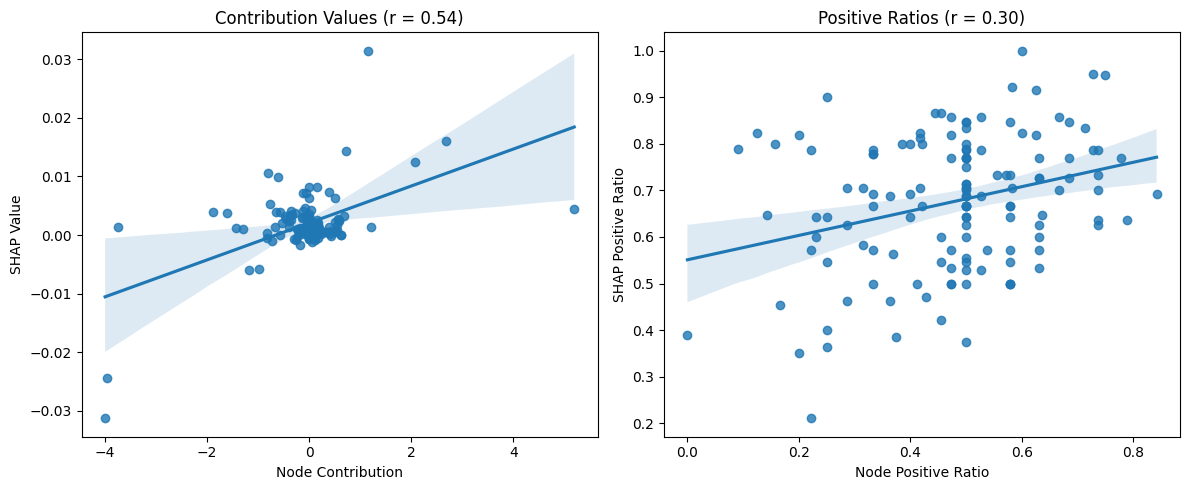


Combined Comparison DataFrame:
                             Feature  Node_Contribution  Average_SHAP  Node_Positive_Ratio  SHAP_Positive_Ratio
                                 Age           5.191063      0.004513             0.600000             1.000000
                   calcium_intake_BW           2.683864      0.016022             0.750000             0.947368
                           BMD_spine           2.071627      0.012465             0.714286             0.833333
                           rs2306033           1.216902      0.001433             0.842105             0.692308
                   Q_angle_asymmetry           1.151838      0.031465             0.727273             0.950000
                   VALR_asymmetry_12           0.723529      0.014434             0.500000             0.789474
                           rs1800972           0.671567      0.003243             0.684211             0.846154
                           rs1249269           0.632110      0.000087   

In [11]:
# Optional: Show scatter plots
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Contribution values comparison
sns.regplot(x='Node_Contribution', y='Average_SHAP', data=combined_df, ax=ax[0])
ax[0].set_title(f'Contribution Values (r = {corr_contrib:.2f})')
ax[0].set_xlabel('Node Contribution')
ax[0].set_ylabel('SHAP Value')

# Positive ratio comparison
sns.regplot(x='Node_Positive_Ratio', y='SHAP_Positive_Ratio', data=combined_df, ax=ax[1])
ax[1].set_title(f'Positive Ratios (r = {corr_ratio:.2f})')
ax[1].set_xlabel('Node Positive Ratio')
ax[1].set_ylabel('SHAP Positive Ratio')

plt.tight_layout()
plt.show()

# Show merged DataFrame for inspection
print("\nCombined Comparison DataFrame:")
print(combined_df[['Feature', 'Node_Contribution', 'Average_SHAP', 
                 'Node_Positive_Ratio', 'SHAP_Positive_Ratio']].to_string(index=False))

In [12]:
# Identify top 10 positive and negative features for SHAP
# top_shap_pos = result_table.nlargest(3, 'Average_SHAP')['Feature'].tolist()
# top_shap_neg = result_table.nsmallest(3, 'Average_SHAP')['Feature'].tolist()

# Identify top 10 positive and negative features for node contributions
top_node_pos = node_df.nlargest(5, 'Node_Contribution')['Feature'].tolist()
top_node_neg = node_df.nsmallest(5, 'Node_Contribution')['Feature'].tolist()

# Combine all top features into a single set
top_features = set(top_node_pos + top_node_neg)

# Filter the combined DataFrame to only include top features
top_combined_df = combined_df[combined_df['Feature'].isin(top_features)]

# Calculate correlations for top features
if not top_combined_df.empty:
    corr_contrib_top = top_combined_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
    corr_ratio_top = top_combined_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]

    print(f"\nCorrelation for Top Features Only:")
    print(f"Number of top features: {len(top_combined_df)}")
    print(f"Correlation between Node Contributions and SHAP Values: {corr_contrib_top:.3f}")
    print(f"Correlation between Positive Ratios: {corr_ratio_top:.3f}")

    print("\nTop Features Comparison:")
    print(top_combined_df[['Feature', 'Node_Contribution', 'Average_SHAP', 
                           'Node_Positive_Ratio', 'SHAP_Positive_Ratio']].to_string(index=False))
else:
    print("No top features matched between methods.")


Correlation for Top Features Only:
Number of top features: 7
Correlation between Node Contributions and SHAP Values: 0.710
Correlation between Positive Ratios: 0.802

Top Features Comparison:
                 Feature  Node_Contribution  Average_SHAP  Node_Positive_Ratio  SHAP_Positive_Ratio
                     Age           5.191063      0.004513             0.600000             1.000000
       calcium_intake_BW           2.683864      0.016022             0.750000             0.947368
               BMD_spine           2.071627      0.012465             0.714286             0.833333
           fat_intake_BW          -1.881163      0.003889             0.142857             0.647059
hip_adduction_peak_angle          -3.749412      0.001304             0.222222             0.571429
       glycine_intake_BW          -3.969937     -0.024330             0.200000             0.350000
      arginine_intake_BW          -3.998127     -0.031270             0.222222             0.210526


In [13]:
# Identify top 10 positive and negative features for SHAP
# Modified code to get true positive/negative features
shap_pos = result_table[result_table['Average_SHAP'] > 0].head(5)['Feature'].tolist()
shap_neg = result_table[result_table['Average_SHAP'] < 0].tail(5)['Feature'].tolist()
top_shap = shap_pos + shap_neg

# Identify top 10 positive and negative features for node contributions
# top_node_pos = node_df.nlargest(5, 'Node_Contribution')['Feature'].tolist()
# top_node_neg = node_df.nsmallest(5, 'Node_Contribution')['Feature'].tolist()

# Combine all top features into a single set
top_features = top_shap

# Filter the combined DataFrame to only include top features
top_combined_df = combined_df[combined_df['Feature'].isin(top_features)]

# Calculate correlations for top features
if not top_combined_df.empty:
    corr_contrib_top = top_combined_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
    corr_ratio_top = top_combined_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]

    print(f"\nCorrelation for Top Features Only:")
    print(f"Number of top features: {len(top_combined_df)}")
    print(f"Correlation between Node Contributions and SHAP Values: {corr_contrib_top:.3f}")
    print(f"Correlation between Positive Ratios: {corr_ratio_top:.3f}")

    print("\nTop Features Comparison:")
    print(top_combined_df[['Feature', 'Node_Contribution', 'Average_SHAP', 
                           'Node_Positive_Ratio', 'SHAP_Positive_Ratio']].to_string(index=False))
else:
    print("No top features matched between methods.")


Correlation for Top Features Only:
Number of top features: 10
Correlation between Node Contributions and SHAP Values: 0.889
Correlation between Positive Ratios: 0.702

Top Features Comparison:
           Feature  Node_Contribution  Average_SHAP  Node_Positive_Ratio  SHAP_Positive_Ratio
 calcium_intake_BW           2.683864      0.016022             0.750000             0.947368
         BMD_spine           2.071627      0.012465             0.714286             0.833333
 Q_angle_asymmetry           1.151838      0.031465             0.727273             0.950000
 VALR_asymmetry_12           0.723529      0.014434             0.500000             0.789474
           VILR_10          -0.172954     -0.001656             0.333333             0.500000
           BMD_hip          -0.803551      0.010556             0.090909             0.789474
          BMD_body          -0.978855     -0.005708             0.454545             0.421053
fat_percentage_avg          -1.172665     -0.005899   

In [14]:
# Identify top 10 positive and negative features for SHAP
top_shap_pos = result_table[result_table['Average_SHAP'] > 0].head(3)['Feature'].tolist()
top_shap_neg = result_table[result_table['Average_SHAP'] < 0].tail(3)['Feature'].tolist()

# Identify top 10 positive and negative features for node contributions
top_node_pos = node_df.nlargest(3, 'Node_Contribution')['Feature'].tolist()
top_node_neg = node_df.nsmallest(3, 'Node_Contribution')['Feature'].tolist()

# Combine all top features into a single set
top_features = set(top_node_pos + top_node_neg + top_shap_pos + top_shap_neg)

# Filter the combined DataFrame to only include top features
top_combined_df = combined_df[combined_df['Feature'].isin(top_features)]

# Calculate correlations for top features
if not top_combined_df.empty:
    corr_contrib_top = top_combined_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
    corr_ratio_top = top_combined_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]

    print(f"\nCorrelation for Top Features Only:")
    print(f"Number of top features: {len(top_combined_df)}")
    print(f"Correlation between Node Contributions and SHAP Values: {corr_contrib_top:.3f}")
    print(f"Correlation between Positive Ratios: {corr_ratio_top:.3f}")

    print("\nTop Features Comparison:")
    print(top_combined_df[['Feature', 'Node_Contribution', 'Average_SHAP', 
                           'Node_Positive_Ratio', 'SHAP_Positive_Ratio']].to_string(index=False))
else:
    print("No top features matched between methods.")


Correlation for Top Features Only:
Number of top features: 7
Correlation between Node Contributions and SHAP Values: 0.740
Correlation between Positive Ratios: 0.904

Top Features Comparison:
           Feature  Node_Contribution  Average_SHAP  Node_Positive_Ratio  SHAP_Positive_Ratio
               Age           5.191063      0.004513             0.600000             1.000000
 calcium_intake_BW           2.683864      0.016022             0.750000             0.947368
 Q_angle_asymmetry           1.151838      0.031465             0.727273             0.950000
 VALR_asymmetry_12           0.723529      0.014434             0.500000             0.789474
fat_percentage_avg          -1.172665     -0.005899             0.000000             0.388889
 glycine_intake_BW          -3.969937     -0.024330             0.200000             0.350000
arginine_intake_BW          -3.998127     -0.031270             0.222222             0.210526


In [15]:
# Calculate positive ratio for node contributions
node_df['Node_Positive_Ratio'] = node_df.apply(
    lambda x: x['Node_Positive'] / (x['Node_Positive'] + x['Node_Negative']) 
    if (x['Node_Positive'] + x['Node_Negative']) > 0 else 0.5, 
    axis=1
)

# Identify top 3 positive and negative features for node contributions based on positive ratio
top_node_pos_ratio = node_df.nlargest(10, 'Node_Positive_Ratio')['Feature'].tolist()
top_node_neg_ratio = node_df.nsmallest(10, 'Node_Positive_Ratio')['Feature'].tolist()

# Combine all top features into a single set
top_features = set(top_node_pos_ratio + top_node_neg_ratio)

# Filter the combined DataFrame to only include top features
top_combined_df = combined_df[combined_df['Feature'].isin(top_features)]

# Calculate correlations for top features
if not top_combined_df.empty:
    corr_contrib_top = top_combined_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
    corr_ratio_top = top_combined_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]

    print(f"\nCorrelation for Top Features Only:")
    print(f"Number of top features: {len(top_combined_df)}")
    print(f"Correlation between Node Contributions and SHAP Values: {corr_contrib_top:.3f}")
    print(f"Correlation between Positive Ratios: {corr_ratio_top:.3f}")

    print("\nTop Features Comparison:")
    print(top_combined_df[['Feature', 'Node_Contribution', 'Average_SHAP', 
                           'Node_Positive_Ratio', 'SHAP_Positive_Ratio']].to_string(index=False))
else:
    print("No top features matched between methods.")


Correlation for Top Features Only:
Number of top features: 18
Correlation between Node Contributions and SHAP Values: 0.748
Correlation between Positive Ratios: 0.267

Top Features Comparison:
                             Feature  Node_Contribution  Average_SHAP  Node_Positive_Ratio  SHAP_Positive_Ratio
                   calcium_intake_BW           2.683864      0.016022             0.750000             0.947368
                           rs2306033           1.216902      0.001433             0.842105             0.692308
                           rs4701616           0.537854      0.000872             0.789474             0.636364
                           rs3018362           0.524477      0.000582             0.736842             0.700000
                          rs11154027           0.199906      0.001133             0.736842             0.636364
                             VALR_12           0.169342      0.001537             0.777778             0.769231
                      

In [16]:
# Calculate SHAP positive ratio
result_table['SHAP_Positive_Ratio'] = result_table.apply(
    lambda x: x['Positive_Runs'] / (x['Positive_Runs'] + x['Negative_Runs']) 
    if (x['Positive_Runs'] + x['Negative_Runs']) > 0 else 0.5, 
    axis=1
)

# Identify top 10 positive and negative features for SHAP based on SHAP positive ratio
top_shap_pos_ratio = result_table.nlargest(3, 'SHAP_Positive_Ratio')['Feature'].tolist()
top_shap_neg_ratio = result_table.nsmallest(3, 'SHAP_Positive_Ratio')['Feature'].tolist()

# Combine all top features into a single set
top_features = set(top_shap_pos_ratio + top_shap_neg_ratio)

# Filter the combined DataFrame to only include top features
top_combined_df = combined_df[combined_df['Feature'].isin(top_features)]

# Calculate correlations for top features
if not top_combined_df.empty:
    corr_contrib_top = top_combined_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
    corr_ratio_top = top_combined_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]

    print(f"\nCorrelation for Top Features Only:")
    print(f"Number of top features: {len(top_combined_df)}")
    print(f"Correlation between Node Contributions and SHAP Values: {corr_contrib_top:.3f}")
    print(f"Correlation between Positive Ratios: {corr_ratio_top:.3f}")

    print("\nTop Features Comparison:")
    print(top_combined_df[['Feature', 'Node_Contribution', 'Average_SHAP', 
                           'Node_Positive_Ratio', 'SHAP_Positive_Ratio']].to_string(index=False))
else:
    print("No top features matched between methods.")


Correlation for Top Features Only:
Number of top features: 6
Correlation between Node Contributions and SHAP Values: 0.746
Correlation between Positive Ratios: 0.958

Top Features Comparison:
           Feature  Node_Contribution  Average_SHAP  Node_Positive_Ratio  SHAP_Positive_Ratio
               Age           5.191063      0.004513             0.600000             1.000000
 calcium_intake_BW           2.683864      0.016022             0.750000             0.947368
 Q_angle_asymmetry           1.151838      0.031465             0.727273             0.950000
    Duty_factor_12           0.058459     -0.001148             0.250000             0.363636
 glycine_intake_BW          -3.969937     -0.024330             0.200000             0.350000
arginine_intake_BW          -3.998127     -0.031270             0.222222             0.210526


In [17]:
# Calculate positive ratio for node contributions
node_df['Node_Positive_Ratio'] = node_df.apply(
    lambda x: x['Node_Positive'] / (x['Node_Positive'] + x['Node_Negative']) 
    if (x['Node_Positive'] + x['Node_Negative']) > 0 else 0.5, 
    axis=1
)

# Identify top 3 positive and negative features for node contributions based on positive ratio
top_node_pos_ratio = node_df.nlargest(3, 'Node_Positive_Ratio')['Feature'].tolist()
top_node_neg_ratio = node_df.nsmallest(3, 'Node_Positive_Ratio')['Feature'].tolist()

# Calculate SHAP positive ratio
result_table['SHAP_Positive_Ratio'] = result_table.apply(
    lambda x: x['Positive_Runs'] / (x['Positive_Runs'] + x['Negative_Runs']) 
    if (x['Positive_Runs'] + x['Negative_Runs']) > 0 else 0.5, 
    axis=1
)

# Identify top 10 positive and negative features for SHAP based on SHAP positive ratio
top_shap_pos_ratio = result_table.nlargest(3, 'SHAP_Positive_Ratio')['Feature'].tolist()
top_shap_neg_ratio = result_table.nsmallest(3, 'SHAP_Positive_Ratio')['Feature'].tolist()

# Combine all top features into a single set
top_features = set(top_shap_pos_ratio + top_shap_neg_ratio + top_node_pos_ratio + top_node_neg_ratio)

# Filter the combined DataFrame to only include top features
top_combined_df = combined_df[combined_df['Feature'].isin(top_features)]

# Calculate correlations for top features
if not top_combined_df.empty:
    corr_contrib_top = top_combined_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
    corr_ratio_top = top_combined_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]

    print(f"\nCorrelation for Top Features Only:")
    print(f"Number of top features: {len(top_combined_df)}")
    print(f"Correlation between Node Contributions and SHAP Values: {corr_contrib_top:.3f}")
    print(f"Correlation between Positive Ratios: {corr_ratio_top:.3f}")

    print("\nTop Features Comparison:")
    print(top_combined_df[['Feature', 'Node_Contribution', 'Average_SHAP', 
                           'Node_Positive_Ratio', 'SHAP_Positive_Ratio']].to_string(index=False))
else:
    print("No top features matched between methods.")


Correlation for Top Features Only:
Number of top features: 11
Correlation between Node Contributions and SHAP Values: 0.705
Correlation between Positive Ratios: 0.644

Top Features Comparison:
           Feature  Node_Contribution  Average_SHAP  Node_Positive_Ratio  SHAP_Positive_Ratio
               Age           5.191063      0.004513             0.600000             1.000000
 calcium_intake_BW           2.683864      0.016022             0.750000             0.947368
         rs2306033           1.216902      0.001433             0.842105             0.692308
 Q_angle_asymmetry           1.151838      0.031465             0.727273             0.950000
         rs4701616           0.537854      0.000872             0.789474             0.636364
           VALR_12           0.169342      0.001537             0.777778             0.769231
    Duty_factor_12           0.058459     -0.001148             0.250000             0.363636
           BMD_hip          -0.803551      0.010556   

In [18]:
def analyze_model(run_id, X_train, y_train, selected_features, device, sample_index, model_save_dir):
    """
    Loads a trained model, performs analysis on a specific sample index, and extracts route and node contributions.
    
    Args:
        run_id (int): Identifier for the run (1 to 10).
        X_train (pd.DataFrame): Feature dataframe.
        y_train (pd.Series): Target series.
        selected_features (dict): Selected features per group.
        device (torch.device): Computation device.
        sample_index (int): Index of the sample for analysis.
        model_save_dir (str): Directory where trained models are saved.
    
    Returns:
        tuple: (prediction, route_contrib, bias_contrib, node_contrib, weight_matrices)
    """
    # Prepare data based on selected features
    X_current = X_train[selected_features['Genotype'] + selected_features['History'] + 
                        selected_features['Phenotype'] + selected_features['Behaviour']].copy()
    
    # Split feature groups
    X_genotype_current = X_current[selected_features['Genotype']].values.astype(np.float32)
    X_history_current = X_current[selected_features['History']].values.astype(np.float32)
    X_phenotype_current = X_current[selected_features['Phenotype']].values.astype(np.float32)
    X_behaviour_current = X_current[selected_features['Behaviour']].values.astype(np.float32)
    
    # Convert target to numpy array
    y_current = y_train.values.astype(np.float32)
    
    # Define model path
    model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file '{model_path}' does not exist.")
    
    # Initialize the updated model for activation capturing
    comparison_model = CustomMLPWithActivations(
        genotype_size=X_genotype_current.shape[1],
        history_size=X_history_current.shape[1],
        phenotype_size=X_phenotype_current.shape[1],
        behaviour_size=X_behaviour_current.shape[1],
        use_attention=True,
        use_mask=False
    ).to(device)
    
    # Load the trained parameters
    comparison_model.load_state_dict(torch.load(model_path, map_location=device))
    comparison_model.eval()  # Set to evaluation mode
    
    # Select sample index
    sample_genotype = X_genotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_genotype]
    sample_history = X_history_current[sample_index].reshape(1, -1)    # Shape: [1, n_history]
    sample_phenotype = X_phenotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_pheno]
    sample_behaviour = X_behaviour_current[sample_index].reshape(1, -1)  # Shape: [1, n_behaviour]
    sample_label = y_current[sample_index]
    
    # Convert to tensors and add batch dimension
    sample_genotype_tensor = torch.tensor(sample_genotype, dtype=torch.float32).to(device)
    sample_history_tensor = torch.tensor(sample_history, dtype=torch.float32).to(device)
    sample_phenotype_tensor = torch.tensor(sample_phenotype, dtype=torch.float32).to(device)
    sample_behaviour_tensor = torch.tensor(sample_behaviour, dtype=torch.float32).to(device)
    sample_label_tensor = torch.tensor([sample_label], dtype=torch.float32).to(device)
    
    # Perform forward pass and capture activations
    with torch.no_grad():
        output = comparison_model(
            genotype=sample_genotype_tensor,
            history=sample_history_tensor,
            phenotype=sample_phenotype_tensor,
            behaviour=sample_behaviour_tensor
        )
    
    # Extract activations
    activations = comparison_model.activations
    
    # ----------------------------
    # Manual Forward Pass and Route Contribution Calculation
    # ----------------------------
    
    # Define helper functions
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    def relu(x):
        return np.maximum(0, x)
    
    # Extract model parameters for manual calculations
    params = {}
    
    # Genotype Attention Parameters
    if comparison_model.use_attention:
        params['genotype_attention_weights1'] = comparison_model.attention_genotype.attention[0].weight.data.cpu().numpy()
        params['genotype_attention_bias1'] = comparison_model.attention_genotype.attention[0].bias.data.cpu().numpy()
        params['genotype_attention_weights2'] = comparison_model.attention_genotype.attention[2].weight.data.cpu().numpy()
        params['genotype_attention_bias2'] = comparison_model.attention_genotype.attention[2].bias.data.cpu().numpy()
    
    # Genotype to History Layer (nn.Linear)
    params['genotype_to_history_weight'] = comparison_model.genotype_to_history.weight.data.cpu().numpy()
    params['genotype_to_history_bias'] = comparison_model.genotype_to_history_bias.data.cpu().numpy()
    
    # BatchNorm for Genotype to History
    params['bn_genotype_to_history_weight'] = comparison_model.bn_genotype_to_history.weight.data.cpu().numpy()
    params['bn_genotype_to_history_bias_bn'] = comparison_model.bn_genotype_to_history.bias.data.cpu().numpy()
    params['bn_genotype_to_history_running_mean'] = comparison_model.bn_genotype_to_history.running_mean.data.cpu().numpy()
    params['bn_genotype_to_history_running_var'] = comparison_model.bn_genotype_to_history.running_var.data.cpu().numpy()
    params['bn_genotype_to_history_eps'] = comparison_model.bn_genotype_to_history.eps
    
    # Genotype to History Extra Layer (nn.Linear)
    params['genotype_to_history_extra_weight'] = comparison_model.genotype_to_history_extra.weight.data.cpu().numpy()
    params['genotype_to_history_extra_bias'] = comparison_model.genotype_to_history_extra.bias.data.cpu().numpy()
    
    # History Attention Parameters
    if comparison_model.use_attention:
        params['history_attention_weights1'] = comparison_model.attention_history.attention[0].weight.data.cpu().numpy()
        params['history_attention_bias1'] = comparison_model.attention_history.attention[0].bias.data.cpu().numpy()
        params['history_attention_weights2'] = comparison_model.attention_history.attention[2].weight.data.cpu().numpy()
        params['history_attention_bias2'] = comparison_model.attention_history.attention[2].bias.data.cpu().numpy()
    
    # History to Pheno Layer (nn.Linear)
    params['history_to_pheno_weight'] = comparison_model.history_to_pheno.weight.data.cpu().numpy()
    params['history_to_pheno_bias'] = comparison_model.history_to_pheno_bias.data.cpu().numpy()
    
    # BatchNorm for History to Pheno
    params['bn_history_to_pheno_weight'] = comparison_model.bn_history_to_pheno.weight.data.cpu().numpy()
    params['bn_history_to_pheno_bias_bn'] = comparison_model.bn_history_to_pheno.bias.data.cpu().numpy()
    params['bn_history_to_pheno_running_mean'] = comparison_model.bn_history_to_pheno.running_mean.data.cpu().numpy()
    params['bn_history_to_pheno_running_var'] = comparison_model.bn_history_to_pheno.running_var.data.cpu().numpy()
    params['bn_history_to_pheno_eps'] = comparison_model.bn_history_to_pheno.eps
    
    # History to Pheno Extra Layer (nn.Linear)
    params['history_to_pheno_extra_weight'] = comparison_model.history_to_pheno_extra.weight.data.cpu().numpy()
    params['history_to_pheno_extra_bias'] = comparison_model.history_to_pheno_extra.bias.data.cpu().numpy()
    
    # Phenotype Attention Parameters
    if comparison_model.use_attention:
        params['pheno_attention_weights1'] = comparison_model.attention_pheno.attention[0].weight.data.cpu().numpy()
        params['pheno_attention_bias1'] = comparison_model.attention_pheno.attention[0].bias.data.cpu().numpy()
        params['pheno_attention_weights2'] = comparison_model.attention_pheno.attention[2].weight.data.cpu().numpy()
        params['pheno_attention_bias2'] = comparison_model.attention_pheno.attention[2].bias.data.cpu().numpy()
    
    # Phenotype to Behaviour Layer (nn.Linear)
    params['pheno_to_behaviour_weight'] = comparison_model.pheno_to_behaviour.weight.data.cpu().numpy()
    params['pheno_to_behaviour_bias'] = comparison_model.pheno_to_behaviour_bias.data.cpu().numpy()
    
    # BatchNorm for Phenotype to Behaviour
    params['bn_pheno_to_behaviour_weight'] = comparison_model.bn_pheno_to_behaviour.weight.data.cpu().numpy()
    params['bn_pheno_to_behaviour_bias_bn'] = comparison_model.bn_pheno_to_behaviour.bias.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_mean'] = comparison_model.bn_pheno_to_behaviour.running_mean.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_var'] = comparison_model.bn_pheno_to_behaviour.running_var.data.cpu().numpy()
    params['bn_pheno_to_behaviour_eps'] = comparison_model.bn_pheno_to_behaviour.eps
    
    # Phenotype to Behaviour Extra Layer (nn.Linear)
    params['pheno_to_behaviour_extra_weight'] = comparison_model.pheno_to_behaviour_extra.weight.data.cpu().numpy()
    params['pheno_to_behaviour_extra_bias'] = comparison_model.pheno_to_behaviour_extra.bias.data.cpu().numpy()
    
    # Behaviour Attention Parameters
    if comparison_model.use_attention:
        params['behaviour_attention_weights1'] = comparison_model.attention_behaviour.attention[0].weight.data.cpu().numpy()
        params['behaviour_attention_bias1'] = comparison_model.attention_behaviour.attention[0].bias.data.cpu().numpy()
        params['behaviour_attention_weights2'] = comparison_model.attention_behaviour.attention[2].weight.data.cpu().numpy()
        params['behaviour_attention_bias2'] = comparison_model.attention_behaviour.attention[2].bias.data.cpu().numpy()
    
    # Behaviour to Output Layer (nn.Linear)
    params['behaviour_to_output_weight'] = comparison_model.behaviour_to_output.weight.data.cpu().numpy()
    params['behaviour_to_output_bias'] = comparison_model.behaviour_to_output.bias.data.cpu().numpy()
    
    # ----------------------------
    # Manual Forward Pass Calculations
    # ----------------------------
    
    manual_activations = {}
    
    # Convert input tensors to NumPy arrays
    genotype_input = sample_genotype_tensor.cpu().numpy()  # Shape: [1, n_genotype]
    history_input_np = sample_history_tensor.cpu().numpy()    # Shape: [1, n_history]
    phenotype_input_np = sample_phenotype_tensor.cpu().numpy()  # Shape: [1, n_pheno]
    behaviour_input_np = sample_behaviour_tensor.cpu().numpy()  # Shape: [1, n_behaviour]
    
    # 1. Genotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        genotype_att_hidden = relu(
            np.dot(genotype_input, params['genotype_attention_weights1'].T) + params['genotype_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        genotype_att_output = sigmoid(
            np.dot(genotype_att_hidden, params['genotype_attention_weights2'].T) + params['genotype_attention_bias2']
        )
        # Apply attention weights
        genotype_att = genotype_input * genotype_att_output  # Element-wise multiplication
        manual_activations['genotype_attention'] = genotype_att
    else:
        genotype_att = genotype_input
        manual_activations['genotype_attention'] = genotype_att
    
    # 2. Genotype to History
    genotype_to_history = np.dot(genotype_att, params['genotype_to_history_weight'].T)  # Shape: [1, n_history]
    genotype_to_history *= history_input_np  # Element-wise multiplication with history input
    manual_activations['genotype_to_history'] = genotype_to_history.copy()
    
    # 3. BatchNorm for Genotype to History
    bn_gth = (genotype_to_history - params['bn_genotype_to_history_running_mean']) / \
             np.sqrt(params['bn_genotype_to_history_running_var'] + params['bn_genotype_to_history_eps'])
    bn_gth = bn_gth * params['bn_genotype_to_history_weight'] + params['bn_genotype_to_history_bias_bn']
    bn_gth += params['genotype_to_history_bias']  # Add bias
    manual_activations['bn_genotype_to_history'] = bn_gth.copy()
    
    # 4. Genotype to History Extra
    genotype_to_history_extra = np.dot(genotype_att, params['genotype_to_history_extra_weight'].T) + params['genotype_to_history_extra_bias']  # Shape: [1,1]
    manual_activations['genotype_to_history_extra'] = genotype_to_history_extra.copy()
    
    # 5. Combine Genotype to History and Extra
    combined_history_input = np.concatenate([bn_gth, genotype_to_history_extra], axis=1)  # Shape: [1, n_history +1]
    manual_history_output = relu(combined_history_input)
    manual_activations['history_output'] = manual_history_output.copy()
    
    # 6. History Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        history_att_hidden = relu(
            np.dot(manual_history_output, params['history_attention_weights1'].T) + params['history_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        history_att_output = sigmoid(
            np.dot(history_att_hidden, params['history_attention_weights2'].T) + params['history_attention_bias2']
        )
        # Apply attention weights
        history_att = manual_history_output * history_att_output  # Element-wise multiplication
        manual_activations['history_attention'] = history_att.copy()
    else:
        history_att = manual_history_output
        manual_activations['history_attention'] = history_att.copy()
    
    # 7. History to Pheno
    history_to_pheno = np.dot(history_att, params['history_to_pheno_weight'].T)  # Shape: [1, n_pheno]
    history_to_pheno *= phenotype_input_np  # Element-wise multiplication with phenotype input
    manual_activations['history_to_pheno'] = history_to_pheno.copy()
    
    # 8. BatchNorm for History to Pheno
    bn_htp = (history_to_pheno - params['bn_history_to_pheno_running_mean']) / \
             np.sqrt(params['bn_history_to_pheno_running_var'] + params['bn_history_to_pheno_eps'])
    bn_htp = bn_htp * params['bn_history_to_pheno_weight'] + params['bn_history_to_pheno_bias_bn']
    bn_htp += params['history_to_pheno_bias']  # Add bias
    manual_activations['bn_history_to_pheno'] = bn_htp.copy()
    
    # 9. History to Pheno Extra
    history_to_pheno_extra = np.dot(history_att, params['history_to_pheno_extra_weight'].T) + params['history_to_pheno_extra_bias']  # Shape: [1,1]
    manual_activations['history_to_pheno_extra'] = history_to_pheno_extra.copy()
    
    # 10. Combine History to Pheno and Extra
    combined_pheno_input = np.concatenate([bn_htp, history_to_pheno_extra], axis=1)  # Shape: [1, n_pheno +1]
    manual_pheno_output = relu(combined_pheno_input)
    manual_activations['pheno_output'] = manual_pheno_output.copy()
    
    # 11. Phenotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        pheno_att_hidden = relu(
            np.dot(manual_pheno_output, params['pheno_attention_weights1'].T) + params['pheno_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        pheno_att_output = sigmoid(
            np.dot(pheno_att_hidden, params['pheno_attention_weights2'].T) + params['pheno_attention_bias2']
        )
        # Apply attention weights
        pheno_att = manual_pheno_output * pheno_att_output  # Element-wise multiplication
        manual_activations['pheno_attention'] = pheno_att.copy()
    else:
        pheno_att = manual_pheno_output
        manual_activations['pheno_attention'] = pheno_att.copy()
    
    # 12. Phenotype to Behaviour
    pheno_to_behaviour = np.dot(pheno_att, params['pheno_to_behaviour_weight'].T)  # Shape: [1, n_behaviour]
    pheno_to_behaviour *= behaviour_input_np  # Element-wise multiplication with behaviour input
    manual_activations['pheno_to_behaviour'] = pheno_to_behaviour.copy()
    
    # 13. BatchNorm for Phenotype to Behaviour
    bn_ptb = (pheno_to_behaviour - params['bn_pheno_to_behaviour_running_mean']) / \
             np.sqrt(params['bn_pheno_to_behaviour_running_var'] + params['bn_pheno_to_behaviour_eps'])
    bn_ptb = bn_ptb * params['bn_pheno_to_behaviour_weight'] + params['bn_pheno_to_behaviour_bias_bn']
    bn_ptb += params['pheno_to_behaviour_bias']  # Add bias
    manual_activations['bn_pheno_to_behaviour'] = bn_ptb.copy()
    
    # 14. Phenotype to Behaviour Extra
    pheno_to_behaviour_extra = np.dot(pheno_att, params['pheno_to_behaviour_extra_weight'].T) + params['pheno_to_behaviour_extra_bias']  # Shape: [1,1]
    manual_activations['pheno_to_behaviour_extra'] = pheno_to_behaviour_extra.copy()
    
    # 15. Combine Phenotype to Behaviour and Extra
    combined_behaviour_input = np.concatenate([bn_ptb, pheno_to_behaviour_extra], axis=1)  # Shape: [1, n_behaviour +1]
    manual_behaviour_output = relu(combined_behaviour_input)
    manual_activations['behaviour_output'] = manual_behaviour_output.copy()
    
    # 16. Behaviour Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        behaviour_att_hidden = relu(
            np.dot(manual_behaviour_output, params['behaviour_attention_weights1'].T) + params['behaviour_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        behaviour_att_output = sigmoid(
            np.dot(behaviour_att_hidden, params['behaviour_attention_weights2'].T) + params['behaviour_attention_bias2']
        )
        # Apply attention weights
        behaviour_att = manual_behaviour_output * behaviour_att_output  # Element-wise multiplication
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    else:
        behaviour_att = manual_behaviour_output
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    
    # 17. Behaviour to Output
    behaviour_to_output_manual = np.dot(behaviour_att, params['behaviour_to_output_weight'].T) + params['behaviour_to_output_bias']  # Shape: [1,1]
    manual_final_output = sigmoid(behaviour_to_output_manual)
    manual_activations['final_output'] = manual_final_output.copy()
    
    # Also, store manual_behaviour_to_output for comparison
    manual_activations['behaviour_to_output'] = behaviour_to_output_manual.copy()


    # Initialize the route contributions dictionary
    # Each route will map to a dictionary containing 'contrib' and its components
    route_contributions = {}
    
    # ----------------------------
    # Extract Weight Matrices and BatchNorm Parameters
    # ----------------------------
    
    # 1. Genotype to History Layer
    W1_main = params['genotype_to_history_weight']          # Shape: [n_history, n_genotype]
    W1_extra = params['genotype_to_history_extra_weight']   # Shape: [1, n_genotype]
    W1_total = np.vstack([W1_main, W1_extra])               # Shape: [n_history + 1, n_genotype]
    
    # 2. History to Phenotype Layer
    W2_main = params['history_to_pheno_weight']             # Shape: [n_pheno, n_history + 1]
    W2_extra = params['history_to_pheno_extra_weight']      # Shape: [1, n_history + 1]
    W2_total = np.vstack([W2_main, W2_extra])               # Shape: [n_pheno + 1, n_history + 1]
    
    # 3. Phenotype to Behaviour Layer
    W3_main = params['pheno_to_behaviour_weight']           # Shape: [n_behaviour, n_pheno + 1]
    W3_extra = params['pheno_to_behaviour_extra_weight']    # Shape: [1, n_pheno + 1]
    W3_total = np.vstack([W3_main, W3_extra])               # Shape: [n_behaviour + 1, n_pheno + 1]
    
    # 4. Behaviour to Output Layer
    W4 = params['behaviour_to_output_weight']               # Shape: [1, n_behaviour + 1]
    b4 = params['behaviour_to_output_bias']                 # Shape: [1]
    
    # ----------------------------
    # Extract BatchNorm Scaling Factors
    # ----------------------------
    
    # 1. BatchNorm for Genotype to History
    bn_gth_gamma = params['bn_genotype_to_history_weight']           # Shape: [n_history]
    bn_gth_running_var = params['bn_genotype_to_history_running_var'] # Shape: [n_history]
    bn_gth_eps = params['bn_genotype_to_history_eps']                # Scalar
    
    # 2. BatchNorm for History to Phenotype
    bn_htp_gamma = params['bn_history_to_pheno_weight']              # Shape: [n_pheno]
    bn_htp_running_var = params['bn_history_to_pheno_running_var']  # Shape: [n_pheno]
    bn_htp_eps = params['bn_history_to_pheno_eps']                   # Scalar
    
    # 3. BatchNorm for Phenotype to Behaviour
    bn_ptb_gamma = params['bn_pheno_to_behaviour_weight']            # Shape: [n_behaviour]
    bn_ptb_running_var = params['bn_pheno_to_behaviour_running_var']# Shape: [n_behaviour]
    bn_ptb_eps = params['bn_pheno_to_behaviour_eps']                 # Scalar
    
    # ----------------------------
    # Determine Number of Nodes per Layer
    # ----------------------------
    
    n_genotype = genotype_input.shape[1]
    n_history = W1_main.shape[0]
    n_pheno = W2_main.shape[0]
    n_behaviour = W3_main.shape[0]
    
    # Total nodes including extra nodes
    total_history_nodes = n_history + 1
    total_pheno_nodes = n_pheno + 1
    total_behaviour_nodes = n_behaviour + 1
    
    # ----------------------------
    # Iterate Over All Possible Routes
    # ----------------------------
    
    for i in range(n_genotype):  # Genotype features
        for j in range(total_history_nodes):  # History nodes (including extra)
            genotype_input_i = genotype_input[0, i]
            # Check if History node 'j' is active (ReLU activated)
            if manual_activations['history_output'][0, j] <= 0:
                continue  # ReLU not activated for History node 'j'
    
            # Weight from Genotype_i to History_j
            W1_ji = W1_total[j, i]  # Scalar
    
            # Scaling factor for Genotype to History (BatchNorm)
            if j < n_history:
                scaling_j = bn_gth_gamma[j] / np.sqrt(bn_gth_running_var[j] + bn_gth_eps)
                history_input_np_j = history_input_np[0, j]
                history_feature_name = selected_features['History'][j]
            else:
                scaling_j = 1.0  # No scaling for extra node
                history_input_np_j = 1.0
                history_feature_name = 'History_extra'
           
            for k in range(total_pheno_nodes):  # Phenotype nodes (including extra)
                # Check if Phenotype node 'k' is active
                if manual_activations['pheno_output'][0, k] <= 0:
                    continue  # ReLU not activated for Phenotype node 'k'
    
                # Weight from History_j to Phenotype_k
                W2_kj = W2_total[k, j]  # Scalar
    
                # Scaling factor for History to Phenotype (BatchNorm)
                if k < n_pheno:
                    scaling_k = bn_htp_gamma[k] / np.sqrt(bn_htp_running_var[k] + bn_htp_eps)
                    phenotype_input_np_k = phenotype_input_np[0, k]
                    phenotype_feature_name = selected_features['Phenotype'][k]
                else:
                    scaling_k = 1.0  # No scaling for extra node
                    phenotype_input_np_k = 1.0
                    phenotype_feature_name = 'Phenotype_extra'
    
                for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
                    # Check if Behaviour node 'l' is active
                    if manual_activations['behaviour_output'][0, l] <= 0:
                        continue  # ReLU not activated for Behaviour node 'l'
    
                    # Weight from Phenotype_k to Behaviour_l
                    W3_lk = W3_total[l, k]  # Scalar
    
                    # Scaling factor for Phenotype to Behaviour (BatchNorm)
                    if l < n_behaviour:
                        scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                        behaviour_input_np_l = behaviour_input_np[0, l]
                        behaviour_feature_name = selected_features['Behaviour'][l]
                    else:
                        scaling_l = 1.0  # No scaling for extra node
                        behaviour_input_np_l = 1.0
                        behaviour_feature_name = 'Behaviour_extra'
    
                    # Weight from Behaviour_l to Output
                    W4_0l = W4[0, l]  # Scalar
    
                    # Contribution calculation
                    contrib = (
                        W1_ji * genotype_input_i * genotype_att_output[0, i] *
                        W2_kj * scaling_j * history_input_np_j * history_att_output[0, j] *
                        W3_lk * scaling_k * phenotype_input_np_k * pheno_att_output[0, k] *
                        W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l]
                    )
    
                    # Define the route as a tuple of node identifiers
                    route = (
                        f"Genotype_{selected_features['Genotype'][i]}",
                        f"History_{history_feature_name}",
                        f"Phenotype_{phenotype_feature_name}",
                        f"Behaviour_{behaviour_feature_name}"
                    )
    
                    # Accumulate the contribution and store components for the route
                    if route in route_contributions:
                        # If the route already exists, sum the contributions
                        route_contributions[route]['contrib'] += contrib
                    else:
                        # Initialize the route with its components and contribution
                        route_contributions[route] = {
                            'contrib': contrib,
                            'components': {
                                'gth_weight': W1_ji,
                                'genotype_input': genotype_input_i,
                                'genotype_attention': genotype_att_output[0, i],
                                'htp_weight': W2_kj,
                                'bn_history': scaling_j,
                                'history_input': history_input_np_j,
                                'history_attention': history_att_output[0, j],
                                'ptb_weight': W3_lk,
                                'bn_pheno': scaling_k,
                                'phenotype_input': phenotype_input_np_k,
                                'pheno_attention': pheno_att_output[0, k],
                                'bto_weight': W4_0l,
                                'bn_behaviour': scaling_l,
                                'behaviour_input': behaviour_input_np_l,
                                'behaviour_attention': behaviour_att_output[0, l]
                                
                            }
                        }

    # Calculate the sum of all contributions
    sum_contribs = sum(route['contrib'] for route in route_contributions.values())
    # ----------------------------
    # Bias Contributions Calculation
    # ----------------------------
    
    # Initialize the bias contributions dictionary
    bias_contributions = {}
    
    bn_gth_mean = params['bn_genotype_to_history_running_mean']
    bias_gth_bn = params['bn_genotype_to_history_bias_bn']
    bias_genotype_to_history = params['genotype_to_history_bias']
    
    bn_gth_bias = bias_gth_bn - (bn_gth_gamma * bn_gth_mean) / np.sqrt(bn_gth_running_var + bn_gth_eps)
    
    overall_gth_bias = bn_gth_bias + bias_genotype_to_history
    bias_gth_extra = params['genotype_to_history_extra_bias']
    
    bias_gth = np.concatenate([overall_gth_bias, bias_gth_extra], axis=0)
    
    bn_htp_mean = params['bn_history_to_pheno_running_mean']
    bias_htp_bn = params['bn_history_to_pheno_bias_bn']
    bias_history_to_pheno = params['history_to_pheno_bias']
    
    bn_htp_bias = bias_htp_bn - (bn_htp_gamma * bn_htp_mean) / np.sqrt(bn_htp_running_var + bn_htp_eps)
    
    overall_htp_bias = bn_htp_bias + bias_history_to_pheno
    bias_htp_extra = params['history_to_pheno_extra_bias']
    
    bias_htp = np.concatenate([overall_htp_bias, bias_htp_extra], axis=0)
    
    bn_ptb_mean = params['bn_pheno_to_behaviour_running_mean']
    bias_ptb_bn = params['bn_pheno_to_behaviour_bias_bn']
    bias_pheno_to_behaviour = params['pheno_to_behaviour_bias']
    
    bn_ptb_bias = bias_ptb_bn - (bn_ptb_gamma * bn_ptb_mean) / np.sqrt(bn_ptb_running_var + bn_ptb_eps)
    
    overall_ptb_bias = bn_ptb_bias + bias_pheno_to_behaviour
    bias_ptb_extra = params['pheno_to_behaviour_extra_bias']
    
    bias_ptb = np.concatenate([overall_ptb_bias, bias_ptb_extra], axis=0)
    
    # Propagate bias_gth_activation through History to Pheno
    for j in range(total_history_nodes):  # History nodes
        if manual_activations['history_output'][0, j] <= 0:
            continue  # ReLU not activated
    
        # Define history_feature_name based on node index
        if j < n_history:
            history_feature_name = selected_features['History'][j]
        else:
            history_feature_name = 'History_extra'
    
        for k in range(total_pheno_nodes):  # Phenotype nodes (including extra)
            # Check if Phenotype node 'k' is active
            if manual_activations['pheno_output'][0, k] <= 0:
                continue  # ReLU not activated for Phenotype node 'k'
    
            # Define phenotype_feature_name based on node index
            if k < n_pheno:
                phenotype_feature_name = selected_features['Phenotype'][k]
            else:
                phenotype_feature_name = 'Phenotype_extra'
    
            # Weight from History_j to Phenotype_k
            W2_kj = W2_total[k, j]  # Scalar
    
            # Scaling factor for History to Phenotype (BatchNorm)
            if k < n_pheno:
                scaling_k = bn_htp_gamma[k] / np.sqrt(bn_htp_running_var[k] + bn_htp_eps)
                phenotype_input_np_k = phenotype_input_np[0, k]
            else:
                scaling_k = 1.0  # No scaling for extra node
                phenotype_input_np_k = 1.0
    
            for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
                # Check if Behaviour node 'l' is active
                if manual_activations['behaviour_output'][0, l] <= 0:
                    continue  # ReLU not activated for Behaviour node 'l'
    
                # Define behaviour_feature_name based on node index
                if l < n_behaviour:
                    behaviour_feature_name = selected_features['Behaviour'][l]
                else:
                    behaviour_feature_name = 'Behaviour_extra'
    
                # Weight from Phenotype_k to Behaviour_l
                W3_lk = W3_total[l, k]  # Scalar
    
                # Scaling factor for Phenotype to Behaviour (BatchNorm)
                if l < n_behaviour:
                    scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                    behaviour_input_np_l = behaviour_input_np[0, l]
                else:
                    scaling_l = 1.0  # No scaling for extra node
                    behaviour_input_np_l = 1.0
    
                # Weight from Behaviour_l to Output
                W4_0l = W4[0, l]  # Scalar
    
                # Contribution calculation
                contrib = (
                    W2_kj * history_att_output[0, j] *
                    W3_lk * scaling_k * phenotype_input_np_k * pheno_att_output[0, k] *
                    W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l] *
                    bias_gth[j]
                )
    
                # Define the route as a tuple of node identifiers
                route = (
                    "Bias_genotype_to_history",
                    f"History_{history_feature_name}",
                    f"Phenotype_{phenotype_feature_name}",
                    f"Behaviour_{behaviour_feature_name}"
                )
    
                # Accumulate the contribution for the route
                if route in bias_contributions:
                    bias_contributions[route] += contrib
                else:
                    bias_contributions[route] = contrib
    
    # Propagate bias_htp_activation through Pheno to Behaviour
    for k in range(total_pheno_nodes):  # Phenotype nodes
        if manual_activations['pheno_output'][0, k] <= 0:
            continue  # ReLU not activated for Phenotype node 'k'
    
        # Define phenotype_feature_name based on node index
        if k < n_pheno:
            phenotype_feature_name = selected_features['Phenotype'][k]
        else:
            phenotype_feature_name = 'Phenotype_extra'
    
        for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
            # Check if Behaviour node 'l' is active
            if manual_activations['behaviour_output'][0, l] <= 0:
                continue  # ReLU not activated for Behaviour node 'l'
    
            # Define behaviour_feature_name based on node index
            if l < n_behaviour:
                behaviour_feature_name = selected_features['Behaviour'][l]
            else:
                behaviour_feature_name = 'Behaviour_extra'
    
            # Weight from Phenotype_k to Behaviour_l
            W3_lk = W3_total[l, k]  # Scalar
    
            # Scaling factor for Phenotype to Behaviour (BatchNorm)
            if l < n_behaviour:
                scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                behaviour_input_np_l = behaviour_input_np[0, l]
            else:
                scaling_l = 1.0  # No scaling for extra node
                behaviour_input_np_l = 1.0
    
            # Weight from Behaviour_l to Output
            W4_0l = W4[0, l]  # Scalar
    
            # Contribution calculation
            contrib = (
                W3_lk * pheno_att_output[0, k] *
                W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l] *
                bias_htp[k]
            )
    
            # Define the route as a tuple of node identifiers
            route = (
                "Bias_history_to_pheno",
                f"Phenotype_{phenotype_feature_name}",
                f"Behaviour_{behaviour_feature_name}"
            )
    
            # Accumulate the contribution for the route
            if route in bias_contributions:
                bias_contributions[route] += contrib
            else:
                bias_contributions[route] = contrib
    
    # Propagate bias_ptb_activation through Behaviour to Output
    for l in range(total_behaviour_nodes):  # Behaviour nodes
        if manual_activations['behaviour_output'][0, l] <= 0:
            continue  # ReLU not activated
    
        # Define behaviour_feature_name based on node index
        if l < n_behaviour:
            behaviour_feature_name = selected_features['Behaviour'][l]
        else:
            behaviour_feature_name = 'Behaviour_extra'
    
        # Weight from Behaviour_l to Output
        W4_0l = W4[0, l]
    
        # Contribution calculation
        contrib = (
            W4_0l * behaviour_att_output[0, l] * bias_ptb[l]
        )
    
        # Define the route as a tuple of node identifiers
        route = (
            "Bias_pheno_to_behaviour",
            f"Behaviour_{behaviour_feature_name}",
        )
    
        # Accumulate the contribution for the route
        if route in bias_contributions:
            bias_contributions[route] += contrib
        else:
            bias_contributions[route] = contrib
    
    # 4. Bias from Behaviour to Output
    # Compute the bias effect after linear transformation and activation
    # Note: In the final layer, the bias is directly added before the sigmoid activation
    
    # Weight from Behaviour to Output
    # Since the output layer applies a sigmoid activation, we'll account for that
    
    # Compute the linear contribution from bias
    bias_bo = params['behaviour_to_output_bias']  # Shape: [1]
    
    # Define the route as a tuple of node identifiers
    route = (
        "Bias_behaviour_to_output",
        "Output"
    )
    
    # Accumulate the contribution for the route
    bias_contributions[route] = float(bias_bo)
    
    # Sum of all weight-based route contributions
    sum_contribs = sum(route['contrib'] for route in route_contributions.values())
    
    # Calculate the sum of all bias contributions as a scalar
    sum_bias_contribs = np.sum(list(bias_contributions.values()))
    
    # Total contributions
    total_contribs = sum_contribs + sum_bias_contribs
    
    # Manual final output from forward pass
    manual_final_output = manual_activations['final_output'][0, 0]  # Assuming shape [1,1]
    
    # Apply sigmoid to total contributions
    sigmoid_total_contribs = sigmoid(total_contribs)
    
    # Compare with manual final output
    difference = np.abs(manual_final_output - sigmoid_total_contribs)
    
    # ----------------------------
    # Calculate Total Contributions per Node
    # ----------------------------
    
    # Initialize dictionary to store total contributions per node
    node_contributions = {}
    
    # 1. Aggregate contributions from all routes that pass through each node
    for route, data in route_contributions.items():
        contrib = data['contrib']
        for node in route:
            if node in node_contributions:
                node_contributions[node] += contrib
            else:
                node_contributions[node] = contrib
    
    # 2. Aggregate bias contributions for each node along the route
    for route, contrib in bias_contributions.items():
        # The first element in the route tuple indicates the bias type and is not a node
        nodes_in_route = route[1:]  # Exclude the bias type identifier

        if not nodes_in_route:
            # If there are no nodes in the route, skip this route
            skipped_routes.append(route)
            continue

        # Accumulate the contribution for each node in the route
        for node in nodes_in_route:
            if node in node_contributions:
                node_contributions[node] += contrib
            else:
                node_contributions[node] = contrib
    
    # 3. Sort nodes by their contribution values in descending order
    sorted_nodes = sorted(node_contributions.items(), key=lambda x: x[1], reverse=True)

    weight_matrices = {
        'W1_total': W1_total,
        'W2_total': W2_total,
        'W3_total': W3_total,
        'W4': W4
    }
    
    # Return all necessary outputs
    return output.item(), route_contributions, bias_contributions, node_contributions, weight_matrices

In [19]:
# ----------------------------
# Random Sample Selection and Correlation Analysis
# ----------------------------

def calculate_jaccard(set1, set2):
    """Calculate Jaccard similarity between two sets."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union != 0 else 0

def calculate_rank_correlation(rank1, rank2):
    """Calculate Spearman correlation between two ranked lists."""
    from scipy.stats import spearmanr
    common_items = list(set(rank1) & set(rank2))
    if len(common_items) < 2:
        return np.nan
    # Get ranks for common items
    rank1_pos = [rank1.index(item) for item in common_items]
    rank2_pos = [rank2.index(item) for item in common_items]
    return spearmanr(rank1_pos, rank2_pos).correlation

# Randomly select 100 samples
np.random.seed(42)
sample_indices = np.random.choice(len(X), size=100, replace=False)

# Initialize results storage
results = []

# Initialize results storage with rank correlations
for sample_idx in tqdm(sample_indices, desc="Processing samples"):
    sample_results = {
        'sample_index': sample_idx,
        'true_label': y.iloc[sample_idx],
        'correlations': {
            # Now 3 metrics × 7 feature sets = 21 entries
            'all_features_contrib': np.nan,
            'all_features_ratio': np.nan,
            'all_features_rank': np.nan,
            'top_node_5pos5neg_contrib': np.nan,
            'top_node_5pos5neg_ratio': np.nan,
            'top_node_5pos5neg_rank': np.nan,
            'top_shap_5pos5neg_contrib': np.nan,
            'top_shap_5pos5neg_ratio': np.nan,
            'top_shap_5pos5neg_rank': np.nan,
            'combined_3n3s_contrib': np.nan,
            'combined_3n3s_ratio': np.nan,
            'combined_3n3s_rank': np.nan,
            'top_node_ratio5_contrib': np.nan,
            'top_node_ratio5_ratio': np.nan,
            'top_node_ratio5_rank': np.nan,
            'top_shap_ratio5_contrib': np.nan,
            'top_shap_ratio5_ratio': np.nan,
            'top_shap_ratio5_rank': np.nan,
            'combined_ratio3_contrib': np.nan,
            'combined_ratio3_ratio': np.nan,
            'combined_ratio3_rank': np.nan
        }
    }
    
    # Get SHAP values for this sample across all runs
    X_selected = X[current_selected_features]
    sample_to_explain = X_selected.iloc[sample_idx].values.reshape(1, -1).astype(np.float32)
    background = shap.sample(X_selected, 100, random_state=42).values.astype(np.float32)
    shap_values_all_runs = []

    for run_id in range(1, num_runs + 1):
        model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
        model = CustomMLPWithOptionalComponents(
            genotype_size=n_genotype,
            history_size=n_history,
            phenotype_size=n_pheno,
            behaviour_size=n_behaviour,
            use_attention=True,
            use_mask=False
        ).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        def model_predict(data):
            genotype_data = data[:, :n_genotype]
            history_data = data[:, n_genotype:n_genotype+n_history]
            pheno_data = data[:, n_genotype+n_history:n_genotype+n_history+n_pheno]
            behaviour_data = data[:, n_genotype+n_history+n_pheno:]
            inputs = (
                torch.tensor(genotype_data, dtype=torch.float32).to(device),
                torch.tensor(history_data, dtype=torch.float32).to(device),
                torch.tensor(pheno_data, dtype=torch.float32).to(device),
                torch.tensor(behaviour_data, dtype=torch.float32).to(device)
            )
            with torch.no_grad():
                outputs = model(*inputs)
            return outputs.cpu().numpy()

        explainer = shap.KernelExplainer(model_predict, background)
        shap_values = explainer.shap_values(sample_to_explain, silent=True)
        shap_array = np.array(shap_values)
        if shap_array.ndim == 3:
            shap_array = shap_array.squeeze(axis=-1)
        shap_values_all_runs.append(shap_array[0])
    
    # Get node contributions for this sample across all runs
    node_contributions_all_runs = []
    for run_id in range(1, num_runs + 1):
        _, _, _, node_contrib, _ = analyze_model(
            run_id=run_id,
            X_train=X,
            y_train=y,
            selected_features=selected_features,
            device=device,
            sample_index=sample_idx,
            model_save_dir=model_save_dir
        )
        node_contributions_all_runs.append(node_contrib)
    
    # Aggregate node contributions across runs
    aggregated_node_contributions = aggregate_contributions(node_contributions_all_runs)
    
    # Create DataFrames for SHAP and node contributions
    shap_df = pd.DataFrame(shap_values_all_runs, columns=X_selected.columns.tolist())
    result_table = pd.DataFrame({
        'Feature': shap_df.columns,
        'Average_SHAP': shap_df.mean(),
        'Positive_Runs': (shap_df > 0).sum(),
        'Negative_Runs': (shap_df < 0).sum()
    }).sort_values('Average_SHAP', ascending=False)

    node_df = pd.DataFrame({
        'Feature': [feature.split("_", 1)[-1] for feature in aggregated_node_contributions.keys()],
        'Node_Contribution': list(aggregated_node_contributions.values()),
        'Node_Positive': [sum(1 for run in node_contributions_all_runs if run.get(feature, 0) > 0) for feature in aggregated_node_contributions.keys()],
        'Node_Negative': [sum(1 for run in node_contributions_all_runs if run.get(feature, 0) < 0) for feature in aggregated_node_contributions.keys()]
    })

    # Merge SHAP and node contribution DataFrames
    combined_df = pd.merge(node_df, result_table, on='Feature', how='inner', suffixes=('_node', '_shap'))
    combined_df['Node_Positive_Ratio'] = combined_df.apply(
        lambda x: x['Node_Positive'] / (x['Node_Positive'] + x['Node_Negative']) if (x['Node_Positive'] + x['Node_Negative']) > 0 else 0.5,
        axis=1
    )
    combined_df['SHAP_Positive_Ratio'] = combined_df.apply(
        lambda x: x['Positive_Runs'] / (x['Positive_Runs'] + x['Negative_Runs']) if (x['Positive_Runs'] + x['Negative_Runs']) > 0 else 0.5,
        axis=1
    )

    def calculate_correlations(subset_df):
        """Calculate Pearson and Spearman correlations with error handling"""
        try:
            contrib_corr = subset_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
        except:
            contrib_corr = np.nan

        try:
            ratio_corr = subset_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]
        except:
            ratio_corr = np.nan

        try:
            # Calculate Spearman's rank correlation
            rank_corr = subset_df[['Node_Contribution', 'Average_SHAP']].corr(method='spearman').iloc[0,1]
        except:
            rank_corr = np.nan

        return contrib_corr, ratio_corr, rank_corr

    # 1. All features
    c, r, s = calculate_correlations(combined_df)
    sample_results['correlations']['all_features_contrib'] = c
    sample_results['correlations']['all_features_ratio'] = r
    sample_results['correlations']['all_features_rank'] = s

    # 2. Top 5 node pos + 5 node neg
    top_node = node_df.head(5)['Feature'].tolist() + node_df.tail(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(top_node)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_node_5pos5neg_contrib'] = c
    sample_results['correlations']['top_node_5pos5neg_ratio'] = r 
    sample_results['correlations']['top_node_5pos5neg_rank'] = s
    
    # 3. Top 3 SHAP pos + 3 SHAP neg
    shap_pos = result_table[result_table['Average_SHAP'] > 0].head(5)['Feature'].tolist()
    shap_neg = result_table[result_table['Average_SHAP'] < 0].tail(5)['Feature'].tolist()
    top_shap = shap_pos + shap_neg
    
    subset = combined_df[combined_df['Feature'].isin(top_shap)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_shap_5pos5neg_contrib'] = c
    sample_results['correlations']['top_shap_5pos5neg_ratio'] = r
    sample_results['correlations']['top_shap_5pos5neg_rank'] = s
    
    # 4. Combined 3n+3s
    combined_features = top_node[:3] + top_node[-3:] + top_shap[:3] + top_shap[-3:]
    subset = combined_df[combined_df['Feature'].isin(combined_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['combined_3n3s_contrib'] = c
    sample_results['correlations']['combined_3n3s_ratio'] = r
    sample_results['correlations']['combined_3n3s_rank'] = s
    
    # 5. Top node ratios (weighted by 5)
    # Get ratios from combined_df instead of node_df
    node_ratio_features = combined_df.sort_values('Node_Positive_Ratio', ascending=False).head(5)['Feature'].tolist() + \
                        combined_df.sort_values('Node_Positive_Ratio').head(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(node_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_node_ratio5_contrib'] = c
    sample_results['correlations']['top_node_ratio5_ratio'] = r
    sample_results['correlations']['top_node_ratio5_rank'] = s
    
    # 6. Top SHAP ratios (weighted by 3)
    # Get ratios from combined_df instead of result_table
    shap_ratio_features = combined_df.sort_values('SHAP_Positive_Ratio', ascending=False).head(5)['Feature'].tolist() + \
                        combined_df.sort_values('SHAP_Positive_Ratio').head(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(shap_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_shap_ratio5_contrib'] = c
    sample_results['correlations']['top_shap_ratio5_ratio'] = r
    sample_results['correlations']['top_shap_ratio5_rank'] = s
    
    # 7. Combined ratios
    combined_ratio_features = node_ratio_features[:3] + node_ratio_features[-3:] + shap_ratio_features[:3] + shap_ratio_features[-3:]
    subset = combined_df[combined_df['Feature'].isin(combined_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['combined_ratio3_contrib'] = c
    sample_results['correlations']['combined_ratio3_ratio'] = r
    sample_results['correlations']['combined_ratio3_rank'] = s
    
    # Add this line to store each sample's results
    results.append(sample_results)  # ← THIS WAS MISSING

# Convert to DataFrame
results_df = pd.json_normalize(results)

# Updated metric groups processing
metric_types = {
    'contrib': 'Contribution Correlation',
    'ratio': 'Ratio Correlation',
    'rank': 'Rank Correlation'
}

# Define the metric groups for correlation analysis
metric_groups = [
    ('all_features', 'All Features'),
    ('top_node_5pos5neg', 'Top 5 Node Pos/Neg'),
    ('top_shap_5pos5neg', 'Top 5 SHAP Pos/Neg'),
    ('combined_3n3s', 'Combined 3 Node + 3 SHAP'),
    ('top_node_ratio5', 'Top Node Ratios'),
    ('top_shap_ratio5', 'Top SHAP Ratios'),
    ('combined_ratio3', 'Combined Ratios')
]

summary_stats = pd.DataFrame()
for base_name, display_name in metric_groups:
    for suffix in ['contrib', 'ratio', 'rank']:
        metric = f"{base_name}_{suffix}"
        metric_values = results_df[f'correlations.{metric}']
        stats = metric_values.describe()
        
        new_row = pd.DataFrame([{
            'feature_set': display_name,
            'metric_type': metric_types[suffix],
            'mean': stats.get('mean', np.nan),
            'std': stats.get('std', np.nan),
            'min': stats.get('min', np.nan),
            '25%': stats.get('25%', np.nan),
            'median': stats.get('50%', np.nan),
            '75%': stats.get('75%', np.nan),
            'max': stats.get('max', np.nan)
        }])
        
        summary_stats = pd.concat([summary_stats, new_row], ignore_index=True)

print("\nEnhanced Summary Statistics:")
print(summary_stats.to_string(index=False))

Processing samples: 100%|██████████████████████████████████████████████████████████| 100/100 [1:25:08<00:00, 51.09s/it]


Enhanced Summary Statistics:
             feature_set              metric_type     mean      std       min       25%   median      75%      max
            All Features Contribution Correlation 0.348362 0.194212 -0.159673  0.245248 0.380122 0.473636 0.841780
            All Features        Ratio Correlation 0.196938 0.095426 -0.058380  0.136683 0.195792 0.254061 0.405980
            All Features         Rank Correlation 0.249597 0.119750 -0.058298  0.171426 0.239729 0.320020 0.500706
      Top 5 Node Pos/Neg Contribution Correlation 0.335039 0.422044 -0.747465  0.023983 0.363482 0.697711 0.978500
      Top 5 Node Pos/Neg        Ratio Correlation 0.222548 0.344175 -0.587074 -0.012870 0.261057 0.524630 0.743778
      Top 5 Node Pos/Neg         Rank Correlation 0.305348 0.348199 -0.672727  0.063636 0.363636 0.539394 0.951515
      Top 5 SHAP Pos/Neg Contribution Correlation 0.499078 0.326317 -0.575744  0.351294 0.564934 0.726902 0.928616
      Top 5 SHAP Pos/Neg        Ratio Correlation 

In [20]:
def analyze_model(run_id, X_train, y_train, selected_features, device, sample_index, model_save_dir):
    """
    Loads a trained model, performs analysis on a specific sample index, and extracts route and node contributions.
    
    Args:
        run_id (int): Identifier for the run (1 to 10).
        X_train (pd.DataFrame): Feature dataframe.
        y_train (pd.Series): Target series.
        selected_features (dict): Selected features per group.
        device (torch.device): Computation device.
        sample_index (int): Index of the sample for analysis.
        model_save_dir (str): Directory where trained models are saved.
    
    Returns:
        tuple: (prediction, route_contrib, bias_contrib, node_contrib, weight_matrices)
    """
    # Prepare data based on selected features
    X_current = X_train[selected_features['Genotype'] + selected_features['History'] + 
                        selected_features['Phenotype'] + selected_features['Behaviour']].copy()
    
    # Split feature groups
    X_genotype_current = X_current[selected_features['Genotype']].values.astype(np.float32)
    X_history_current = X_current[selected_features['History']].values.astype(np.float32)
    X_phenotype_current = X_current[selected_features['Phenotype']].values.astype(np.float32)
    X_behaviour_current = X_current[selected_features['Behaviour']].values.astype(np.float32)
    
    # Convert target to numpy array
    y_current = y_train.values.astype(np.float32)
    
    # Define model path
    model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file '{model_path}' does not exist.")
    
    # Initialize the updated model for activation capturing
    comparison_model = CustomMLPWithActivations(
        genotype_size=X_genotype_current.shape[1],
        history_size=X_history_current.shape[1],
        phenotype_size=X_phenotype_current.shape[1],
        behaviour_size=X_behaviour_current.shape[1],
        use_attention=True,
        use_mask=False
    ).to(device)
    
    # Load the trained parameters
    comparison_model.load_state_dict(torch.load(model_path, map_location=device))
    comparison_model.eval()  # Set to evaluation mode
    
    # Select sample index
    sample_genotype = X_genotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_genotype]
    sample_history = X_history_current[sample_index].reshape(1, -1)    # Shape: [1, n_history]
    sample_phenotype = X_phenotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_pheno]
    sample_behaviour = X_behaviour_current[sample_index].reshape(1, -1)  # Shape: [1, n_behaviour]
    sample_label = y_current[sample_index]
    
    # Convert to tensors and add batch dimension
    sample_genotype_tensor = torch.tensor(sample_genotype, dtype=torch.float32).to(device)
    sample_history_tensor = torch.tensor(sample_history, dtype=torch.float32).to(device)
    sample_phenotype_tensor = torch.tensor(sample_phenotype, dtype=torch.float32).to(device)
    sample_behaviour_tensor = torch.tensor(sample_behaviour, dtype=torch.float32).to(device)
    sample_label_tensor = torch.tensor([sample_label], dtype=torch.float32).to(device)
    
    # Perform forward pass and capture activations
    with torch.no_grad():
        output = comparison_model(
            genotype=sample_genotype_tensor,
            history=sample_history_tensor,
            phenotype=sample_phenotype_tensor,
            behaviour=sample_behaviour_tensor
        )
    
    # Extract activations
    activations = comparison_model.activations
    
    # ----------------------------
    # Manual Forward Pass and Route Contribution Calculation
    # ----------------------------
    
    # Define helper functions
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    def relu(x):
        return np.maximum(0, x)
    
    # Extract model parameters for manual calculations
    params = {}
    
    # Genotype Attention Parameters
    if comparison_model.use_attention:
        params['genotype_attention_weights1'] = comparison_model.attention_genotype.attention[0].weight.data.cpu().numpy()
        params['genotype_attention_bias1'] = comparison_model.attention_genotype.attention[0].bias.data.cpu().numpy()
        params['genotype_attention_weights2'] = comparison_model.attention_genotype.attention[2].weight.data.cpu().numpy()
        params['genotype_attention_bias2'] = comparison_model.attention_genotype.attention[2].bias.data.cpu().numpy()
    
    # Genotype to History Layer (nn.Linear)
    params['genotype_to_history_weight'] = comparison_model.genotype_to_history.weight.data.cpu().numpy()
    params['genotype_to_history_bias'] = comparison_model.genotype_to_history_bias.data.cpu().numpy()
    
    # BatchNorm for Genotype to History
    params['bn_genotype_to_history_weight'] = comparison_model.bn_genotype_to_history.weight.data.cpu().numpy()
    params['bn_genotype_to_history_bias_bn'] = comparison_model.bn_genotype_to_history.bias.data.cpu().numpy()
    params['bn_genotype_to_history_running_mean'] = comparison_model.bn_genotype_to_history.running_mean.data.cpu().numpy()
    params['bn_genotype_to_history_running_var'] = comparison_model.bn_genotype_to_history.running_var.data.cpu().numpy()
    params['bn_genotype_to_history_eps'] = comparison_model.bn_genotype_to_history.eps
    
    # Genotype to History Extra Layer (nn.Linear)
    params['genotype_to_history_extra_weight'] = comparison_model.genotype_to_history_extra.weight.data.cpu().numpy()
    params['genotype_to_history_extra_bias'] = comparison_model.genotype_to_history_extra.bias.data.cpu().numpy()
    
    # History Attention Parameters
    if comparison_model.use_attention:
        params['history_attention_weights1'] = comparison_model.attention_history.attention[0].weight.data.cpu().numpy()
        params['history_attention_bias1'] = comparison_model.attention_history.attention[0].bias.data.cpu().numpy()
        params['history_attention_weights2'] = comparison_model.attention_history.attention[2].weight.data.cpu().numpy()
        params['history_attention_bias2'] = comparison_model.attention_history.attention[2].bias.data.cpu().numpy()
    
    # History to Pheno Layer (nn.Linear)
    params['history_to_pheno_weight'] = comparison_model.history_to_pheno.weight.data.cpu().numpy()
    params['history_to_pheno_bias'] = comparison_model.history_to_pheno_bias.data.cpu().numpy()
    
    # BatchNorm for History to Pheno
    params['bn_history_to_pheno_weight'] = comparison_model.bn_history_to_pheno.weight.data.cpu().numpy()
    params['bn_history_to_pheno_bias_bn'] = comparison_model.bn_history_to_pheno.bias.data.cpu().numpy()
    params['bn_history_to_pheno_running_mean'] = comparison_model.bn_history_to_pheno.running_mean.data.cpu().numpy()
    params['bn_history_to_pheno_running_var'] = comparison_model.bn_history_to_pheno.running_var.data.cpu().numpy()
    params['bn_history_to_pheno_eps'] = comparison_model.bn_history_to_pheno.eps
    
    # History to Pheno Extra Layer (nn.Linear)
    params['history_to_pheno_extra_weight'] = comparison_model.history_to_pheno_extra.weight.data.cpu().numpy()
    params['history_to_pheno_extra_bias'] = comparison_model.history_to_pheno_extra.bias.data.cpu().numpy()
    
    # Phenotype Attention Parameters
    if comparison_model.use_attention:
        params['pheno_attention_weights1'] = comparison_model.attention_pheno.attention[0].weight.data.cpu().numpy()
        params['pheno_attention_bias1'] = comparison_model.attention_pheno.attention[0].bias.data.cpu().numpy()
        params['pheno_attention_weights2'] = comparison_model.attention_pheno.attention[2].weight.data.cpu().numpy()
        params['pheno_attention_bias2'] = comparison_model.attention_pheno.attention[2].bias.data.cpu().numpy()
    
    # Phenotype to Behaviour Layer (nn.Linear)
    params['pheno_to_behaviour_weight'] = comparison_model.pheno_to_behaviour.weight.data.cpu().numpy()
    params['pheno_to_behaviour_bias'] = comparison_model.pheno_to_behaviour_bias.data.cpu().numpy()
    
    # BatchNorm for Phenotype to Behaviour
    params['bn_pheno_to_behaviour_weight'] = comparison_model.bn_pheno_to_behaviour.weight.data.cpu().numpy()
    params['bn_pheno_to_behaviour_bias_bn'] = comparison_model.bn_pheno_to_behaviour.bias.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_mean'] = comparison_model.bn_pheno_to_behaviour.running_mean.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_var'] = comparison_model.bn_pheno_to_behaviour.running_var.data.cpu().numpy()
    params['bn_pheno_to_behaviour_eps'] = comparison_model.bn_pheno_to_behaviour.eps
    
    # Phenotype to Behaviour Extra Layer (nn.Linear)
    params['pheno_to_behaviour_extra_weight'] = comparison_model.pheno_to_behaviour_extra.weight.data.cpu().numpy()
    params['pheno_to_behaviour_extra_bias'] = comparison_model.pheno_to_behaviour_extra.bias.data.cpu().numpy()
    
    # Behaviour Attention Parameters
    if comparison_model.use_attention:
        params['behaviour_attention_weights1'] = comparison_model.attention_behaviour.attention[0].weight.data.cpu().numpy()
        params['behaviour_attention_bias1'] = comparison_model.attention_behaviour.attention[0].bias.data.cpu().numpy()
        params['behaviour_attention_weights2'] = comparison_model.attention_behaviour.attention[2].weight.data.cpu().numpy()
        params['behaviour_attention_bias2'] = comparison_model.attention_behaviour.attention[2].bias.data.cpu().numpy()
    
    # Behaviour to Output Layer (nn.Linear)
    params['behaviour_to_output_weight'] = comparison_model.behaviour_to_output.weight.data.cpu().numpy()
    params['behaviour_to_output_bias'] = comparison_model.behaviour_to_output.bias.data.cpu().numpy()
    
    # ----------------------------
    # Manual Forward Pass Calculations
    # ----------------------------
    
    manual_activations = {}
    
    # Convert input tensors to NumPy arrays
    genotype_input = sample_genotype_tensor.cpu().numpy()  # Shape: [1, n_genotype]
    history_input_np = sample_history_tensor.cpu().numpy()    # Shape: [1, n_history]
    phenotype_input_np = sample_phenotype_tensor.cpu().numpy()  # Shape: [1, n_pheno]
    behaviour_input_np = sample_behaviour_tensor.cpu().numpy()  # Shape: [1, n_behaviour]
    
    # 1. Genotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        genotype_att_hidden = relu(
            np.dot(genotype_input, params['genotype_attention_weights1'].T) + params['genotype_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        genotype_att_output = sigmoid(
            np.dot(genotype_att_hidden, params['genotype_attention_weights2'].T) + params['genotype_attention_bias2']
        )
        # Apply attention weights
        genotype_att = genotype_input * genotype_att_output  # Element-wise multiplication
        manual_activations['genotype_attention'] = genotype_att
    else:
        genotype_att = genotype_input
        manual_activations['genotype_attention'] = genotype_att
    
    # 2. Genotype to History
    genotype_to_history = np.dot(genotype_att, params['genotype_to_history_weight'].T)  # Shape: [1, n_history]
    genotype_to_history *= history_input_np  # Element-wise multiplication with history input
    manual_activations['genotype_to_history'] = genotype_to_history.copy()
    
    # 3. BatchNorm for Genotype to History
    bn_gth = (genotype_to_history - params['bn_genotype_to_history_running_mean']) / \
             np.sqrt(params['bn_genotype_to_history_running_var'] + params['bn_genotype_to_history_eps'])
    bn_gth = bn_gth * params['bn_genotype_to_history_weight'] + params['bn_genotype_to_history_bias_bn']
    bn_gth += params['genotype_to_history_bias']  # Add bias
    manual_activations['bn_genotype_to_history'] = bn_gth.copy()
    
    # 4. Genotype to History Extra
    genotype_to_history_extra = np.dot(genotype_att, params['genotype_to_history_extra_weight'].T) + params['genotype_to_history_extra_bias']  # Shape: [1,1]
    manual_activations['genotype_to_history_extra'] = genotype_to_history_extra.copy()
    
    # 5. Combine Genotype to History and Extra
    combined_history_input = np.concatenate([bn_gth, genotype_to_history_extra], axis=1)  # Shape: [1, n_history +1]
    manual_history_output = relu(combined_history_input)
    manual_activations['history_output'] = manual_history_output.copy()
    
    # 6. History Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        history_att_hidden = relu(
            np.dot(manual_history_output, params['history_attention_weights1'].T) + params['history_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        history_att_output = sigmoid(
            np.dot(history_att_hidden, params['history_attention_weights2'].T) + params['history_attention_bias2']
        )
        # Apply attention weights
        history_att = manual_history_output * history_att_output  # Element-wise multiplication
        manual_activations['history_attention'] = history_att.copy()
    else:
        history_att = manual_history_output
        manual_activations['history_attention'] = history_att.copy()
    
    # 7. History to Pheno
    history_to_pheno = np.dot(history_att, params['history_to_pheno_weight'].T)  # Shape: [1, n_pheno]
    history_to_pheno *= phenotype_input_np  # Element-wise multiplication with phenotype input
    manual_activations['history_to_pheno'] = history_to_pheno.copy()
    
    # 8. BatchNorm for History to Pheno
    bn_htp = (history_to_pheno - params['bn_history_to_pheno_running_mean']) / \
             np.sqrt(params['bn_history_to_pheno_running_var'] + params['bn_history_to_pheno_eps'])
    bn_htp = bn_htp * params['bn_history_to_pheno_weight'] + params['bn_history_to_pheno_bias_bn']
    bn_htp += params['history_to_pheno_bias']  # Add bias
    manual_activations['bn_history_to_pheno'] = bn_htp.copy()
    
    # 9. History to Pheno Extra
    history_to_pheno_extra = np.dot(history_att, params['history_to_pheno_extra_weight'].T) + params['history_to_pheno_extra_bias']  # Shape: [1,1]
    manual_activations['history_to_pheno_extra'] = history_to_pheno_extra.copy()
    
    # 10. Combine History to Pheno and Extra
    combined_pheno_input = np.concatenate([bn_htp, history_to_pheno_extra], axis=1)  # Shape: [1, n_pheno +1]
    manual_pheno_output = relu(combined_pheno_input)
    manual_activations['pheno_output'] = manual_pheno_output.copy()
    
    # 11. Phenotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        pheno_att_hidden = relu(
            np.dot(manual_pheno_output, params['pheno_attention_weights1'].T) + params['pheno_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        pheno_att_output = sigmoid(
            np.dot(pheno_att_hidden, params['pheno_attention_weights2'].T) + params['pheno_attention_bias2']
        )
        # Apply attention weights
        pheno_att = manual_pheno_output * pheno_att_output  # Element-wise multiplication
        manual_activations['pheno_attention'] = pheno_att.copy()
    else:
        pheno_att = manual_pheno_output
        manual_activations['pheno_attention'] = pheno_att.copy()
    
    # 12. Phenotype to Behaviour
    pheno_to_behaviour = np.dot(pheno_att, params['pheno_to_behaviour_weight'].T)  # Shape: [1, n_behaviour]
    pheno_to_behaviour *= behaviour_input_np  # Element-wise multiplication with behaviour input
    manual_activations['pheno_to_behaviour'] = pheno_to_behaviour.copy()
    
    # 13. BatchNorm for Phenotype to Behaviour
    bn_ptb = (pheno_to_behaviour - params['bn_pheno_to_behaviour_running_mean']) / \
             np.sqrt(params['bn_pheno_to_behaviour_running_var'] + params['bn_pheno_to_behaviour_eps'])
    bn_ptb = bn_ptb * params['bn_pheno_to_behaviour_weight'] + params['bn_pheno_to_behaviour_bias_bn']
    bn_ptb += params['pheno_to_behaviour_bias']  # Add bias
    manual_activations['bn_pheno_to_behaviour'] = bn_ptb.copy()
    
    # 14. Phenotype to Behaviour Extra
    pheno_to_behaviour_extra = np.dot(pheno_att, params['pheno_to_behaviour_extra_weight'].T) + params['pheno_to_behaviour_extra_bias']  # Shape: [1,1]
    manual_activations['pheno_to_behaviour_extra'] = pheno_to_behaviour_extra.copy()
    
    # 15. Combine Phenotype to Behaviour and Extra
    combined_behaviour_input = np.concatenate([bn_ptb, pheno_to_behaviour_extra], axis=1)  # Shape: [1, n_behaviour +1]
    manual_behaviour_output = relu(combined_behaviour_input)
    manual_activations['behaviour_output'] = manual_behaviour_output.copy()
    
    # 16. Behaviour Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        behaviour_att_hidden = relu(
            np.dot(manual_behaviour_output, params['behaviour_attention_weights1'].T) + params['behaviour_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        behaviour_att_output = sigmoid(
            np.dot(behaviour_att_hidden, params['behaviour_attention_weights2'].T) + params['behaviour_attention_bias2']
        )
        # Apply attention weights
        behaviour_att = manual_behaviour_output * behaviour_att_output  # Element-wise multiplication
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    else:
        behaviour_att = manual_behaviour_output
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    
    # 17. Behaviour to Output
    behaviour_to_output_manual = np.dot(behaviour_att, params['behaviour_to_output_weight'].T) + params['behaviour_to_output_bias']  # Shape: [1,1]
    manual_final_output = sigmoid(behaviour_to_output_manual)
    manual_activations['final_output'] = manual_final_output.copy()
    
    # Also, store manual_behaviour_to_output for comparison
    manual_activations['behaviour_to_output'] = behaviour_to_output_manual.copy()


    # Initialize the route contributions dictionary
    # Each route will map to a dictionary containing 'contrib' and its components
    route_contributions = {}
    
    # ----------------------------
    # Extract Weight Matrices and BatchNorm Parameters
    # ----------------------------
    
    # 1. Genotype to History Layer
    W1_main = params['genotype_to_history_weight']          # Shape: [n_history, n_genotype]
    W1_extra = params['genotype_to_history_extra_weight']   # Shape: [1, n_genotype]
    W1_total = np.vstack([W1_main, W1_extra])               # Shape: [n_history + 1, n_genotype]
    
    # 2. History to Phenotype Layer
    W2_main = params['history_to_pheno_weight']             # Shape: [n_pheno, n_history + 1]
    W2_extra = params['history_to_pheno_extra_weight']      # Shape: [1, n_history + 1]
    W2_total = np.vstack([W2_main, W2_extra])               # Shape: [n_pheno + 1, n_history + 1]
    
    # 3. Phenotype to Behaviour Layer
    W3_main = params['pheno_to_behaviour_weight']           # Shape: [n_behaviour, n_pheno + 1]
    W3_extra = params['pheno_to_behaviour_extra_weight']    # Shape: [1, n_pheno + 1]
    W3_total = np.vstack([W3_main, W3_extra])               # Shape: [n_behaviour + 1, n_pheno + 1]
    
    # 4. Behaviour to Output Layer
    W4 = params['behaviour_to_output_weight']               # Shape: [1, n_behaviour + 1]
    b4 = params['behaviour_to_output_bias']                 # Shape: [1]
    
    # ----------------------------
    # Extract BatchNorm Scaling Factors
    # ----------------------------
    
    # 1. BatchNorm for Genotype to History
    bn_gth_gamma = params['bn_genotype_to_history_weight']           # Shape: [n_history]
    bn_gth_running_var = params['bn_genotype_to_history_running_var'] # Shape: [n_history]
    bn_gth_eps = params['bn_genotype_to_history_eps']                # Scalar
    
    # 2. BatchNorm for History to Phenotype
    bn_htp_gamma = params['bn_history_to_pheno_weight']              # Shape: [n_pheno]
    bn_htp_running_var = params['bn_history_to_pheno_running_var']  # Shape: [n_pheno]
    bn_htp_eps = params['bn_history_to_pheno_eps']                   # Scalar
    
    # 3. BatchNorm for Phenotype to Behaviour
    bn_ptb_gamma = params['bn_pheno_to_behaviour_weight']            # Shape: [n_behaviour]
    bn_ptb_running_var = params['bn_pheno_to_behaviour_running_var']# Shape: [n_behaviour]
    bn_ptb_eps = params['bn_pheno_to_behaviour_eps']                 # Scalar
    
    # ----------------------------
    # Determine Number of Nodes per Layer
    # ----------------------------
    
    n_genotype = genotype_input.shape[1]
    n_history = W1_main.shape[0]
    n_pheno = W2_main.shape[0]
    n_behaviour = W3_main.shape[0]
    
    # Total nodes including extra nodes
    total_history_nodes = n_history + 1
    total_pheno_nodes = n_pheno + 1
    total_behaviour_nodes = n_behaviour + 1
    
    # ----------------------------
    # Iterate Over All Possible Routes
    # ----------------------------
    
    for i in range(n_genotype):  # Genotype features
        for j in range(total_history_nodes):  # History nodes (including extra)
            genotype_input_i = genotype_input[0, i]
            # Check if History node 'j' is active (ReLU activated)
            if manual_activations['history_output'][0, j] <= 0:
                continue  # ReLU not activated for History node 'j'
    
            # Weight from Genotype_i to History_j
            W1_ji = W1_total[j, i]  # Scalar
    
            # Scaling factor for Genotype to History (BatchNorm)
            if j < n_history:
                scaling_j = bn_gth_gamma[j] / np.sqrt(bn_gth_running_var[j] + bn_gth_eps)
                history_input_np_j = history_input_np[0, j]
                history_feature_name = selected_features['History'][j]
            else:
                scaling_j = 1.0  # No scaling for extra node
                history_input_np_j = 1.0
                history_feature_name = 'History_extra'
           
            for k in range(total_pheno_nodes):  # Phenotype nodes (including extra)
                # Check if Phenotype node 'k' is active
                if manual_activations['pheno_output'][0, k] <= 0:
                    continue  # ReLU not activated for Phenotype node 'k'
    
                # Weight from History_j to Phenotype_k
                W2_kj = W2_total[k, j]  # Scalar
    
                # Scaling factor for History to Phenotype (BatchNorm)
                if k < n_pheno:
                    scaling_k = bn_htp_gamma[k] / np.sqrt(bn_htp_running_var[k] + bn_htp_eps)
                    phenotype_input_np_k = phenotype_input_np[0, k]
                    phenotype_feature_name = selected_features['Phenotype'][k]
                else:
                    scaling_k = 1.0  # No scaling for extra node
                    phenotype_input_np_k = 1.0
                    phenotype_feature_name = 'Phenotype_extra'
    
                for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
                    # Check if Behaviour node 'l' is active
                    if manual_activations['behaviour_output'][0, l] <= 0:
                        continue  # ReLU not activated for Behaviour node 'l'
    
                    # Weight from Phenotype_k to Behaviour_l
                    W3_lk = W3_total[l, k]  # Scalar
    
                    # Scaling factor for Phenotype to Behaviour (BatchNorm)
                    if l < n_behaviour:
                        scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                        behaviour_input_np_l = behaviour_input_np[0, l]
                        behaviour_feature_name = selected_features['Behaviour'][l]
                    else:
                        scaling_l = 1.0  # No scaling for extra node
                        behaviour_input_np_l = 1.0
                        behaviour_feature_name = 'Behaviour_extra'
    
                    # Weight from Behaviour_l to Output
                    W4_0l = W4[0, l]  # Scalar
    
                    # Contribution calculation
                    contrib = (
                        W1_ji * genotype_input_i * genotype_att_output[0, i] *
                        W2_kj * scaling_j * history_input_np_j * history_att_output[0, j] *
                        W3_lk * scaling_k * phenotype_input_np_k * pheno_att_output[0, k] *
                        W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l]
                    )
    
                    # Define the route as a tuple of node identifiers
                    route = (
                        f"Genotype_{selected_features['Genotype'][i]}",
                        f"History_{history_feature_name}",
                        f"Phenotype_{phenotype_feature_name}",
                        f"Behaviour_{behaviour_feature_name}"
                    )
    
                    # Accumulate the contribution and store components for the route
                    if route in route_contributions:
                        # If the route already exists, sum the contributions
                        route_contributions[route]['contrib'] += contrib
                    else:
                        # Initialize the route with its components and contribution
                        route_contributions[route] = {
                            'contrib': contrib,
                            'components': {
                                'gth_weight': W1_ji,
                                'genotype_input': genotype_input_i,
                                'genotype_attention': genotype_att_output[0, i],
                                'htp_weight': W2_kj,
                                'bn_history': scaling_j,
                                'history_input': history_input_np_j,
                                'history_attention': history_att_output[0, j],
                                'ptb_weight': W3_lk,
                                'bn_pheno': scaling_k,
                                'phenotype_input': phenotype_input_np_k,
                                'pheno_attention': pheno_att_output[0, k],
                                'bto_weight': W4_0l,
                                'bn_behaviour': scaling_l,
                                'behaviour_input': behaviour_input_np_l,
                                'behaviour_attention': behaviour_att_output[0, l]
                                
                            }
                        }

    # Calculate the sum of all contributions
    sum_contribs = sum(route['contrib'] for route in route_contributions.values())
    # ----------------------------
    # Bias Contributions Calculation
    # ----------------------------
    
    # Initialize the bias contributions dictionary
    bias_contributions = {}
    
    bn_gth_mean = params['bn_genotype_to_history_running_mean']
    bias_gth_bn = params['bn_genotype_to_history_bias_bn']
    bias_genotype_to_history = params['genotype_to_history_bias']
    
    bn_gth_bias = bias_gth_bn - (bn_gth_gamma * bn_gth_mean) / np.sqrt(bn_gth_running_var + bn_gth_eps)
    
    overall_gth_bias = bn_gth_bias + bias_genotype_to_history
    bias_gth_extra = params['genotype_to_history_extra_bias']
    
    bias_gth = np.concatenate([overall_gth_bias, bias_gth_extra], axis=0)
    
    bn_htp_mean = params['bn_history_to_pheno_running_mean']
    bias_htp_bn = params['bn_history_to_pheno_bias_bn']
    bias_history_to_pheno = params['history_to_pheno_bias']
    
    bn_htp_bias = bias_htp_bn - (bn_htp_gamma * bn_htp_mean) / np.sqrt(bn_htp_running_var + bn_htp_eps)
    
    overall_htp_bias = bn_htp_bias + bias_history_to_pheno
    bias_htp_extra = params['history_to_pheno_extra_bias']
    
    bias_htp = np.concatenate([overall_htp_bias, bias_htp_extra], axis=0)
    
    bn_ptb_mean = params['bn_pheno_to_behaviour_running_mean']
    bias_ptb_bn = params['bn_pheno_to_behaviour_bias_bn']
    bias_pheno_to_behaviour = params['pheno_to_behaviour_bias']
    
    bn_ptb_bias = bias_ptb_bn - (bn_ptb_gamma * bn_ptb_mean) / np.sqrt(bn_ptb_running_var + bn_ptb_eps)
    
    overall_ptb_bias = bn_ptb_bias + bias_pheno_to_behaviour
    bias_ptb_extra = params['pheno_to_behaviour_extra_bias']
    
    bias_ptb = np.concatenate([overall_ptb_bias, bias_ptb_extra], axis=0)
    
    # Propagate bias_gth_activation through History to Pheno
    for j in range(total_history_nodes):  # History nodes
        if manual_activations['history_output'][0, j] <= 0:
            continue  # ReLU not activated
    
        # Define history_feature_name based on node index
        if j < n_history:
            history_feature_name = selected_features['History'][j]
        else:
            history_feature_name = 'History_extra'
    
        for k in range(total_pheno_nodes):  # Phenotype nodes (including extra)
            # Check if Phenotype node 'k' is active
            if manual_activations['pheno_output'][0, k] <= 0:
                continue  # ReLU not activated for Phenotype node 'k'
    
            # Define phenotype_feature_name based on node index
            if k < n_pheno:
                phenotype_feature_name = selected_features['Phenotype'][k]
            else:
                phenotype_feature_name = 'Phenotype_extra'
    
            # Weight from History_j to Phenotype_k
            W2_kj = W2_total[k, j]  # Scalar
    
            # Scaling factor for History to Phenotype (BatchNorm)
            if k < n_pheno:
                scaling_k = bn_htp_gamma[k] / np.sqrt(bn_htp_running_var[k] + bn_htp_eps)
                phenotype_input_np_k = phenotype_input_np[0, k]
            else:
                scaling_k = 1.0  # No scaling for extra node
                phenotype_input_np_k = 1.0
    
            for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
                # Check if Behaviour node 'l' is active
                if manual_activations['behaviour_output'][0, l] <= 0:
                    continue  # ReLU not activated for Behaviour node 'l'
    
                # Define behaviour_feature_name based on node index
                if l < n_behaviour:
                    behaviour_feature_name = selected_features['Behaviour'][l]
                else:
                    behaviour_feature_name = 'Behaviour_extra'
    
                # Weight from Phenotype_k to Behaviour_l
                W3_lk = W3_total[l, k]  # Scalar
    
                # Scaling factor for Phenotype to Behaviour (BatchNorm)
                if l < n_behaviour:
                    scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                    behaviour_input_np_l = behaviour_input_np[0, l]
                else:
                    scaling_l = 1.0  # No scaling for extra node
                    behaviour_input_np_l = 1.0
    
                # Weight from Behaviour_l to Output
                W4_0l = W4[0, l]  # Scalar
    
                # Contribution calculation
                contrib = (
                    W2_kj * history_att_output[0, j] *
                    W3_lk * scaling_k * phenotype_input_np_k * pheno_att_output[0, k] *
                    W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l] *
                    bias_gth[j]
                )
    
                # Define the route as a tuple of node identifiers
                route = (
                    "Bias_genotype_to_history",
                    f"History_{history_feature_name}",
                    f"Phenotype_{phenotype_feature_name}",
                    f"Behaviour_{behaviour_feature_name}"
                )
    
                # Accumulate the contribution for the route
                if route in bias_contributions:
                    bias_contributions[route] += contrib
                else:
                    bias_contributions[route] = contrib
    
    # Propagate bias_htp_activation through Pheno to Behaviour
    for k in range(total_pheno_nodes):  # Phenotype nodes
        if manual_activations['pheno_output'][0, k] <= 0:
            continue  # ReLU not activated for Phenotype node 'k'
    
        # Define phenotype_feature_name based on node index
        if k < n_pheno:
            phenotype_feature_name = selected_features['Phenotype'][k]
        else:
            phenotype_feature_name = 'Phenotype_extra'
    
        for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
            # Check if Behaviour node 'l' is active
            if manual_activations['behaviour_output'][0, l] <= 0:
                continue  # ReLU not activated for Behaviour node 'l'
    
            # Define behaviour_feature_name based on node index
            if l < n_behaviour:
                behaviour_feature_name = selected_features['Behaviour'][l]
            else:
                behaviour_feature_name = 'Behaviour_extra'
    
            # Weight from Phenotype_k to Behaviour_l
            W3_lk = W3_total[l, k]  # Scalar
    
            # Scaling factor for Phenotype to Behaviour (BatchNorm)
            if l < n_behaviour:
                scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                behaviour_input_np_l = behaviour_input_np[0, l]
            else:
                scaling_l = 1.0  # No scaling for extra node
                behaviour_input_np_l = 1.0
    
            # Weight from Behaviour_l to Output
            W4_0l = W4[0, l]  # Scalar
    
            # Contribution calculation
            contrib = (
                W3_lk * pheno_att_output[0, k] *
                W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l] *
                bias_htp[k]
            )
    
            # Define the route as a tuple of node identifiers
            route = (
                "Bias_history_to_pheno",
                f"Phenotype_{phenotype_feature_name}",
                f"Behaviour_{behaviour_feature_name}"
            )
    
            # Accumulate the contribution for the route
            if route in bias_contributions:
                bias_contributions[route] += contrib
            else:
                bias_contributions[route] = contrib
    
    # Propagate bias_ptb_activation through Behaviour to Output
    for l in range(total_behaviour_nodes):  # Behaviour nodes
        if manual_activations['behaviour_output'][0, l] <= 0:
            continue  # ReLU not activated
    
        # Define behaviour_feature_name based on node index
        if l < n_behaviour:
            behaviour_feature_name = selected_features['Behaviour'][l]
        else:
            behaviour_feature_name = 'Behaviour_extra'
    
        # Weight from Behaviour_l to Output
        W4_0l = W4[0, l]
    
        # Contribution calculation
        contrib = (
            W4_0l * behaviour_att_output[0, l] * bias_ptb[l]
        )
    
        # Define the route as a tuple of node identifiers
        route = (
            "Bias_pheno_to_behaviour",
            f"Behaviour_{behaviour_feature_name}",
        )
    
        # Accumulate the contribution for the route
        if route in bias_contributions:
            bias_contributions[route] += contrib
        else:
            bias_contributions[route] = contrib
    
    # 4. Bias from Behaviour to Output
    # Compute the bias effect after linear transformation and activation
    # Note: In the final layer, the bias is directly added before the sigmoid activation
    
    # Weight from Behaviour to Output
    # Since the output layer applies a sigmoid activation, we'll account for that
    
    # Compute the linear contribution from bias
    bias_bo = params['behaviour_to_output_bias']  # Shape: [1]
    
    # Define the route as a tuple of node identifiers
    route = (
        "Bias_behaviour_to_output",
        "Output"
    )
    
    # Accumulate the contribution for the route
    bias_contributions[route] = float(bias_bo)
    
    # Sum of all weight-based route contributions
    sum_contribs = sum(route['contrib'] for route in route_contributions.values())
    
    # Calculate the sum of all bias contributions as a scalar
    sum_bias_contribs = np.sum(list(bias_contributions.values()))
    
    # Total contributions
    total_contribs = sum_contribs + sum_bias_contribs
    
    # Manual final output from forward pass
    manual_final_output = manual_activations['final_output'][0, 0]  # Assuming shape [1,1]
    
    # Apply sigmoid to total contributions
    sigmoid_total_contribs = sigmoid(total_contribs)
    
    # Compare with manual final output
    difference = np.abs(manual_final_output - sigmoid_total_contribs)
    
    # ----------------------------
    # Calculate Total Contributions per Node
    # ----------------------------
    
    # Initialize dictionary to store total contributions per node
    node_contributions = {}
    
    # 1. Aggregate contributions from all routes that pass through each node
    for route, data in route_contributions.items():
        contrib = data['contrib']
        for node in route:
            if node in node_contributions:
                node_contributions[node] += contrib
            else:
                node_contributions[node] = contrib
    
    skipped_routes = []  # Ensure skipped_routes is defined if not present earlier
    # 2. Aggregate bias contributions for each node along the route
    for route, contrib in bias_contributions.items():
        # The first element in the route tuple indicates the bias type and is not a node
        nodes_in_route = route[1:]  # Exclude the bias type identifier

        if not nodes_in_route:
            # If there are no nodes in the route, skip this route
            skipped_routes.append(route)
            continue

        # Accumulate the contribution for each node in the route
        for node in nodes_in_route:
            if node in node_contributions:
                node_contributions[node] += contrib
            else:
                node_contributions[node] = contrib

    # Calculate total absolute contributions for scaling
    sum_abs_route_contribs = sum(abs(data['contrib']) for data in route_contributions.values())
    sum_abs_bias_contribs = sum(abs(contrib) for contrib in bias_contributions.values())
    total_abs_contrib = sum_abs_route_contribs + sum_abs_bias_contribs

    fixed_scaling = 1000  # Fixed scaling factor to prevent small values

    # Scale each node's contribution by total absolute contributions and apply fixed scaling
    if total_abs_contrib == 0:
        # Handle edge case where all contributions are zero (unlikely in practice)
        for node in node_contributions:
            node_contributions[node] = 0.0
    else:
        for node in node_contributions:
            node_contributions[node] = (node_contributions[node] / total_abs_contrib) * fixed_scaling

    # 3. Sort nodes by their scaled contribution values in descending order
    sorted_nodes = sorted(node_contributions.items(), key=lambda x: x[1], reverse=True)

    weight_matrices = {
        'W1_total': W1_total,
        'W2_total': W2_total,
        'W3_total': W3_total,
        'W4': W4
    }
    
    # Return all necessary outputs
    return output.item(), route_contributions, bias_contributions, node_contributions, weight_matrices

In [21]:
# ----------------------------
# Random Sample Selection and Correlation Analysis
# ----------------------------

def calculate_jaccard(set1, set2):
    """Calculate Jaccard similarity between two sets."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union != 0 else 0

def calculate_rank_correlation(rank1, rank2):
    """Calculate Spearman correlation between two ranked lists."""
    from scipy.stats import spearmanr
    common_items = list(set(rank1) & set(rank2))
    if len(common_items) < 2:
        return np.nan
    # Get ranks for common items
    rank1_pos = [rank1.index(item) for item in common_items]
    rank2_pos = [rank2.index(item) for item in common_items]
    return spearmanr(rank1_pos, rank2_pos).correlation

# Randomly select 100 samples
np.random.seed(42)
sample_indices = np.random.choice(len(X), size=100, replace=False)

# Initialize results storage
results = []

# Initialize results storage with rank correlations
for sample_idx in tqdm(sample_indices, desc="Processing samples"):
    sample_results = {
        'sample_index': sample_idx,
        'true_label': y.iloc[sample_idx],
        'correlations': {
            # Now 3 metrics × 7 feature sets = 21 entries
            'all_features_contrib': np.nan,
            'all_features_ratio': np.nan,
            'all_features_rank': np.nan,
            'top_node_5pos5neg_contrib': np.nan,
            'top_node_5pos5neg_ratio': np.nan,
            'top_node_5pos5neg_rank': np.nan,
            'top_shap_5pos5neg_contrib': np.nan,
            'top_shap_5pos5neg_ratio': np.nan,
            'top_shap_5pos5neg_rank': np.nan,
            'combined_3n3s_contrib': np.nan,
            'combined_3n3s_ratio': np.nan,
            'combined_3n3s_rank': np.nan,
            'top_node_ratio5_contrib': np.nan,
            'top_node_ratio5_ratio': np.nan,
            'top_node_ratio5_rank': np.nan,
            'top_shap_ratio5_contrib': np.nan,
            'top_shap_ratio5_ratio': np.nan,
            'top_shap_ratio5_rank': np.nan,
            'combined_ratio3_contrib': np.nan,
            'combined_ratio3_ratio': np.nan,
            'combined_ratio3_rank': np.nan
        }
    }
    
    # Get SHAP values for this sample across all runs
    X_selected = X[current_selected_features]
    sample_to_explain = X_selected.iloc[sample_idx].values.reshape(1, -1).astype(np.float32)
    background = shap.sample(X_selected, 100, random_state=42).values.astype(np.float32)
    shap_values_all_runs = []

    for run_id in range(1, num_runs + 1):
        model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
        model = CustomMLPWithOptionalComponents(
            genotype_size=n_genotype,
            history_size=n_history,
            phenotype_size=n_pheno,
            behaviour_size=n_behaviour,
            use_attention=True,
            use_mask=False
        ).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        def model_predict(data):
            genotype_data = data[:, :n_genotype]
            history_data = data[:, n_genotype:n_genotype+n_history]
            pheno_data = data[:, n_genotype+n_history:n_genotype+n_history+n_pheno]
            behaviour_data = data[:, n_genotype+n_history+n_pheno:]
            inputs = (
                torch.tensor(genotype_data, dtype=torch.float32).to(device),
                torch.tensor(history_data, dtype=torch.float32).to(device),
                torch.tensor(pheno_data, dtype=torch.float32).to(device),
                torch.tensor(behaviour_data, dtype=torch.float32).to(device)
            )
            with torch.no_grad():
                outputs = model(*inputs)
            return outputs.cpu().numpy()

        explainer = shap.KernelExplainer(model_predict, background)
        shap_values = explainer.shap_values(sample_to_explain, silent=True)
        shap_array = np.array(shap_values)
        if shap_array.ndim == 3:
            shap_array = shap_array.squeeze(axis=-1)
        shap_values_all_runs.append(shap_array[0])
    
    # Get node contributions for this sample across all runs
    node_contributions_all_runs = []
    for run_id in range(1, num_runs + 1):
        _, _, _, node_contrib, _ = analyze_model(
            run_id=run_id,
            X_train=X,
            y_train=y,
            selected_features=selected_features,
            device=device,
            sample_index=sample_idx,
            model_save_dir=model_save_dir
        )
        node_contributions_all_runs.append(node_contrib)
    
    # Aggregate node contributions across runs
    aggregated_node_contributions = aggregate_contributions(node_contributions_all_runs)
    
    # Create DataFrames for SHAP and node contributions
    shap_df = pd.DataFrame(shap_values_all_runs, columns=X_selected.columns.tolist())
    result_table = pd.DataFrame({
        'Feature': shap_df.columns,
        'Average_SHAP': shap_df.mean(),
        'Positive_Runs': (shap_df > 0).sum(),
        'Negative_Runs': (shap_df < 0).sum()
    }).sort_values('Average_SHAP', ascending=False)

    node_df = pd.DataFrame({
        'Feature': [feature.split("_", 1)[-1] for feature in aggregated_node_contributions.keys()],
        'Node_Contribution': list(aggregated_node_contributions.values()),
        'Node_Positive': [sum(1 for run in node_contributions_all_runs if run.get(feature, 0) > 0) for feature in aggregated_node_contributions.keys()],
        'Node_Negative': [sum(1 for run in node_contributions_all_runs if run.get(feature, 0) < 0) for feature in aggregated_node_contributions.keys()]
    })

    # Merge SHAP and node contribution DataFrames
    combined_df = pd.merge(node_df, result_table, on='Feature', how='inner', suffixes=('_node', '_shap'))
    combined_df['Node_Positive_Ratio'] = combined_df.apply(
        lambda x: x['Node_Positive'] / (x['Node_Positive'] + x['Node_Negative']) if (x['Node_Positive'] + x['Node_Negative']) > 0 else 0.5,
        axis=1
    )
    combined_df['SHAP_Positive_Ratio'] = combined_df.apply(
        lambda x: x['Positive_Runs'] / (x['Positive_Runs'] + x['Negative_Runs']) if (x['Positive_Runs'] + x['Negative_Runs']) > 0 else 0.5,
        axis=1
    )

    def calculate_correlations(subset_df):
        """Calculate Pearson and Spearman correlations with error handling"""
        try:
            contrib_corr = subset_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
        except:
            contrib_corr = np.nan

        try:
            ratio_corr = subset_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]
        except:
            ratio_corr = np.nan

        try:
            # Calculate Spearman's rank correlation
            rank_corr = subset_df[['Node_Contribution', 'Average_SHAP']].corr(method='spearman').iloc[0,1]
        except:
            rank_corr = np.nan

        return contrib_corr, ratio_corr, rank_corr

    # 1. All features
    c, r, s = calculate_correlations(combined_df)
    sample_results['correlations']['all_features_contrib'] = c
    sample_results['correlations']['all_features_ratio'] = r
    sample_results['correlations']['all_features_rank'] = s

    # 2. Top 5 node pos + 5 node neg
    top_node = node_df.head(5)['Feature'].tolist() + node_df.tail(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(top_node)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_node_5pos5neg_contrib'] = c
    sample_results['correlations']['top_node_5pos5neg_ratio'] = r 
    sample_results['correlations']['top_node_5pos5neg_rank'] = s
    
    # 3. Top 3 SHAP pos + 3 SHAP neg
    shap_pos = result_table[result_table['Average_SHAP'] > 0].head(5)['Feature'].tolist()
    shap_neg = result_table[result_table['Average_SHAP'] < 0].tail(5)['Feature'].tolist()
    top_shap = shap_pos + shap_neg
    
    subset = combined_df[combined_df['Feature'].isin(top_shap)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_shap_5pos5neg_contrib'] = c
    sample_results['correlations']['top_shap_5pos5neg_ratio'] = r
    sample_results['correlations']['top_shap_5pos5neg_rank'] = s
    
    # 4. Combined 3n+3s
    combined_features = top_node[:3] + top_node[-3:] + top_shap[:3] + top_shap[-3:]
    subset = combined_df[combined_df['Feature'].isin(combined_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['combined_3n3s_contrib'] = c
    sample_results['correlations']['combined_3n3s_ratio'] = r
    sample_results['correlations']['combined_3n3s_rank'] = s
    
    # 5. Top node ratios (weighted by 5)
    # Get ratios from combined_df instead of node_df
    node_ratio_features = combined_df.sort_values('Node_Positive_Ratio', ascending=False).head(5)['Feature'].tolist() + \
                        combined_df.sort_values('Node_Positive_Ratio').head(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(node_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_node_ratio5_contrib'] = c
    sample_results['correlations']['top_node_ratio5_ratio'] = r
    sample_results['correlations']['top_node_ratio5_rank'] = s
    
    # 6. Top SHAP ratios (weighted by 3)
    # Get ratios from combined_df instead of result_table
    shap_ratio_features = combined_df.sort_values('SHAP_Positive_Ratio', ascending=False).head(5)['Feature'].tolist() + \
                        combined_df.sort_values('SHAP_Positive_Ratio').head(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(shap_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_shap_ratio5_contrib'] = c
    sample_results['correlations']['top_shap_ratio5_ratio'] = r
    sample_results['correlations']['top_shap_ratio5_rank'] = s
    
    # 7. Combined ratios
    combined_ratio_features = node_ratio_features[:3] + node_ratio_features[-3:] + shap_ratio_features[:3] + shap_ratio_features[-3:]
    subset = combined_df[combined_df['Feature'].isin(combined_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['combined_ratio3_contrib'] = c
    sample_results['correlations']['combined_ratio3_ratio'] = r
    sample_results['correlations']['combined_ratio3_rank'] = s
    
    # Add this line to store each sample's results
    results.append(sample_results)  # ← THIS WAS MISSING

# Convert to DataFrame
results_df = pd.json_normalize(results)

# Updated metric groups processing
metric_types = {
    'contrib': 'Contribution Correlation',
    'ratio': 'Ratio Correlation',
    'rank': 'Rank Correlation'
}

# Define the metric groups for correlation analysis
metric_groups = [
    ('all_features', 'All Features'),
    ('top_node_5pos5neg', 'Top 5 Node Pos/Neg'),
    ('top_shap_5pos5neg', 'Top 5 SHAP Pos/Neg'),
    ('combined_3n3s', 'Combined 3 Node + 3 SHAP'),
    ('top_node_ratio5', 'Top Node Ratios'),
    ('top_shap_ratio5', 'Top SHAP Ratios'),
    ('combined_ratio3', 'Combined Ratios')
]

summary_stats = pd.DataFrame()
for base_name, display_name in metric_groups:
    for suffix in ['contrib', 'ratio', 'rank']:
        metric = f"{base_name}_{suffix}"
        metric_values = results_df[f'correlations.{metric}']
        stats = metric_values.describe()
        
        new_row = pd.DataFrame([{
            'feature_set': display_name,
            'metric_type': metric_types[suffix],
            'mean': stats.get('mean', np.nan),
            'std': stats.get('std', np.nan),
            'min': stats.get('min', np.nan),
            '25%': stats.get('25%', np.nan),
            'median': stats.get('50%', np.nan),
            '75%': stats.get('75%', np.nan),
            'max': stats.get('max', np.nan)
        }])
        
        summary_stats = pd.concat([summary_stats, new_row], ignore_index=True)

print("\nEnhanced Summary Statistics:")
print(summary_stats.to_string(index=False))

Processing samples: 100%|██████████████████████████████████████████████████████████| 100/100 [1:23:02<00:00, 49.83s/it]


Enhanced Summary Statistics:
             feature_set              metric_type     mean      std       min       25%   median      75%      max
            All Features Contribution Correlation 0.330105 0.211434 -0.273208  0.181356 0.370926 0.469839 0.756155
            All Features        Ratio Correlation 0.196938 0.095426 -0.058380  0.136683 0.195792 0.254061 0.405980
            All Features         Rank Correlation 0.251613 0.120525 -0.054521  0.159043 0.252870 0.329023 0.506312
      Top 5 Node Pos/Neg Contribution Correlation 0.355983 0.445077 -0.822124  0.116614 0.417304 0.713083 0.979137
      Top 5 Node Pos/Neg        Ratio Correlation 0.222548 0.344175 -0.587074 -0.012870 0.261057 0.524630 0.743778
      Top 5 Node Pos/Neg         Rank Correlation 0.335621 0.355346 -0.539394  0.151136 0.357576 0.539394 0.951515
      Top 5 SHAP Pos/Neg Contribution Correlation 0.460307 0.348837 -0.659299  0.308054 0.520097 0.727474 0.924574
      Top 5 SHAP Pos/Neg        Ratio Correlation 

In [22]:
def analyze_model(run_id, X_train, y_train, selected_features, device, sample_index, model_save_dir):
    """
    Loads a trained model, performs analysis on a specific sample index, and extracts route and node contributions.
    
    Args:
        run_id (int): Identifier for the run (1 to 10).
        X_train (pd.DataFrame): Feature dataframe.
        y_train (pd.Series): Target series.
        selected_features (dict): Selected features per group.
        device (torch.device): Computation device.
        sample_index (int): Index of the sample for analysis.
        model_save_dir (str): Directory where trained models are saved.
    
    Returns:
        tuple: (prediction, route_contrib, bias_contrib, node_contrib, weight_matrices)
    """
    # Prepare data based on selected features
    X_current = X_train[selected_features['Genotype'] + selected_features['History'] + 
                        selected_features['Phenotype'] + selected_features['Behaviour']].copy()
    
    # Split feature groups
    X_genotype_current = X_current[selected_features['Genotype']].values.astype(np.float32)
    X_history_current = X_current[selected_features['History']].values.astype(np.float32)
    X_phenotype_current = X_current[selected_features['Phenotype']].values.astype(np.float32)
    X_behaviour_current = X_current[selected_features['Behaviour']].values.astype(np.float32)
    
    # Convert target to numpy array
    y_current = y_train.values.astype(np.float32)
    
    # Define model path
    model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file '{model_path}' does not exist.")
    
    # Initialize the updated model for activation capturing
    comparison_model = CustomMLPWithActivations(
        genotype_size=X_genotype_current.shape[1],
        history_size=X_history_current.shape[1],
        phenotype_size=X_phenotype_current.shape[1],
        behaviour_size=X_behaviour_current.shape[1],
        use_attention=True,
        use_mask=False
    ).to(device)
    
    # Load the trained parameters
    comparison_model.load_state_dict(torch.load(model_path, map_location=device))
    comparison_model.eval()  # Set to evaluation mode
    
    # Select sample index
    sample_genotype = X_genotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_genotype]
    sample_history = X_history_current[sample_index].reshape(1, -1)    # Shape: [1, n_history]
    sample_phenotype = X_phenotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_pheno]
    sample_behaviour = X_behaviour_current[sample_index].reshape(1, -1)  # Shape: [1, n_behaviour]
    sample_label = y_current[sample_index]
    
    # Convert to tensors and add batch dimension
    sample_genotype_tensor = torch.tensor(sample_genotype, dtype=torch.float32).to(device)
    sample_history_tensor = torch.tensor(sample_history, dtype=torch.float32).to(device)
    sample_phenotype_tensor = torch.tensor(sample_phenotype, dtype=torch.float32).to(device)
    sample_behaviour_tensor = torch.tensor(sample_behaviour, dtype=torch.float32).to(device)
    sample_label_tensor = torch.tensor([sample_label], dtype=torch.float32).to(device)
    
    # Perform forward pass and capture activations
    with torch.no_grad():
        output = comparison_model(
            genotype=sample_genotype_tensor,
            history=sample_history_tensor,
            phenotype=sample_phenotype_tensor,
            behaviour=sample_behaviour_tensor
        )
    
    # Extract activations
    activations = comparison_model.activations
    
    # ----------------------------
    # Manual Forward Pass and Route Contribution Calculation
    # ----------------------------
    
    # Define helper functions
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    def relu(x):
        return np.maximum(0, x)
    
    # Extract model parameters for manual calculations
    params = {}
    
    # Genotype Attention Parameters
    if comparison_model.use_attention:
        params['genotype_attention_weights1'] = comparison_model.attention_genotype.attention[0].weight.data.cpu().numpy()
        params['genotype_attention_bias1'] = comparison_model.attention_genotype.attention[0].bias.data.cpu().numpy()
        params['genotype_attention_weights2'] = comparison_model.attention_genotype.attention[2].weight.data.cpu().numpy()
        params['genotype_attention_bias2'] = comparison_model.attention_genotype.attention[2].bias.data.cpu().numpy()
    
    # Genotype to History Layer (nn.Linear)
    params['genotype_to_history_weight'] = comparison_model.genotype_to_history.weight.data.cpu().numpy()
    params['genotype_to_history_bias'] = comparison_model.genotype_to_history_bias.data.cpu().numpy()
    
    # BatchNorm for Genotype to History
    params['bn_genotype_to_history_weight'] = comparison_model.bn_genotype_to_history.weight.data.cpu().numpy()
    params['bn_genotype_to_history_bias_bn'] = comparison_model.bn_genotype_to_history.bias.data.cpu().numpy()
    params['bn_genotype_to_history_running_mean'] = comparison_model.bn_genotype_to_history.running_mean.data.cpu().numpy()
    params['bn_genotype_to_history_running_var'] = comparison_model.bn_genotype_to_history.running_var.data.cpu().numpy()
    params['bn_genotype_to_history_eps'] = comparison_model.bn_genotype_to_history.eps
    
    # Genotype to History Extra Layer (nn.Linear)
    params['genotype_to_history_extra_weight'] = comparison_model.genotype_to_history_extra.weight.data.cpu().numpy()
    params['genotype_to_history_extra_bias'] = comparison_model.genotype_to_history_extra.bias.data.cpu().numpy()
    
    # History Attention Parameters
    if comparison_model.use_attention:
        params['history_attention_weights1'] = comparison_model.attention_history.attention[0].weight.data.cpu().numpy()
        params['history_attention_bias1'] = comparison_model.attention_history.attention[0].bias.data.cpu().numpy()
        params['history_attention_weights2'] = comparison_model.attention_history.attention[2].weight.data.cpu().numpy()
        params['history_attention_bias2'] = comparison_model.attention_history.attention[2].bias.data.cpu().numpy()
    
    # History to Pheno Layer (nn.Linear)
    params['history_to_pheno_weight'] = comparison_model.history_to_pheno.weight.data.cpu().numpy()
    params['history_to_pheno_bias'] = comparison_model.history_to_pheno_bias.data.cpu().numpy()
    
    # BatchNorm for History to Pheno
    params['bn_history_to_pheno_weight'] = comparison_model.bn_history_to_pheno.weight.data.cpu().numpy()
    params['bn_history_to_pheno_bias_bn'] = comparison_model.bn_history_to_pheno.bias.data.cpu().numpy()
    params['bn_history_to_pheno_running_mean'] = comparison_model.bn_history_to_pheno.running_mean.data.cpu().numpy()
    params['bn_history_to_pheno_running_var'] = comparison_model.bn_history_to_pheno.running_var.data.cpu().numpy()
    params['bn_history_to_pheno_eps'] = comparison_model.bn_history_to_pheno.eps
    
    # History to Pheno Extra Layer (nn.Linear)
    params['history_to_pheno_extra_weight'] = comparison_model.history_to_pheno_extra.weight.data.cpu().numpy()
    params['history_to_pheno_extra_bias'] = comparison_model.history_to_pheno_extra.bias.data.cpu().numpy()
    
    # Phenotype Attention Parameters
    if comparison_model.use_attention:
        params['pheno_attention_weights1'] = comparison_model.attention_pheno.attention[0].weight.data.cpu().numpy()
        params['pheno_attention_bias1'] = comparison_model.attention_pheno.attention[0].bias.data.cpu().numpy()
        params['pheno_attention_weights2'] = comparison_model.attention_pheno.attention[2].weight.data.cpu().numpy()
        params['pheno_attention_bias2'] = comparison_model.attention_pheno.attention[2].bias.data.cpu().numpy()
    
    # Phenotype to Behaviour Layer (nn.Linear)
    params['pheno_to_behaviour_weight'] = comparison_model.pheno_to_behaviour.weight.data.cpu().numpy()
    params['pheno_to_behaviour_bias'] = comparison_model.pheno_to_behaviour_bias.data.cpu().numpy()
    
    # BatchNorm for Phenotype to Behaviour
    params['bn_pheno_to_behaviour_weight'] = comparison_model.bn_pheno_to_behaviour.weight.data.cpu().numpy()
    params['bn_pheno_to_behaviour_bias_bn'] = comparison_model.bn_pheno_to_behaviour.bias.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_mean'] = comparison_model.bn_pheno_to_behaviour.running_mean.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_var'] = comparison_model.bn_pheno_to_behaviour.running_var.data.cpu().numpy()
    params['bn_pheno_to_behaviour_eps'] = comparison_model.bn_pheno_to_behaviour.eps
    
    # Phenotype to Behaviour Extra Layer (nn.Linear)
    params['pheno_to_behaviour_extra_weight'] = comparison_model.pheno_to_behaviour_extra.weight.data.cpu().numpy()
    params['pheno_to_behaviour_extra_bias'] = comparison_model.pheno_to_behaviour_extra.bias.data.cpu().numpy()
    
    # Behaviour Attention Parameters
    if comparison_model.use_attention:
        params['behaviour_attention_weights1'] = comparison_model.attention_behaviour.attention[0].weight.data.cpu().numpy()
        params['behaviour_attention_bias1'] = comparison_model.attention_behaviour.attention[0].bias.data.cpu().numpy()
        params['behaviour_attention_weights2'] = comparison_model.attention_behaviour.attention[2].weight.data.cpu().numpy()
        params['behaviour_attention_bias2'] = comparison_model.attention_behaviour.attention[2].bias.data.cpu().numpy()
    
    # Behaviour to Output Layer (nn.Linear)
    params['behaviour_to_output_weight'] = comparison_model.behaviour_to_output.weight.data.cpu().numpy()
    params['behaviour_to_output_bias'] = comparison_model.behaviour_to_output.bias.data.cpu().numpy()
    
    # ----------------------------
    # Manual Forward Pass Calculations
    # ----------------------------
    
    manual_activations = {}
    
    # Convert input tensors to NumPy arrays
    genotype_input = sample_genotype_tensor.cpu().numpy()  # Shape: [1, n_genotype]
    history_input_np = sample_history_tensor.cpu().numpy()    # Shape: [1, n_history]
    phenotype_input_np = sample_phenotype_tensor.cpu().numpy()  # Shape: [1, n_pheno]
    behaviour_input_np = sample_behaviour_tensor.cpu().numpy()  # Shape: [1, n_behaviour]
    
    # 1. Genotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        genotype_att_hidden = relu(
            np.dot(genotype_input, params['genotype_attention_weights1'].T) + params['genotype_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        genotype_att_output = sigmoid(
            np.dot(genotype_att_hidden, params['genotype_attention_weights2'].T) + params['genotype_attention_bias2']
        )
        # Apply attention weights
        genotype_att = genotype_input * genotype_att_output  # Element-wise multiplication
        manual_activations['genotype_attention'] = genotype_att
    else:
        genotype_att = genotype_input
        manual_activations['genotype_attention'] = genotype_att
    
    # 2. Genotype to History
    genotype_to_history = np.dot(genotype_att, params['genotype_to_history_weight'].T)  # Shape: [1, n_history]
    genotype_to_history *= history_input_np  # Element-wise multiplication with history input
    manual_activations['genotype_to_history'] = genotype_to_history.copy()
    
    # 3. BatchNorm for Genotype to History
    bn_gth = (genotype_to_history - params['bn_genotype_to_history_running_mean']) / \
             np.sqrt(params['bn_genotype_to_history_running_var'] + params['bn_genotype_to_history_eps'])
    bn_gth = bn_gth * params['bn_genotype_to_history_weight'] + params['bn_genotype_to_history_bias_bn']
    bn_gth += params['genotype_to_history_bias']  # Add bias
    manual_activations['bn_genotype_to_history'] = bn_gth.copy()
    
    # 4. Genotype to History Extra
    genotype_to_history_extra = np.dot(genotype_att, params['genotype_to_history_extra_weight'].T) + params['genotype_to_history_extra_bias']  # Shape: [1,1]
    manual_activations['genotype_to_history_extra'] = genotype_to_history_extra.copy()
    
    # 5. Combine Genotype to History and Extra
    combined_history_input = np.concatenate([bn_gth, genotype_to_history_extra], axis=1)  # Shape: [1, n_history +1]
    manual_history_output = relu(combined_history_input)
    manual_activations['history_output'] = manual_history_output.copy()
    
    # 6. History Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        history_att_hidden = relu(
            np.dot(manual_history_output, params['history_attention_weights1'].T) + params['history_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        history_att_output = sigmoid(
            np.dot(history_att_hidden, params['history_attention_weights2'].T) + params['history_attention_bias2']
        )
        # Apply attention weights
        history_att = manual_history_output * history_att_output  # Element-wise multiplication
        manual_activations['history_attention'] = history_att.copy()
    else:
        history_att = manual_history_output
        manual_activations['history_attention'] = history_att.copy()
    
    # 7. History to Pheno
    history_to_pheno = np.dot(history_att, params['history_to_pheno_weight'].T)  # Shape: [1, n_pheno]
    history_to_pheno *= phenotype_input_np  # Element-wise multiplication with phenotype input
    manual_activations['history_to_pheno'] = history_to_pheno.copy()
    
    # 8. BatchNorm for History to Pheno
    bn_htp = (history_to_pheno - params['bn_history_to_pheno_running_mean']) / \
             np.sqrt(params['bn_history_to_pheno_running_var'] + params['bn_history_to_pheno_eps'])
    bn_htp = bn_htp * params['bn_history_to_pheno_weight'] + params['bn_history_to_pheno_bias_bn']
    bn_htp += params['history_to_pheno_bias']  # Add bias
    manual_activations['bn_history_to_pheno'] = bn_htp.copy()
    
    # 9. History to Pheno Extra
    history_to_pheno_extra = np.dot(history_att, params['history_to_pheno_extra_weight'].T) + params['history_to_pheno_extra_bias']  # Shape: [1,1]
    manual_activations['history_to_pheno_extra'] = history_to_pheno_extra.copy()
    
    # 10. Combine History to Pheno and Extra
    combined_pheno_input = np.concatenate([bn_htp, history_to_pheno_extra], axis=1)  # Shape: [1, n_pheno +1]
    manual_pheno_output = relu(combined_pheno_input)
    manual_activations['pheno_output'] = manual_pheno_output.copy()
    
    # 11. Phenotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        pheno_att_hidden = relu(
            np.dot(manual_pheno_output, params['pheno_attention_weights1'].T) + params['pheno_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        pheno_att_output = sigmoid(
            np.dot(pheno_att_hidden, params['pheno_attention_weights2'].T) + params['pheno_attention_bias2']
        )
        # Apply attention weights
        pheno_att = manual_pheno_output * pheno_att_output  # Element-wise multiplication
        manual_activations['pheno_attention'] = pheno_att.copy()
    else:
        pheno_att = manual_pheno_output
        manual_activations['pheno_attention'] = pheno_att.copy()
    
    # 12. Phenotype to Behaviour
    pheno_to_behaviour = np.dot(pheno_att, params['pheno_to_behaviour_weight'].T)  # Shape: [1, n_behaviour]
    pheno_to_behaviour *= behaviour_input_np  # Element-wise multiplication with behaviour input
    manual_activations['pheno_to_behaviour'] = pheno_to_behaviour.copy()
    
    # 13. BatchNorm for Phenotype to Behaviour
    bn_ptb = (pheno_to_behaviour - params['bn_pheno_to_behaviour_running_mean']) / \
             np.sqrt(params['bn_pheno_to_behaviour_running_var'] + params['bn_pheno_to_behaviour_eps'])
    bn_ptb = bn_ptb * params['bn_pheno_to_behaviour_weight'] + params['bn_pheno_to_behaviour_bias_bn']
    bn_ptb += params['pheno_to_behaviour_bias']  # Add bias
    manual_activations['bn_pheno_to_behaviour'] = bn_ptb.copy()
    
    # 14. Phenotype to Behaviour Extra
    pheno_to_behaviour_extra = np.dot(pheno_att, params['pheno_to_behaviour_extra_weight'].T) + params['pheno_to_behaviour_extra_bias']  # Shape: [1,1]
    manual_activations['pheno_to_behaviour_extra'] = pheno_to_behaviour_extra.copy()
    
    # 15. Combine Phenotype to Behaviour and Extra
    combined_behaviour_input = np.concatenate([bn_ptb, pheno_to_behaviour_extra], axis=1)  # Shape: [1, n_behaviour +1]
    manual_behaviour_output = relu(combined_behaviour_input)
    manual_activations['behaviour_output'] = manual_behaviour_output.copy()
    
    # 16. Behaviour Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        behaviour_att_hidden = relu(
            np.dot(manual_behaviour_output, params['behaviour_attention_weights1'].T) + params['behaviour_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        behaviour_att_output = sigmoid(
            np.dot(behaviour_att_hidden, params['behaviour_attention_weights2'].T) + params['behaviour_attention_bias2']
        )
        # Apply attention weights
        behaviour_att = manual_behaviour_output * behaviour_att_output  # Element-wise multiplication
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    else:
        behaviour_att = manual_behaviour_output
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    
    # 17. Behaviour to Output
    behaviour_to_output_manual = np.dot(behaviour_att, params['behaviour_to_output_weight'].T) + params['behaviour_to_output_bias']  # Shape: [1,1]
    manual_final_output = sigmoid(behaviour_to_output_manual)
    manual_activations['final_output'] = manual_final_output.copy()
    
    # Also, store manual_behaviour_to_output for comparison
    manual_activations['behaviour_to_output'] = behaviour_to_output_manual.copy()


    # Initialize the route contributions dictionary
    # Each route will map to a dictionary containing 'contrib' and its components
    route_contributions = {}
    
    # ----------------------------
    # Extract Weight Matrices and BatchNorm Parameters
    # ----------------------------
    
    # 1. Genotype to History Layer
    W1_main = params['genotype_to_history_weight']          # Shape: [n_history, n_genotype]
    W1_extra = params['genotype_to_history_extra_weight']   # Shape: [1, n_genotype]
    W1_total = np.vstack([W1_main, W1_extra])               # Shape: [n_history + 1, n_genotype]
    
    # 2. History to Phenotype Layer
    W2_main = params['history_to_pheno_weight']             # Shape: [n_pheno, n_history + 1]
    W2_extra = params['history_to_pheno_extra_weight']      # Shape: [1, n_history + 1]
    W2_total = np.vstack([W2_main, W2_extra])               # Shape: [n_pheno + 1, n_history + 1]
    
    # 3. Phenotype to Behaviour Layer
    W3_main = params['pheno_to_behaviour_weight']           # Shape: [n_behaviour, n_pheno + 1]
    W3_extra = params['pheno_to_behaviour_extra_weight']    # Shape: [1, n_pheno + 1]
    W3_total = np.vstack([W3_main, W3_extra])               # Shape: [n_behaviour + 1, n_pheno + 1]
    
    # 4. Behaviour to Output Layer
    W4 = params['behaviour_to_output_weight']               # Shape: [1, n_behaviour + 1]
    b4 = params['behaviour_to_output_bias']                 # Shape: [1]
    
    # ----------------------------
    # Extract BatchNorm Scaling Factors
    # ----------------------------
    
    # 1. BatchNorm for Genotype to History
    bn_gth_gamma = params['bn_genotype_to_history_weight']           # Shape: [n_history]
    bn_gth_running_var = params['bn_genotype_to_history_running_var'] # Shape: [n_history]
    bn_gth_eps = params['bn_genotype_to_history_eps']                # Scalar
    
    # 2. BatchNorm for History to Phenotype
    bn_htp_gamma = params['bn_history_to_pheno_weight']              # Shape: [n_pheno]
    bn_htp_running_var = params['bn_history_to_pheno_running_var']  # Shape: [n_pheno]
    bn_htp_eps = params['bn_history_to_pheno_eps']                   # Scalar
    
    # 3. BatchNorm for Phenotype to Behaviour
    bn_ptb_gamma = params['bn_pheno_to_behaviour_weight']            # Shape: [n_behaviour]
    bn_ptb_running_var = params['bn_pheno_to_behaviour_running_var']# Shape: [n_behaviour]
    bn_ptb_eps = params['bn_pheno_to_behaviour_eps']                 # Scalar
    
    # ----------------------------
    # Determine Number of Nodes per Layer
    # ----------------------------
    
    n_genotype = genotype_input.shape[1]
    n_history = W1_main.shape[0]
    n_pheno = W2_main.shape[0]
    n_behaviour = W3_main.shape[0]
    
    # Total nodes including extra nodes
    total_history_nodes = n_history + 1
    total_pheno_nodes = n_pheno + 1
    total_behaviour_nodes = n_behaviour + 1
    
    # ----------------------------
    # Iterate Over All Possible Routes
    # ----------------------------
    
    for i in range(n_genotype):  # Genotype features
        for j in range(total_history_nodes):  # History nodes (including extra)
            genotype_input_i = genotype_input[0, i]
            # Check if History node 'j' is active (ReLU activated)
            if manual_activations['history_output'][0, j] <= 0:
                continue  # ReLU not activated for History node 'j'
    
            # Weight from Genotype_i to History_j
            W1_ji = W1_total[j, i]  # Scalar
    
            # Scaling factor for Genotype to History (BatchNorm)
            if j < n_history:
                scaling_j = bn_gth_gamma[j] / np.sqrt(bn_gth_running_var[j] + bn_gth_eps)
                history_input_np_j = history_input_np[0, j]
                history_feature_name = selected_features['History'][j]
            else:
                scaling_j = 1.0  # No scaling for extra node
                history_input_np_j = 1.0
                history_feature_name = 'History_extra'
           
            for k in range(total_pheno_nodes):  # Phenotype nodes (including extra)
                # Check if Phenotype node 'k' is active
                if manual_activations['pheno_output'][0, k] <= 0:
                    continue  # ReLU not activated for Phenotype node 'k'
    
                # Weight from History_j to Phenotype_k
                W2_kj = W2_total[k, j]  # Scalar
    
                # Scaling factor for History to Phenotype (BatchNorm)
                if k < n_pheno:
                    scaling_k = bn_htp_gamma[k] / np.sqrt(bn_htp_running_var[k] + bn_htp_eps)
                    phenotype_input_np_k = phenotype_input_np[0, k]
                    phenotype_feature_name = selected_features['Phenotype'][k]
                else:
                    scaling_k = 1.0  # No scaling for extra node
                    phenotype_input_np_k = 1.0
                    phenotype_feature_name = 'Phenotype_extra'
    
                for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
                    # Check if Behaviour node 'l' is active
                    if manual_activations['behaviour_output'][0, l] <= 0:
                        continue  # ReLU not activated for Behaviour node 'l'
    
                    # Weight from Phenotype_k to Behaviour_l
                    W3_lk = W3_total[l, k]  # Scalar
    
                    # Scaling factor for Phenotype to Behaviour (BatchNorm)
                    if l < n_behaviour:
                        scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                        behaviour_input_np_l = behaviour_input_np[0, l]
                        behaviour_feature_name = selected_features['Behaviour'][l]
                    else:
                        scaling_l = 1.0  # No scaling for extra node
                        behaviour_input_np_l = 1.0
                        behaviour_feature_name = 'Behaviour_extra'
    
                    # Weight from Behaviour_l to Output
                    W4_0l = W4[0, l]  # Scalar
    
                    # Contribution calculation
                    contrib = (
                        W1_ji * genotype_input_i * genotype_att_output[0, i] *
                        W2_kj * scaling_j * history_input_np_j * history_att_output[0, j] *
                        W3_lk * scaling_k * phenotype_input_np_k * pheno_att_output[0, k] *
                        W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l]
                    )
    
                    # Define the route as a tuple of node identifiers
                    route = (
                        f"Genotype_{selected_features['Genotype'][i]}",
                        f"History_{history_feature_name}",
                        f"Phenotype_{phenotype_feature_name}",
                        f"Behaviour_{behaviour_feature_name}"
                    )
    
                    # Accumulate the contribution and store components for the route
                    if route in route_contributions:
                        # If the route already exists, sum the contributions
                        route_contributions[route]['contrib'] += contrib
                    else:
                        # Initialize the route with its components and contribution
                        route_contributions[route] = {
                            'contrib': contrib,
                            'components': {
                                'gth_weight': W1_ji,
                                'genotype_input': genotype_input_i,
                                'genotype_attention': genotype_att_output[0, i],
                                'htp_weight': W2_kj,
                                'bn_history': scaling_j,
                                'history_input': history_input_np_j,
                                'history_attention': history_att_output[0, j],
                                'ptb_weight': W3_lk,
                                'bn_pheno': scaling_k,
                                'phenotype_input': phenotype_input_np_k,
                                'pheno_attention': pheno_att_output[0, k],
                                'bto_weight': W4_0l,
                                'bn_behaviour': scaling_l,
                                'behaviour_input': behaviour_input_np_l,
                                'behaviour_attention': behaviour_att_output[0, l]
                                
                            }
                        }

    # Calculate the sum of all contributions
    sum_contribs = sum(route['contrib'] for route in route_contributions.values())
    # ----------------------------
    # Bias Contributions Calculation
    # ----------------------------
    
    # Initialize the bias contributions dictionary
    bias_contributions = {}
    
    bn_gth_mean = params['bn_genotype_to_history_running_mean']
    bias_gth_bn = params['bn_genotype_to_history_bias_bn']
    bias_genotype_to_history = params['genotype_to_history_bias']
    
    bn_gth_bias = bias_gth_bn - (bn_gth_gamma * bn_gth_mean) / np.sqrt(bn_gth_running_var + bn_gth_eps)
    
    overall_gth_bias = bn_gth_bias + bias_genotype_to_history
    bias_gth_extra = params['genotype_to_history_extra_bias']
    
    bias_gth = np.concatenate([overall_gth_bias, bias_gth_extra], axis=0)
    
    bn_htp_mean = params['bn_history_to_pheno_running_mean']
    bias_htp_bn = params['bn_history_to_pheno_bias_bn']
    bias_history_to_pheno = params['history_to_pheno_bias']
    
    bn_htp_bias = bias_htp_bn - (bn_htp_gamma * bn_htp_mean) / np.sqrt(bn_htp_running_var + bn_htp_eps)
    
    overall_htp_bias = bn_htp_bias + bias_history_to_pheno
    bias_htp_extra = params['history_to_pheno_extra_bias']
    
    bias_htp = np.concatenate([overall_htp_bias, bias_htp_extra], axis=0)
    
    bn_ptb_mean = params['bn_pheno_to_behaviour_running_mean']
    bias_ptb_bn = params['bn_pheno_to_behaviour_bias_bn']
    bias_pheno_to_behaviour = params['pheno_to_behaviour_bias']
    
    bn_ptb_bias = bias_ptb_bn - (bn_ptb_gamma * bn_ptb_mean) / np.sqrt(bn_ptb_running_var + bn_ptb_eps)
    
    overall_ptb_bias = bn_ptb_bias + bias_pheno_to_behaviour
    bias_ptb_extra = params['pheno_to_behaviour_extra_bias']
    
    bias_ptb = np.concatenate([overall_ptb_bias, bias_ptb_extra], axis=0)
    
    # Propagate bias_gth_activation through History to Pheno
    for j in range(total_history_nodes):  # History nodes
        if manual_activations['history_output'][0, j] <= 0:
            continue  # ReLU not activated
    
        # Define history_feature_name based on node index
        if j < n_history:
            history_feature_name = selected_features['History'][j]
        else:
            history_feature_name = 'History_extra'
    
        for k in range(total_pheno_nodes):  # Phenotype nodes (including extra)
            # Check if Phenotype node 'k' is active
            if manual_activations['pheno_output'][0, k] <= 0:
                continue  # ReLU not activated for Phenotype node 'k'
    
            # Define phenotype_feature_name based on node index
            if k < n_pheno:
                phenotype_feature_name = selected_features['Phenotype'][k]
            else:
                phenotype_feature_name = 'Phenotype_extra'
    
            # Weight from History_j to Phenotype_k
            W2_kj = W2_total[k, j]  # Scalar
    
            # Scaling factor for History to Phenotype (BatchNorm)
            if k < n_pheno:
                scaling_k = bn_htp_gamma[k] / np.sqrt(bn_htp_running_var[k] + bn_htp_eps)
                phenotype_input_np_k = phenotype_input_np[0, k]
            else:
                scaling_k = 1.0  # No scaling for extra node
                phenotype_input_np_k = 1.0
    
            for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
                # Check if Behaviour node 'l' is active
                if manual_activations['behaviour_output'][0, l] <= 0:
                    continue  # ReLU not activated for Behaviour node 'l'
    
                # Define behaviour_feature_name based on node index
                if l < n_behaviour:
                    behaviour_feature_name = selected_features['Behaviour'][l]
                else:
                    behaviour_feature_name = 'Behaviour_extra'
    
                # Weight from Phenotype_k to Behaviour_l
                W3_lk = W3_total[l, k]  # Scalar
    
                # Scaling factor for Phenotype to Behaviour (BatchNorm)
                if l < n_behaviour:
                    scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                    behaviour_input_np_l = behaviour_input_np[0, l]
                else:
                    scaling_l = 1.0  # No scaling for extra node
                    behaviour_input_np_l = 1.0
    
                # Weight from Behaviour_l to Output
                W4_0l = W4[0, l]  # Scalar
    
                # Contribution calculation
                contrib = (
                    W2_kj * history_att_output[0, j] *
                    W3_lk * scaling_k * phenotype_input_np_k * pheno_att_output[0, k] *
                    W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l] *
                    bias_gth[j]
                )
    
                # Define the route as a tuple of node identifiers
                route = (
                    "Bias_genotype_to_history",
                    f"History_{history_feature_name}",
                    f"Phenotype_{phenotype_feature_name}",
                    f"Behaviour_{behaviour_feature_name}"
                )
    
                # Accumulate the contribution for the route
                if route in bias_contributions:
                    bias_contributions[route] += contrib
                else:
                    bias_contributions[route] = contrib
    
    # Propagate bias_htp_activation through Pheno to Behaviour
    for k in range(total_pheno_nodes):  # Phenotype nodes
        if manual_activations['pheno_output'][0, k] <= 0:
            continue  # ReLU not activated for Phenotype node 'k'
    
        # Define phenotype_feature_name based on node index
        if k < n_pheno:
            phenotype_feature_name = selected_features['Phenotype'][k]
        else:
            phenotype_feature_name = 'Phenotype_extra'
    
        for l in range(total_behaviour_nodes):  # Behaviour nodes (including extra)
            # Check if Behaviour node 'l' is active
            if manual_activations['behaviour_output'][0, l] <= 0:
                continue  # ReLU not activated for Behaviour node 'l'
    
            # Define behaviour_feature_name based on node index
            if l < n_behaviour:
                behaviour_feature_name = selected_features['Behaviour'][l]
            else:
                behaviour_feature_name = 'Behaviour_extra'
    
            # Weight from Phenotype_k to Behaviour_l
            W3_lk = W3_total[l, k]  # Scalar
    
            # Scaling factor for Phenotype to Behaviour (BatchNorm)
            if l < n_behaviour:
                scaling_l = bn_ptb_gamma[l] / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
                behaviour_input_np_l = behaviour_input_np[0, l]
            else:
                scaling_l = 1.0  # No scaling for extra node
                behaviour_input_np_l = 1.0
    
            # Weight from Behaviour_l to Output
            W4_0l = W4[0, l]  # Scalar
    
            # Contribution calculation
            contrib = (
                W3_lk * pheno_att_output[0, k] *
                W4_0l * scaling_l * behaviour_input_np_l * behaviour_att_output[0, l] *
                bias_htp[k]
            )
    
            # Define the route as a tuple of node identifiers
            route = (
                "Bias_history_to_pheno",
                f"Phenotype_{phenotype_feature_name}",
                f"Behaviour_{behaviour_feature_name}"
            )
    
            # Accumulate the contribution for the route
            if route in bias_contributions:
                bias_contributions[route] += contrib
            else:
                bias_contributions[route] = contrib
    
    # Propagate bias_ptb_activation through Behaviour to Output
    for l in range(total_behaviour_nodes):  # Behaviour nodes
        if manual_activations['behaviour_output'][0, l] <= 0:
            continue  # ReLU not activated
    
        # Define behaviour_feature_name based on node index
        if l < n_behaviour:
            behaviour_feature_name = selected_features['Behaviour'][l]
        else:
            behaviour_feature_name = 'Behaviour_extra'
    
        # Weight from Behaviour_l to Output
        W4_0l = W4[0, l]
    
        # Contribution calculation
        contrib = (
            W4_0l * behaviour_att_output[0, l] * bias_ptb[l]
        )
    
        # Define the route as a tuple of node identifiers
        route = (
            "Bias_pheno_to_behaviour",
            f"Behaviour_{behaviour_feature_name}",
        )
    
        # Accumulate the contribution for the route
        if route in bias_contributions:
            bias_contributions[route] += contrib
        else:
            bias_contributions[route] = contrib
    
    # 4. Bias from Behaviour to Output
    # Compute the bias effect after linear transformation and activation
    # Note: In the final layer, the bias is directly added before the sigmoid activation
    
    # Weight from Behaviour to Output
    # Since the output layer applies a sigmoid activation, we'll account for that
    
    # Compute the linear contribution from bias
    bias_bo = params['behaviour_to_output_bias']  # Shape: [1]
    
    # Define the route as a tuple of node identifiers
    route = (
        "Bias_behaviour_to_output",
        "Output"
    )
    
    # Accumulate the contribution for the route
    bias_contributions[route] = float(bias_bo)
    
    # Sum of all weight-based route contributions
    sum_contribs = sum(route['contrib'] for route in route_contributions.values())
    
    # Calculate the sum of all bias contributions as a scalar
    sum_bias_contribs = np.sum(list(bias_contributions.values()))
    
    # Total contributions
    total_contribs = sum_contribs + sum_bias_contribs
    
    # Manual final output from forward pass
    manual_final_output = manual_activations['final_output'][0, 0]  # Assuming shape [1,1]
    
    # Apply sigmoid to total contributions
    sigmoid_total_contribs = sigmoid(total_contribs)
    
    # Compare with manual final output
    difference = np.abs(manual_final_output - sigmoid_total_contribs)
    
    # ----------------------------
    # Calculate Total Contributions per Node
    # ----------------------------
    
    # Initialize dictionary to store total contributions per node
    node_contributions = {}
    
    # 1. Aggregate contributions from all routes that pass through each node
    for route, data in route_contributions.items():
        contrib = data['contrib']
        for node in route:
            if node in node_contributions:
                node_contributions[node] += contrib
            else:
                node_contributions[node] = contrib
    
    skipped_routes = []  # Ensure skipped_routes is defined if not present earlier
    # 2. Aggregate bias contributions for each node along the route
    for route, contrib in bias_contributions.items():
        # The first element in the route tuple indicates the bias type and is not a node
        nodes_in_route = route[1:]  # Exclude the bias type identifier

        if not nodes_in_route:
            # If there are no nodes in the route, skip this route
            skipped_routes.append(route)
            continue

        # Accumulate the contribution for each node in the route
        for node in nodes_in_route:
            if node in node_contributions:
                node_contributions[node] += contrib
            else:
                node_contributions[node] = contrib

    # Calculate the sum of absolute values of all node contributions
    sum_abs_node_contribs = sum(abs(contrib) for contrib in node_contributions.values())

    fixed_scaling = 10  # Fixed scaling factor to prevent small values

    # Scale each node's contribution by the sum of absolute node contributions
    if sum_abs_node_contribs == 0:
        # Handle edge case where all contributions are zero (unlikely in practice)
        for node in node_contributions:
            node_contributions[node] = 0.0
    else:
        for node in node_contributions:
            node_contributions[node] = (node_contributions[node] / sum_abs_node_contribs) * fixed_scaling

    # 3. Sort nodes by their scaled contribution values in descending order
    sorted_nodes = sorted(node_contributions.items(), key=lambda x: x[1], reverse=True)

    weight_matrices = {
        'W1_total': W1_total,
        'W2_total': W2_total,
        'W3_total': W3_total,
        'W4': W4
    }
    
    # Return all necessary outputs
    return output.item(), route_contributions, bias_contributions, node_contributions, weight_matrices

In [23]:
# ----------------------------
# Random Sample Selection and Correlation Analysis
# ----------------------------

def calculate_jaccard(set1, set2):
    """Calculate Jaccard similarity between two sets."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union != 0 else 0

def calculate_rank_correlation(rank1, rank2):
    """Calculate Spearman correlation between two ranked lists."""
    from scipy.stats import spearmanr
    common_items = list(set(rank1) & set(rank2))
    if len(common_items) < 2:
        return np.nan
    # Get ranks for common items
    rank1_pos = [rank1.index(item) for item in common_items]
    rank2_pos = [rank2.index(item) for item in common_items]
    return spearmanr(rank1_pos, rank2_pos).correlation

# Randomly select 100 samples
np.random.seed(42)
sample_indices = np.random.choice(len(X), size=100, replace=False)

# Initialize results storage
results = []

# Initialize results storage with rank correlations
for sample_idx in tqdm(sample_indices, desc="Processing samples"):
    sample_results = {
        'sample_index': sample_idx,
        'true_label': y.iloc[sample_idx],
        'correlations': {
            # Now 3 metrics × 7 feature sets = 21 entries
            'all_features_contrib': np.nan,
            'all_features_ratio': np.nan,
            'all_features_rank': np.nan,
            'top_node_5pos5neg_contrib': np.nan,
            'top_node_5pos5neg_ratio': np.nan,
            'top_node_5pos5neg_rank': np.nan,
            'top_shap_5pos5neg_contrib': np.nan,
            'top_shap_5pos5neg_ratio': np.nan,
            'top_shap_5pos5neg_rank': np.nan,
            'combined_3n3s_contrib': np.nan,
            'combined_3n3s_ratio': np.nan,
            'combined_3n3s_rank': np.nan,
            'top_node_ratio5_contrib': np.nan,
            'top_node_ratio5_ratio': np.nan,
            'top_node_ratio5_rank': np.nan,
            'top_shap_ratio5_contrib': np.nan,
            'top_shap_ratio5_ratio': np.nan,
            'top_shap_ratio5_rank': np.nan,
            'combined_ratio3_contrib': np.nan,
            'combined_ratio3_ratio': np.nan,
            'combined_ratio3_rank': np.nan
        }
    }
    
    # Get SHAP values for this sample across all runs
    X_selected = X[current_selected_features]
    sample_to_explain = X_selected.iloc[sample_idx].values.reshape(1, -1).astype(np.float32)
    background = shap.sample(X_selected, 100, random_state=42).values.astype(np.float32)
    shap_values_all_runs = []

    for run_id in range(1, num_runs + 1):
        model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
        model = CustomMLPWithOptionalComponents(
            genotype_size=n_genotype,
            history_size=n_history,
            phenotype_size=n_pheno,
            behaviour_size=n_behaviour,
            use_attention=True,
            use_mask=False
        ).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        def model_predict(data):
            genotype_data = data[:, :n_genotype]
            history_data = data[:, n_genotype:n_genotype+n_history]
            pheno_data = data[:, n_genotype+n_history:n_genotype+n_history+n_pheno]
            behaviour_data = data[:, n_genotype+n_history+n_pheno:]
            inputs = (
                torch.tensor(genotype_data, dtype=torch.float32).to(device),
                torch.tensor(history_data, dtype=torch.float32).to(device),
                torch.tensor(pheno_data, dtype=torch.float32).to(device),
                torch.tensor(behaviour_data, dtype=torch.float32).to(device)
            )
            with torch.no_grad():
                outputs = model(*inputs)
            return outputs.cpu().numpy()

        explainer = shap.KernelExplainer(model_predict, background)
        shap_values = explainer.shap_values(sample_to_explain, silent=True)
        shap_array = np.array(shap_values)
        if shap_array.ndim == 3:
            shap_array = shap_array.squeeze(axis=-1)
        shap_values_all_runs.append(shap_array[0])
    
    # Get node contributions for this sample across all runs
    node_contributions_all_runs = []
    for run_id in range(1, num_runs + 1):
        _, _, _, node_contrib, _ = analyze_model(
            run_id=run_id,
            X_train=X,
            y_train=y,
            selected_features=selected_features,
            device=device,
            sample_index=sample_idx,
            model_save_dir=model_save_dir
        )
        node_contributions_all_runs.append(node_contrib)
    
    # Aggregate node contributions across runs
    aggregated_node_contributions = aggregate_contributions(node_contributions_all_runs)
    
    # Create DataFrames for SHAP and node contributions
    shap_df = pd.DataFrame(shap_values_all_runs, columns=X_selected.columns.tolist())
    result_table = pd.DataFrame({
        'Feature': shap_df.columns,
        'Average_SHAP': shap_df.mean(),
        'Positive_Runs': (shap_df > 0).sum(),
        'Negative_Runs': (shap_df < 0).sum()
    }).sort_values('Average_SHAP', ascending=False)

    node_df = pd.DataFrame({
        'Feature': [feature.split("_", 1)[-1] for feature in aggregated_node_contributions.keys()],
        'Node_Contribution': list(aggregated_node_contributions.values()),
        'Node_Positive': [sum(1 for run in node_contributions_all_runs if run.get(feature, 0) > 0) for feature in aggregated_node_contributions.keys()],
        'Node_Negative': [sum(1 for run in node_contributions_all_runs if run.get(feature, 0) < 0) for feature in aggregated_node_contributions.keys()]
    })

    # Merge SHAP and node contribution DataFrames
    combined_df = pd.merge(node_df, result_table, on='Feature', how='inner', suffixes=('_node', '_shap'))
    combined_df['Node_Positive_Ratio'] = combined_df.apply(
        lambda x: x['Node_Positive'] / (x['Node_Positive'] + x['Node_Negative']) if (x['Node_Positive'] + x['Node_Negative']) > 0 else 0.5,
        axis=1
    )
    combined_df['SHAP_Positive_Ratio'] = combined_df.apply(
        lambda x: x['Positive_Runs'] / (x['Positive_Runs'] + x['Negative_Runs']) if (x['Positive_Runs'] + x['Negative_Runs']) > 0 else 0.5,
        axis=1
    )

    def calculate_correlations(subset_df):
        """Calculate Pearson and Spearman correlations with error handling"""
        try:
            contrib_corr = subset_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
        except:
            contrib_corr = np.nan

        try:
            ratio_corr = subset_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]
        except:
            ratio_corr = np.nan

        try:
            # Calculate Spearman's rank correlation
            rank_corr = subset_df[['Node_Contribution', 'Average_SHAP']].corr(method='spearman').iloc[0,1]
        except:
            rank_corr = np.nan

        return contrib_corr, ratio_corr, rank_corr

    # 1. All features
    c, r, s = calculate_correlations(combined_df)
    sample_results['correlations']['all_features_contrib'] = c
    sample_results['correlations']['all_features_ratio'] = r
    sample_results['correlations']['all_features_rank'] = s

    # 2. Top 5 node pos + 5 node neg
    top_node = node_df.head(5)['Feature'].tolist() + node_df.tail(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(top_node)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_node_5pos5neg_contrib'] = c
    sample_results['correlations']['top_node_5pos5neg_ratio'] = r 
    sample_results['correlations']['top_node_5pos5neg_rank'] = s
    
    # 3. Top 3 SHAP pos + 3 SHAP neg
    shap_pos = result_table[result_table['Average_SHAP'] > 0].head(5)['Feature'].tolist()
    shap_neg = result_table[result_table['Average_SHAP'] < 0].tail(5)['Feature'].tolist()
    top_shap = shap_pos + shap_neg
    
    subset = combined_df[combined_df['Feature'].isin(top_shap)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_shap_5pos5neg_contrib'] = c
    sample_results['correlations']['top_shap_5pos5neg_ratio'] = r
    sample_results['correlations']['top_shap_5pos5neg_rank'] = s
    
    # 4. Combined 3n+3s
    combined_features = top_node[:3] + top_node[-3:] + top_shap[:3] + top_shap[-3:]
    subset = combined_df[combined_df['Feature'].isin(combined_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['combined_3n3s_contrib'] = c
    sample_results['correlations']['combined_3n3s_ratio'] = r
    sample_results['correlations']['combined_3n3s_rank'] = s
    
    # 5. Top node ratios (weighted by 5)
    # Get ratios from combined_df instead of node_df
    node_ratio_features = combined_df.sort_values('Node_Positive_Ratio', ascending=False).head(5)['Feature'].tolist() + \
                        combined_df.sort_values('Node_Positive_Ratio').head(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(node_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_node_ratio5_contrib'] = c
    sample_results['correlations']['top_node_ratio5_ratio'] = r
    sample_results['correlations']['top_node_ratio5_rank'] = s
    
    # 6. Top SHAP ratios (weighted by 3)
    # Get ratios from combined_df instead of result_table
    shap_ratio_features = combined_df.sort_values('SHAP_Positive_Ratio', ascending=False).head(5)['Feature'].tolist() + \
                        combined_df.sort_values('SHAP_Positive_Ratio').head(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(shap_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_shap_ratio5_contrib'] = c
    sample_results['correlations']['top_shap_ratio5_ratio'] = r
    sample_results['correlations']['top_shap_ratio5_rank'] = s
    
    # 7. Combined ratios
    combined_ratio_features = node_ratio_features[:3] + node_ratio_features[-3:] + shap_ratio_features[:3] + shap_ratio_features[-3:]
    subset = combined_df[combined_df['Feature'].isin(combined_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['combined_ratio3_contrib'] = c
    sample_results['correlations']['combined_ratio3_ratio'] = r
    sample_results['correlations']['combined_ratio3_rank'] = s
    
    # Add this line to store each sample's results
    results.append(sample_results)  # ← THIS WAS MISSING

# Convert to DataFrame
results_df = pd.json_normalize(results)

# Updated metric groups processing
metric_types = {
    'contrib': 'Contribution Correlation',
    'ratio': 'Ratio Correlation',
    'rank': 'Rank Correlation'
}

# Define the metric groups for correlation analysis
metric_groups = [
    ('all_features', 'All Features'),
    ('top_node_5pos5neg', 'Top 5 Node Pos/Neg'),
    ('top_shap_5pos5neg', 'Top 5 SHAP Pos/Neg'),
    ('combined_3n3s', 'Combined 3 Node + 3 SHAP'),
    ('top_node_ratio5', 'Top Node Ratios'),
    ('top_shap_ratio5', 'Top SHAP Ratios'),
    ('combined_ratio3', 'Combined Ratios')
]

summary_stats = pd.DataFrame()
for base_name, display_name in metric_groups:
    for suffix in ['contrib', 'ratio', 'rank']:
        metric = f"{base_name}_{suffix}"
        metric_values = results_df[f'correlations.{metric}']
        stats = metric_values.describe()
        
        new_row = pd.DataFrame([{
            'feature_set': display_name,
            'metric_type': metric_types[suffix],
            'mean': stats.get('mean', np.nan),
            'std': stats.get('std', np.nan),
            'min': stats.get('min', np.nan),
            '25%': stats.get('25%', np.nan),
            'median': stats.get('50%', np.nan),
            '75%': stats.get('75%', np.nan),
            'max': stats.get('max', np.nan)
        }])
        
        summary_stats = pd.concat([summary_stats, new_row], ignore_index=True)

print("\nEnhanced Summary Statistics:")
print(summary_stats.to_string(index=False))

Processing samples: 100%|██████████████████████████████████████████████████████████| 100/100 [1:22:44<00:00, 49.64s/it]


Enhanced Summary Statistics:
             feature_set              metric_type     mean      std       min       25%   median      75%      max
            All Features Contribution Correlation 0.358121 0.210931 -0.261885  0.229668 0.387996 0.520535 0.776114
            All Features        Ratio Correlation 0.196938 0.095426 -0.058380  0.136683 0.195792 0.254061 0.405980
            All Features         Rank Correlation 0.253139 0.122563 -0.031078  0.171795 0.250422 0.337906 0.509332
      Top 5 Node Pos/Neg Contribution Correlation 0.366362 0.464436 -0.895712  0.114464 0.405654 0.774365 0.988631
      Top 5 Node Pos/Neg        Ratio Correlation 0.222548 0.344175 -0.587074 -0.012870 0.261057 0.524630 0.743778
      Top 5 Node Pos/Neg         Rank Correlation 0.331061 0.349878 -0.527273  0.124242 0.368182 0.603030 0.939394
      Top 5 SHAP Pos/Neg Contribution Correlation 0.485621 0.338812 -0.690572  0.362222 0.601982 0.711466 0.901081
      Top 5 SHAP Pos/Neg        Ratio Correlation 

In [128]:
from collections import defaultdict

def analyze_model(run_id, X_train, y_train, selected_features, device, sample_index, model_save_dir):
    """
    Loads a trained model, performs analysis on a specific sample index, and extracts route and node contributions.
    
    Args:
        run_id (int): Identifier for the run (1 to 10).
        X_train (pd.DataFrame): Feature dataframe.
        y_train (pd.Series): Target series.
        selected_features (dict): Selected features per group.
        device (torch.device): Computation device.
        sample_index (int): Index of the sample for analysis.
        model_save_dir (str): Directory where trained models are saved.
    
    Returns:
        tuple: (prediction, route_contrib, bias_contrib, node_contrib, weight_matrices)
    """
    # Prepare data based on selected features
    X_current = X_train[selected_features['Genotype'] + selected_features['History'] + 
                        selected_features['Phenotype'] + selected_features['Behaviour']].copy()
    
    # Split feature groups
    X_genotype_current = X_current[selected_features['Genotype']].values.astype(np.float32)
    X_history_current = X_current[selected_features['History']].values.astype(np.float32)
    X_phenotype_current = X_current[selected_features['Phenotype']].values.astype(np.float32)
    X_behaviour_current = X_current[selected_features['Behaviour']].values.astype(np.float32)
    
    # Convert target to numpy array
    y_current = y_train.values.astype(np.float32)
    
    # Define model path
    model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file '{model_path}' does not exist.")
    
    # Initialize the updated model for activation capturing
    comparison_model = CustomMLPWithActivations(
        genotype_size=X_genotype_current.shape[1],
        history_size=X_history_current.shape[1],
        phenotype_size=X_phenotype_current.shape[1],
        behaviour_size=X_behaviour_current.shape[1],
        use_attention=True,
        use_mask=False
    ).to(device)
    
    # Load the trained parameters
    comparison_model.load_state_dict(torch.load(model_path, map_location=device))
    comparison_model.eval()  # Set to evaluation mode
    
    # Select sample index
    sample_genotype = X_genotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_genotype]
    sample_history = X_history_current[sample_index].reshape(1, -1)    # Shape: [1, n_history]
    sample_phenotype = X_phenotype_current[sample_index].reshape(1, -1)  # Shape: [1, n_pheno]
    sample_behaviour = X_behaviour_current[sample_index].reshape(1, -1)  # Shape: [1, n_behaviour]
    sample_label = y_current[sample_index]
    
    # Convert to tensors and add batch dimension
    sample_genotype_tensor = torch.tensor(sample_genotype, dtype=torch.float32).to(device)
    sample_history_tensor = torch.tensor(sample_history, dtype=torch.float32).to(device)
    sample_phenotype_tensor = torch.tensor(sample_phenotype, dtype=torch.float32).to(device)
    sample_behaviour_tensor = torch.tensor(sample_behaviour, dtype=torch.float32).to(device)
    sample_label_tensor = torch.tensor([sample_label], dtype=torch.float32).to(device)
    
    # Perform forward pass and capture activations
    with torch.no_grad():
        output = comparison_model(
            genotype=sample_genotype_tensor,
            history=sample_history_tensor,
            phenotype=sample_phenotype_tensor,
            behaviour=sample_behaviour_tensor
        )
    
    def inverse_sigmoid(p):
        """
        Inverse sigmoid (logit) function.
        Converts a probability p to logits.
        """
        p = np.clip(p, 1e-20, 1 - 1e-20)  # Clip to avoid log(0) or log(1)
        return np.log(p / (1 - p))

    imported_final_output = output.cpu().numpy()  # Final output (after sigmoid)
    imported_logit_output = inverse_sigmoid(imported_final_output)
    # Extract activations
    activations = comparison_model.activations
    
    # ----------------------------
    # Manual Forward Pass and Route Contribution Calculation
    # ----------------------------
    
    # Define helper functions
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    def relu(x):
        return np.maximum(0, x)
    
    # Extract model parameters for manual calculations
    params = {}
    
    # Genotype Attention Parameters
    if comparison_model.use_attention:
        params['genotype_attention_weights1'] = comparison_model.attention_genotype.attention[0].weight.data.cpu().numpy()
        params['genotype_attention_bias1'] = comparison_model.attention_genotype.attention[0].bias.data.cpu().numpy()
        params['genotype_attention_weights2'] = comparison_model.attention_genotype.attention[2].weight.data.cpu().numpy()
        params['genotype_attention_bias2'] = comparison_model.attention_genotype.attention[2].bias.data.cpu().numpy()
    
    # Genotype to History Layer (nn.Linear)
    params['genotype_to_history_weight'] = comparison_model.genotype_to_history.weight.data.cpu().numpy()
    params['genotype_to_history_bias'] = comparison_model.genotype_to_history_bias.data.cpu().numpy()
    
    # BatchNorm for Genotype to History
    params['bn_genotype_to_history_weight'] = comparison_model.bn_genotype_to_history.weight.data.cpu().numpy()
    params['bn_genotype_to_history_bias_bn'] = comparison_model.bn_genotype_to_history.bias.data.cpu().numpy()
    params['bn_genotype_to_history_running_mean'] = comparison_model.bn_genotype_to_history.running_mean.data.cpu().numpy()
    params['bn_genotype_to_history_running_var'] = comparison_model.bn_genotype_to_history.running_var.data.cpu().numpy()
    params['bn_genotype_to_history_eps'] = comparison_model.bn_genotype_to_history.eps
    
    # Genotype to History Extra Layer (nn.Linear)
    params['genotype_to_history_extra_weight'] = comparison_model.genotype_to_history_extra.weight.data.cpu().numpy()
    params['genotype_to_history_extra_bias'] = comparison_model.genotype_to_history_extra.bias.data.cpu().numpy()
    
    # History Attention Parameters
    if comparison_model.use_attention:
        params['history_attention_weights1'] = comparison_model.attention_history.attention[0].weight.data.cpu().numpy()
        params['history_attention_bias1'] = comparison_model.attention_history.attention[0].bias.data.cpu().numpy()
        params['history_attention_weights2'] = comparison_model.attention_history.attention[2].weight.data.cpu().numpy()
        params['history_attention_bias2'] = comparison_model.attention_history.attention[2].bias.data.cpu().numpy()
    
    # History to Pheno Layer (nn.Linear)
    params['history_to_pheno_weight'] = comparison_model.history_to_pheno.weight.data.cpu().numpy()
    params['history_to_pheno_bias'] = comparison_model.history_to_pheno_bias.data.cpu().numpy()
    
    # BatchNorm for History to Pheno
    params['bn_history_to_pheno_weight'] = comparison_model.bn_history_to_pheno.weight.data.cpu().numpy()
    params['bn_history_to_pheno_bias_bn'] = comparison_model.bn_history_to_pheno.bias.data.cpu().numpy()
    params['bn_history_to_pheno_running_mean'] = comparison_model.bn_history_to_pheno.running_mean.data.cpu().numpy()
    params['bn_history_to_pheno_running_var'] = comparison_model.bn_history_to_pheno.running_var.data.cpu().numpy()
    params['bn_history_to_pheno_eps'] = comparison_model.bn_history_to_pheno.eps
    
    # History to Pheno Extra Layer (nn.Linear)
    params['history_to_pheno_extra_weight'] = comparison_model.history_to_pheno_extra.weight.data.cpu().numpy()
    params['history_to_pheno_extra_bias'] = comparison_model.history_to_pheno_extra.bias.data.cpu().numpy()
    
    # Phenotype Attention Parameters
    if comparison_model.use_attention:
        params['pheno_attention_weights1'] = comparison_model.attention_pheno.attention[0].weight.data.cpu().numpy()
        params['pheno_attention_bias1'] = comparison_model.attention_pheno.attention[0].bias.data.cpu().numpy()
        params['pheno_attention_weights2'] = comparison_model.attention_pheno.attention[2].weight.data.cpu().numpy()
        params['pheno_attention_bias2'] = comparison_model.attention_pheno.attention[2].bias.data.cpu().numpy()
    
    # Phenotype to Behaviour Layer (nn.Linear)
    params['pheno_to_behaviour_weight'] = comparison_model.pheno_to_behaviour.weight.data.cpu().numpy()
    params['pheno_to_behaviour_bias'] = comparison_model.pheno_to_behaviour_bias.data.cpu().numpy()
    
    # BatchNorm for Phenotype to Behaviour
    params['bn_pheno_to_behaviour_weight'] = comparison_model.bn_pheno_to_behaviour.weight.data.cpu().numpy()
    params['bn_pheno_to_behaviour_bias_bn'] = comparison_model.bn_pheno_to_behaviour.bias.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_mean'] = comparison_model.bn_pheno_to_behaviour.running_mean.data.cpu().numpy()
    params['bn_pheno_to_behaviour_running_var'] = comparison_model.bn_pheno_to_behaviour.running_var.data.cpu().numpy()
    params['bn_pheno_to_behaviour_eps'] = comparison_model.bn_pheno_to_behaviour.eps
    
    # Phenotype to Behaviour Extra Layer (nn.Linear)
    params['pheno_to_behaviour_extra_weight'] = comparison_model.pheno_to_behaviour_extra.weight.data.cpu().numpy()
    params['pheno_to_behaviour_extra_bias'] = comparison_model.pheno_to_behaviour_extra.bias.data.cpu().numpy()
    
    # Behaviour Attention Parameters
    if comparison_model.use_attention:
        params['behaviour_attention_weights1'] = comparison_model.attention_behaviour.attention[0].weight.data.cpu().numpy()
        params['behaviour_attention_bias1'] = comparison_model.attention_behaviour.attention[0].bias.data.cpu().numpy()
        params['behaviour_attention_weights2'] = comparison_model.attention_behaviour.attention[2].weight.data.cpu().numpy()
        params['behaviour_attention_bias2'] = comparison_model.attention_behaviour.attention[2].bias.data.cpu().numpy()
    
    # Behaviour to Output Layer (nn.Linear)
    params['behaviour_to_output_weight'] = comparison_model.behaviour_to_output.weight.data.cpu().numpy()
    params['behaviour_to_output_bias'] = comparison_model.behaviour_to_output.bias.data.cpu().numpy()
    
    # ----------------------------
    # Manual Forward Pass Calculations
    # ----------------------------
    
    manual_activations = {}
    
    # Convert input tensors to NumPy arrays
    genotype_input = sample_genotype_tensor.cpu().numpy()  # Shape: [1, n_genotype]
    history_input_np = sample_history_tensor.cpu().numpy()    # Shape: [1, n_history]
    phenotype_input_np = sample_phenotype_tensor.cpu().numpy()  # Shape: [1, n_pheno]
    behaviour_input_np = sample_behaviour_tensor.cpu().numpy()  # Shape: [1, n_behaviour]
    
    # 1. Genotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        genotype_att_hidden = relu(
            np.dot(genotype_input, params['genotype_attention_weights1'].T) + params['genotype_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        genotype_att_output = sigmoid(
            np.dot(genotype_att_hidden, params['genotype_attention_weights2'].T) + params['genotype_attention_bias2']
        )
        # Apply attention weights
        genotype_att = genotype_input * genotype_att_output  # Element-wise multiplication
        manual_activations['genotype_attention'] = genotype_att
    else:
        genotype_att = genotype_input
        manual_activations['genotype_attention'] = genotype_att
    
    # 2. Genotype to History
    genotype_to_history = np.dot(genotype_att, params['genotype_to_history_weight'].T)  # Shape: [1, n_history]
    genotype_to_history *= history_input_np  # Element-wise multiplication with history input
    manual_activations['genotype_to_history'] = genotype_to_history.copy()
    
    # 3. BatchNorm for Genotype to History
    bn_gth = (genotype_to_history - params['bn_genotype_to_history_running_mean']) / \
             np.sqrt(params['bn_genotype_to_history_running_var'] + params['bn_genotype_to_history_eps'])
    bn_gth = bn_gth * params['bn_genotype_to_history_weight'] + params['bn_genotype_to_history_bias_bn']
    bn_gth += params['genotype_to_history_bias']  # Add bias
    manual_activations['bn_genotype_to_history'] = bn_gth.copy()
    
    # 4. Genotype to History Extra
    genotype_to_history_extra = np.dot(genotype_att, params['genotype_to_history_extra_weight'].T) + params['genotype_to_history_extra_bias']  # Shape: [1,1]
    manual_activations['genotype_to_history_extra'] = genotype_to_history_extra.copy()
    
    # 5. Combine Genotype to History and Extra
    combined_history_input = np.concatenate([bn_gth, genotype_to_history_extra], axis=1)  # Shape: [1, n_history +1]
    manual_history_output = relu(combined_history_input)
    manual_activations['history_output'] = manual_history_output.copy()
    
    # 6. History Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        history_att_hidden = relu(
            np.dot(manual_history_output, params['history_attention_weights1'].T) + params['history_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        history_att_output = sigmoid(
            np.dot(history_att_hidden, params['history_attention_weights2'].T) + params['history_attention_bias2']
        )
        # Apply attention weights
        history_att = manual_history_output * history_att_output  # Element-wise multiplication
        manual_activations['history_attention'] = history_att.copy()
    else:
        history_att = manual_history_output
        manual_activations['history_attention'] = history_att.copy()
    
    # 7. History to Pheno
    history_to_pheno = np.dot(history_att, params['history_to_pheno_weight'].T)  # Shape: [1, n_pheno]
    history_to_pheno *= phenotype_input_np  # Element-wise multiplication with phenotype input
    manual_activations['history_to_pheno'] = history_to_pheno.copy()
    
    # 8. BatchNorm for History to Pheno
    bn_htp = (history_to_pheno - params['bn_history_to_pheno_running_mean']) / \
             np.sqrt(params['bn_history_to_pheno_running_var'] + params['bn_history_to_pheno_eps'])
    bn_htp = bn_htp * params['bn_history_to_pheno_weight'] + params['bn_history_to_pheno_bias_bn']
    bn_htp += params['history_to_pheno_bias']  # Add bias
    manual_activations['bn_history_to_pheno'] = bn_htp.copy()
    
    # 9. History to Pheno Extra
    history_to_pheno_extra = np.dot(history_att, params['history_to_pheno_extra_weight'].T) + params['history_to_pheno_extra_bias']  # Shape: [1,1]
    manual_activations['history_to_pheno_extra'] = history_to_pheno_extra.copy()
    
    # 10. Combine History to Pheno and Extra
    combined_pheno_input = np.concatenate([bn_htp, history_to_pheno_extra], axis=1)  # Shape: [1, n_pheno +1]
    manual_pheno_output = relu(combined_pheno_input)
    manual_activations['pheno_output'] = manual_pheno_output.copy()
    
    # 11. Phenotype Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        pheno_att_hidden = relu(
            np.dot(manual_pheno_output, params['pheno_attention_weights1'].T) + params['pheno_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        pheno_att_output = sigmoid(
            np.dot(pheno_att_hidden, params['pheno_attention_weights2'].T) + params['pheno_attention_bias2']
        )
        # Apply attention weights
        pheno_att = manual_pheno_output * pheno_att_output  # Element-wise multiplication
        manual_activations['pheno_attention'] = pheno_att.copy()
    else:
        pheno_att = manual_pheno_output
        manual_activations['pheno_attention'] = pheno_att.copy()
    
    # 12. Phenotype to Behaviour
    pheno_to_behaviour = np.dot(pheno_att, params['pheno_to_behaviour_weight'].T)  # Shape: [1, n_behaviour]
    pheno_to_behaviour *= behaviour_input_np  # Element-wise multiplication with behaviour input
    manual_activations['pheno_to_behaviour'] = pheno_to_behaviour.copy()
    
    # 13. BatchNorm for Phenotype to Behaviour
    bn_ptb = (pheno_to_behaviour - params['bn_pheno_to_behaviour_running_mean']) / \
             np.sqrt(params['bn_pheno_to_behaviour_running_var'] + params['bn_pheno_to_behaviour_eps'])
    bn_ptb = bn_ptb * params['bn_pheno_to_behaviour_weight'] + params['bn_pheno_to_behaviour_bias_bn']
    bn_ptb += params['pheno_to_behaviour_bias']  # Add bias
    manual_activations['bn_pheno_to_behaviour'] = bn_ptb.copy()
    
    # 14. Phenotype to Behaviour Extra
    pheno_to_behaviour_extra = np.dot(pheno_att, params['pheno_to_behaviour_extra_weight'].T) + params['pheno_to_behaviour_extra_bias']  # Shape: [1,1]
    manual_activations['pheno_to_behaviour_extra'] = pheno_to_behaviour_extra.copy()
    
    # 15. Combine Phenotype to Behaviour and Extra
    combined_behaviour_input = np.concatenate([bn_ptb, pheno_to_behaviour_extra], axis=1)  # Shape: [1, n_behaviour +1]
    manual_behaviour_output = relu(combined_behaviour_input)
    manual_activations['behaviour_output'] = manual_behaviour_output.copy()
    
    # 16. Behaviour Attention
    if comparison_model.use_attention:
        # Attention Layer 1: Linear -> ReLU
        behaviour_att_hidden = relu(
            np.dot(manual_behaviour_output, params['behaviour_attention_weights1'].T) + params['behaviour_attention_bias1']
        )
        # Attention Layer 2: Linear -> Sigmoid
        behaviour_att_output = sigmoid(
            np.dot(behaviour_att_hidden, params['behaviour_attention_weights2'].T) + params['behaviour_attention_bias2']
        )
        # Apply attention weights
        behaviour_att = manual_behaviour_output * behaviour_att_output  # Element-wise multiplication
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    else:
        behaviour_att = manual_behaviour_output
        manual_activations['behaviour_attention'] = behaviour_att.copy()
    
    # 17. Behaviour to Output
    behaviour_to_output_manual = np.dot(behaviour_att, params['behaviour_to_output_weight'].T) + params['behaviour_to_output_bias']  # Shape: [1,1]
    logit_output = behaviour_to_output_manual
    manual_final_output = sigmoid(behaviour_to_output_manual)
    manual_activations['final_output'] = manual_final_output.copy()
    
    # Also, store manual_behaviour_to_output for comparison
    manual_activations['behaviour_to_output'] = behaviour_to_output_manual.copy()


    # Initialize the route contributions dictionary
    # Each route will map to a dictionary containing 'contrib' and its components
    route_contributions = {}
    
    # ----------------------------
    # Extract Weight Matrices and BatchNorm Parameters
    # ----------------------------
    
    # 1. Genotype to History Layer
    W1_main = params['genotype_to_history_weight']          # Shape: [n_history, n_genotype]
    W1_extra = params['genotype_to_history_extra_weight']   # Shape: [1, n_genotype]
    W1_total = np.vstack([W1_main, W1_extra])               # Shape: [n_history + 1, n_genotype]
    
    # 2. History to Phenotype Layer
    W2_main = params['history_to_pheno_weight']             # Shape: [n_pheno, n_history + 1]
    W2_extra = params['history_to_pheno_extra_weight']      # Shape: [1, n_history + 1]
    W2_total = np.vstack([W2_main, W2_extra])               # Shape: [n_pheno + 1, n_history + 1]
    
    # 3. Phenotype to Behaviour Layer
    W3_main = params['pheno_to_behaviour_weight']           # Shape: [n_behaviour, n_pheno + 1]
    W3_extra = params['pheno_to_behaviour_extra_weight']    # Shape: [1, n_pheno + 1]
    W3_total = np.vstack([W3_main, W3_extra])               # Shape: [n_behaviour + 1, n_pheno + 1]
    
    # 4. Behaviour to Output Layer
    W4 = params['behaviour_to_output_weight']               # Shape: [1, n_behaviour + 1]
    b4 = params['behaviour_to_output_bias']                 # Shape: [1]
    
    # ----------------------------
    # Extract BatchNorm Scaling Factors
    # ----------------------------
    
    # 1. BatchNorm for Genotype to History
    bn_gth_gamma = params['bn_genotype_to_history_weight']           # Shape: [n_history]
    bn_gth_running_var = params['bn_genotype_to_history_running_var'] # Shape: [n_history]
    bn_gth_eps = params['bn_genotype_to_history_eps']                # Scalar
    
    # 2. BatchNorm for History to Phenotype
    bn_htp_gamma = params['bn_history_to_pheno_weight']              # Shape: [n_pheno]
    bn_htp_running_var = params['bn_history_to_pheno_running_var']  # Shape: [n_pheno]
    bn_htp_eps = params['bn_history_to_pheno_eps']                   # Scalar
    
    # 3. BatchNorm for Phenotype to Behaviour
    bn_ptb_gamma = params['bn_pheno_to_behaviour_weight']            # Shape: [n_behaviour]
    bn_ptb_running_var = params['bn_pheno_to_behaviour_running_var']# Shape: [n_behaviour]
    bn_ptb_eps = params['bn_pheno_to_behaviour_eps']                 # Scalar
    
    bn_gth_mean = params['bn_genotype_to_history_running_mean']
    bias_gth_bn = params['bn_genotype_to_history_bias_bn']
    bias_genotype_to_history = params['genotype_to_history_bias']
    
    bn_gth_bias = bias_gth_bn - (bn_gth_gamma * bn_gth_mean) / np.sqrt(bn_gth_running_var + bn_gth_eps)
    
    overall_gth_bias = bn_gth_bias + bias_genotype_to_history
    bias_gth_extra = params['genotype_to_history_extra_bias']
    
    bias_gth = np.concatenate([overall_gth_bias, bias_gth_extra], axis=0)
    
    bn_htp_mean = params['bn_history_to_pheno_running_mean']
    bias_htp_bn = params['bn_history_to_pheno_bias_bn']
    bias_history_to_pheno = params['history_to_pheno_bias']
    
    bn_htp_bias = bias_htp_bn - (bn_htp_gamma * bn_htp_mean) / np.sqrt(bn_htp_running_var + bn_htp_eps)
    
    overall_htp_bias = bn_htp_bias + bias_history_to_pheno
    bias_htp_extra = params['history_to_pheno_extra_bias']
    
    bias_htp = np.concatenate([overall_htp_bias, bias_htp_extra], axis=0)
    
    bn_ptb_mean = params['bn_pheno_to_behaviour_running_mean']
    bias_ptb_bn = params['bn_pheno_to_behaviour_bias_bn']
    bias_pheno_to_behaviour = params['pheno_to_behaviour_bias']
    
    bn_ptb_bias = bias_ptb_bn - (bn_ptb_gamma * bn_ptb_mean) / np.sqrt(bn_ptb_running_var + bn_ptb_eps)
    
    overall_ptb_bias = bn_ptb_bias + bias_pheno_to_behaviour
    bias_ptb_extra = params['pheno_to_behaviour_extra_bias']
    
    bias_ptb = np.concatenate([overall_ptb_bias, bias_ptb_extra], axis=0)
    
    # ----------------------------
    # Determine Number of Nodes per Layer
    # ----------------------------
    
    n_genotype = genotype_input.shape[1]
    n_history = W1_main.shape[0]
    n_pheno = W2_main.shape[0]
    n_behaviour = W3_main.shape[0]
    
    # Total nodes including extra nodes
    total_history_nodes = n_history + 1
    total_pheno_nodes = n_pheno + 1
    total_behaviour_nodes = n_behaviour + 1
    
    # ----------------------------
    # Revised Contribution Calculation
    # ----------------------------
    
    def calculate_proportions(inputs, weights):
        """Calculate contribution proportions for a layer"""
        raw_contributions = inputs * weights
        total = raw_contributions.sum()
        return raw_contributions / (total + 1e-8)  # Add epsilon for stability

    # Initialize dictionaries to store intermediate values
    layer_proportions = {
        'genotype_to_history': [],
        'history_to_pheno': [],
        'pheno_to_behaviour': []
    }

    # 1. Genotype -> History Layer
    genotype_att = genotype_input * genotype_att_output
    for j in range(total_history_nodes):
        # Raw input without BN/bias
        raw_history_input = np.dot(genotype_att, W1_total[j])

        # Calculate proportions
        proportions = calculate_proportions(genotype_att[0], W1_total[j])

        if j < n_history:  # Main history nodes
            # Apply BN and bias to get actual node output
            bn_history_input = (raw_history_input - bn_gth_mean[j]) / np.sqrt(bn_gth_running_var[j] + bn_gth_eps)
            scaled_history_input = bn_history_input * bn_gth_gamma[j] + bn_gth_bias[j]
            history_output = relu(scaled_history_input + params['genotype_to_history_bias'][j])
        else:  # Extra node
            # Process without BN, use extra node bias
            history_output = relu(raw_history_input + params['genotype_to_history_extra_bias'][0])

        # Store proportionally adjusted contributions
        layer_proportions['genotype_to_history'].append({
            'node_index': j,
            'proportions': proportions,
            'output': history_output
        })

    # 2. History -> Phenotype Layer
    for k in range(total_pheno_nodes):
        # Get history outputs from previous layer and flatten to 1D array
        history_outputs = np.array([n['output'].item() if isinstance(n['output'], np.ndarray) 
                                else n['output'] 
                                for n in layer_proportions['genotype_to_history']])

        # Ensure weight vector is properly shaped
        current_weights = W2_total[k].reshape(-1)  # Flatten to 1D array

        # Raw input without BN/bias
        raw_pheno_input = np.dot(history_outputs, W2_total[k])

        # Calculate proportions
        proportions = calculate_proportions(history_outputs, W2_total[k])

        if k < n_pheno:  # Main phenotype nodes
            # Apply BN and bias to get actual node output
            bn_pheno_input = (raw_pheno_input - bn_htp_mean[k]) / np.sqrt(bn_htp_running_var[k] + bn_htp_eps)
            scaled_pheno_input = bn_pheno_input * bn_htp_gamma[k] + bn_htp_bias[k]
            pheno_output = relu(scaled_pheno_input + params['history_to_pheno_bias'][k])
        else:  # Extra node
            # Process without BN, use extra node bias
            pheno_output = relu(raw_pheno_input + params['history_to_pheno_extra_bias'][0])

        layer_proportions['history_to_pheno'].append({
            'node_index': k,
            'proportions': proportions,
            'output': pheno_output
        })

    # 3. Phenotype -> Behaviour Layer
    for l in range(total_behaviour_nodes):
        # In Phenotype -> Behaviour Layer
        pheno_outputs = np.array([n['output'].item() if isinstance(n['output'], np.ndarray) 
                                else n['output'] 
                                for n in layer_proportions['history_to_pheno']])
        current_weights = W3_total[l].reshape(-1)

        # Raw input without BN/bias
        raw_behaviour_input = np.dot(pheno_outputs, W3_total[l])

        # Calculate proportions
        proportions = calculate_proportions(pheno_outputs, W3_total[l])

        if l < n_behaviour:  # Main behaviour nodes
            # Apply BN and bias to get actual node output
            bn_behaviour_input = (raw_behaviour_input - bn_ptb_mean[l]) / np.sqrt(bn_ptb_running_var[l] + bn_ptb_eps)
            scaled_behaviour_input = bn_behaviour_input * bn_ptb_gamma[l] + bn_ptb_bias[l]
            behaviour_output = relu(scaled_behaviour_input + params['pheno_to_behaviour_bias'][l])
        else:  # Extra node
            # Process without BN, use extra node bias
            behaviour_output = relu(raw_behaviour_input + params['pheno_to_behaviour_extra_bias'][0])

        layer_proportions['pheno_to_behaviour'].append({
            'node_index': l,
            'proportions': proportions,  # From pheno to this behav node
            'output': behaviour_output
        })

    # 4. Final Output Proportions (NEW)
    # Calculate behaviour->output proportions (using W4)
    behaviour_outputs = np.array([n['output'] for n in layer_proportions['pheno_to_behaviour']])
    output_contributions = behaviour_outputs * W4[0]
    total_output_contrib = output_contributions.sum()
    behav_proportions = output_contributions / (total_output_contrib + 1e-8)

    # 5. Route Contribution Calculation (Corrected)
    route_contributions = {}
    total_logit = logit_output.item()  # Get scalar logit value

    for genotype_idx in range(n_genotype):
        # Genotype->History proportions
        gen_props = layer_proportions['genotype_to_history'][0]['proportions']
        gen_prop = gen_props[genotype_idx]

        for history_node in layer_proportions['genotype_to_history']:
            hist_idx = history_node['node_index']
            hist_props = history_node['proportions']
            hist_prop = hist_props[genotype_idx]

            for pheno_node in layer_proportions['history_to_pheno']:
                pheno_idx = pheno_node['node_index']
                phen_props = pheno_node['proportions']
                phen_prop = phen_props[hist_idx]

                for behav_node in layer_proportions['pheno_to_behaviour']:
                    behav_idx = behav_node['node_index']
                    behav_pheno_props = behav_node['proportions']
                    behav_pheno_prop = behav_pheno_props[pheno_idx]

                    # Get final output proportion for this behaviour node
                    behav_output_prop = behav_proportions[behav_idx]

                    # Calculate route contribution
                    route_contrib = (
                        hist_prop * 
                        phen_prop * 
                        behav_pheno_prop * 
                        behav_output_prop * 
                        total_logit
                    )

                    route = (
                        f"Genotype_{selected_features['Genotype'][genotype_idx]}",
                        f"History_{selected_features['History'][hist_idx] if hist_idx < n_history else 'Extra'}",
                        f"Phenotype_{selected_features['Phenotype'][pheno_idx] if pheno_idx < n_pheno else 'Extra'}",
                        f"Behaviour_{selected_features['Behaviour'][behav_idx] if behav_idx < n_behaviour else 'Extra'}"
                    )

                    route_contributions[route] = route_contrib

    # Validate against the imported model's outputs
    # sum_contribs = sum(route_contributions.values())
    # if not np.isclose(sum_contribs, imported_logit_output, atol=1e-20):
        # print(f"Contribution vs Imported Logit Mismatch: {sum_contribs:.4f} vs {imported_logit_output.item():.4f}")

    # ----------------------------
    # Node Contribution Calculation
    # ----------------------------
    node_contributions = defaultdict(float)
    for route, contrib in route_contributions.items():
        for node in route:
            node_contributions[node] += contrib

    # Normalize by total absolute contributions
    total_abs = sum(abs(v) for v in node_contributions.values())
    if total_abs > 0:
        node_contributions = {k: v/total_abs for k,v in node_contributions.items()}

    return (
        manual_final_output[0],  # prediction
        route_contributions,     # route_contrib
        None,                    # bias_contrib (placeholder, update if needed)
        dict(node_contributions), # node_contrib
        None                     # weight_matrices (placeholder, update if needed)
    )

In [129]:
# ----------------------------
# Random Sample Selection and Correlation Analysis
# ----------------------------
def aggregate_contributions(node_contributions_all_runs):
    """
    Aggregate node contributions across all runs.
    
    Args:
        node_contributions_all_runs (list): List of dictionaries, where each dictionary contains
                                            node contributions for a single run.
    
    Returns:
        dict: Aggregated node contributions across all runs.
    """
    aggregated = {}
    for run_contrib in node_contributions_all_runs:
        if not isinstance(run_contrib, dict):  # Check if run_contrib is a dictionary
            raise ValueError(f"Expected a dictionary, but got: {type(run_contrib)}")
        for node, contrib in run_contrib.items():
            if node in aggregated:
                aggregated[node] += contrib
            else:
                aggregated[node] = contrib
    return aggregated

def calculate_jaccard(set1, set2):
    """Calculate Jaccard similarity between two sets."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union != 0 else 0

def calculate_rank_correlation(rank1, rank2):
    """Calculate Spearman correlation between two ranked lists."""
    from scipy.stats import spearmanr
    common_items = list(set(rank1) & set(rank2))
    if len(common_items) < 2:
        return np.nan
    # Get ranks for common items
    rank1_pos = [rank1.index(item) for item in common_items]
    rank2_pos = [rank2.index(item) for item in common_items]
    return spearmanr(rank1_pos, rank2_pos).correlation

# Randomly select 100 samples
np.random.seed(42)
sample_indices = np.random.choice(len(X), size=100, replace=False)

# Initialize results storage
results = []

# Initialize results storage with rank correlations
for sample_idx in tqdm(sample_indices, desc="Processing samples"):
    sample_results = {
        'sample_index': sample_idx,
        'true_label': y.iloc[sample_idx],
        'correlations': {
            # Now 3 metrics × 7 feature sets = 21 entries
            'all_features_contrib': np.nan,
            'all_features_ratio': np.nan,
            'all_features_rank': np.nan,
            'top_node_5pos5neg_contrib': np.nan,
            'top_node_5pos5neg_ratio': np.nan,
            'top_node_5pos5neg_rank': np.nan,
            'top_shap_5pos5neg_contrib': np.nan,
            'top_shap_5pos5neg_ratio': np.nan,
            'top_shap_5pos5neg_rank': np.nan,
            'combined_3n3s_contrib': np.nan,
            'combined_3n3s_ratio': np.nan,
            'combined_3n3s_rank': np.nan,
            'top_node_ratio5_contrib': np.nan,
            'top_node_ratio5_ratio': np.nan,
            'top_node_ratio5_rank': np.nan,
            'top_shap_ratio5_contrib': np.nan,
            'top_shap_ratio5_ratio': np.nan,
            'top_shap_ratio5_rank': np.nan,
            'combined_ratio3_contrib': np.nan,
            'combined_ratio3_ratio': np.nan,
            'combined_ratio3_rank': np.nan
        }
    }
    
    # Get SHAP values for this sample across all runs
    X_selected = X[current_selected_features]
    sample_to_explain = X_selected.iloc[sample_idx].values.reshape(1, -1).astype(np.float32)
    background = shap.sample(X_selected, 100, random_state=42).values.astype(np.float32)
    shap_values_all_runs = []

    for run_id in range(1, num_runs + 1):
        model_path = os.path.join(model_save_dir, f'trained_model_run{run_id}.pth')
        model = CustomMLPWithOptionalComponents(
            genotype_size=n_genotype,
            history_size=n_history,
            phenotype_size=n_pheno,
            behaviour_size=n_behaviour,
            use_attention=True,
            use_mask=False
        ).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        def model_predict(data):
            genotype_data = data[:, :n_genotype]
            history_data = data[:, n_genotype:n_genotype+n_history]
            pheno_data = data[:, n_genotype+n_history:n_genotype+n_history+n_pheno]
            behaviour_data = data[:, n_genotype+n_history+n_pheno:]
            inputs = (
                torch.tensor(genotype_data, dtype=torch.float32).to(device),
                torch.tensor(history_data, dtype=torch.float32).to(device),
                torch.tensor(pheno_data, dtype=torch.float32).to(device),
                torch.tensor(behaviour_data, dtype=torch.float32).to(device)
            )
            with torch.no_grad():
                outputs = model(*inputs)
            return outputs.cpu().numpy()

        explainer = shap.KernelExplainer(model_predict, background)
        shap_values = explainer.shap_values(sample_to_explain, silent=True)
        shap_array = np.array(shap_values)
        if shap_array.ndim == 3:
            shap_array = shap_array.squeeze(axis=-1)
        shap_values_all_runs.append(shap_array[0])
    
    # Get node contributions for this sample across all runs
    node_contributions_all_runs = []
    for run_id in range(1, num_runs + 1):
        prediction, route_contrib, bias_contrib, node_contrib, weight_matrices = analyze_model(
            run_id=run_id,
            X_train=X,
            y_train=y,
            selected_features=selected_features,
            device=device,
            sample_index=sample_idx,
            model_save_dir=model_save_dir
        )
        node_contributions_all_runs.append(node_contrib)
    
    # Aggregate node contributions across runs
    aggregated_node_contributions = aggregate_contributions(node_contributions_all_runs)
    
    # Create DataFrames for SHAP and node contributions
    shap_df = pd.DataFrame(shap_values_all_runs, columns=X_selected.columns.tolist())
    result_table = pd.DataFrame({
        'Feature': shap_df.columns,
        'Average_SHAP': shap_df.mean(),
        'Positive_Runs': (shap_df > 0).sum(),
        'Negative_Runs': (shap_df < 0).sum()
    }).sort_values('Average_SHAP', ascending=False)

    node_df = pd.DataFrame({
        'Feature': [feature.split("_", 1)[-1] for feature in aggregated_node_contributions.keys()],
        'Node_Contribution': list(aggregated_node_contributions.values()),
        'Node_Positive': [sum(1 for run in node_contributions_all_runs if run.get(feature, 0) > 0) for feature in aggregated_node_contributions.keys()],
        'Node_Negative': [sum(1 for run in node_contributions_all_runs if run.get(feature, 0) < 0) for feature in aggregated_node_contributions.keys()]
    })

    # Merge SHAP and node contribution DataFrames
    combined_df = pd.merge(node_df, result_table, on='Feature', how='inner', suffixes=('_node', '_shap'))
    combined_df['Node_Positive_Ratio'] = combined_df.apply(
        lambda x: x['Node_Positive'] / (x['Node_Positive'] + x['Node_Negative']) if (x['Node_Positive'] + x['Node_Negative']) > 0 else 0.5,
        axis=1
    )
    combined_df['SHAP_Positive_Ratio'] = combined_df.apply(
        lambda x: x['Positive_Runs'] / (x['Positive_Runs'] + x['Negative_Runs']) if (x['Positive_Runs'] + x['Negative_Runs']) > 0 else 0.5,
        axis=1
    )

    def calculate_correlations(subset_df):
        """Calculate Pearson and Spearman correlations with error handling"""
        try:
            contrib_corr = subset_df[['Node_Contribution', 'Average_SHAP']].corr(method='pearson').iloc[0,1]
        except:
            contrib_corr = np.nan

        try:
            ratio_corr = subset_df[['Node_Positive_Ratio', 'SHAP_Positive_Ratio']].corr(method='pearson').iloc[0,1]
        except:
            ratio_corr = np.nan

        try:
            # Calculate Spearman's rank correlation
            rank_corr = subset_df[['Node_Contribution', 'Average_SHAP']].corr(method='spearman').iloc[0,1]
        except:
            rank_corr = np.nan

        return contrib_corr, ratio_corr, rank_corr

    # 1. All features
    c, r, s = calculate_correlations(combined_df)
    sample_results['correlations']['all_features_contrib'] = c
    sample_results['correlations']['all_features_ratio'] = r
    sample_results['correlations']['all_features_rank'] = s

    # 2. Top 5 node pos + 5 node neg
    top_node = node_df.head(5)['Feature'].tolist() + node_df.tail(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(top_node)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_node_5pos5neg_contrib'] = c
    sample_results['correlations']['top_node_5pos5neg_ratio'] = r 
    sample_results['correlations']['top_node_5pos5neg_rank'] = s
    
    # 3. Top 3 SHAP pos + 3 SHAP neg
    shap_pos = result_table[result_table['Average_SHAP'] > 0].head(5)['Feature'].tolist()
    shap_neg = result_table[result_table['Average_SHAP'] < 0].tail(5)['Feature'].tolist()
    top_shap = shap_pos + shap_neg
    
    subset = combined_df[combined_df['Feature'].isin(top_shap)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_shap_5pos5neg_contrib'] = c
    sample_results['correlations']['top_shap_5pos5neg_ratio'] = r
    sample_results['correlations']['top_shap_5pos5neg_rank'] = s
    
    # 4. Combined 3n+3s
    combined_features = top_node[:3] + top_node[-3:] + top_shap[:3] + top_shap[-3:]
    subset = combined_df[combined_df['Feature'].isin(combined_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['combined_3n3s_contrib'] = c
    sample_results['correlations']['combined_3n3s_ratio'] = r
    sample_results['correlations']['combined_3n3s_rank'] = s
    
    # 5. Top node ratios (weighted by 5)
    # Get ratios from combined_df instead of node_df
    node_ratio_features = combined_df.sort_values('Node_Positive_Ratio', ascending=False).head(5)['Feature'].tolist() + \
                        combined_df.sort_values('Node_Positive_Ratio').head(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(node_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_node_ratio5_contrib'] = c
    sample_results['correlations']['top_node_ratio5_ratio'] = r
    sample_results['correlations']['top_node_ratio5_rank'] = s
    
    # 6. Top SHAP ratios (weighted by 3)
    # Get ratios from combined_df instead of result_table
    shap_ratio_features = combined_df.sort_values('SHAP_Positive_Ratio', ascending=False).head(5)['Feature'].tolist() + \
                        combined_df.sort_values('SHAP_Positive_Ratio').head(5)['Feature'].tolist()
    subset = combined_df[combined_df['Feature'].isin(shap_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['top_shap_ratio5_contrib'] = c
    sample_results['correlations']['top_shap_ratio5_ratio'] = r
    sample_results['correlations']['top_shap_ratio5_rank'] = s
    
    # 7. Combined ratios
    combined_ratio_features = node_ratio_features[:3] + node_ratio_features[-3:] + shap_ratio_features[:3] + shap_ratio_features[-3:]
    subset = combined_df[combined_df['Feature'].isin(combined_ratio_features)]
    c, r, s = calculate_correlations(subset)
    sample_results['correlations']['combined_ratio3_contrib'] = c
    sample_results['correlations']['combined_ratio3_ratio'] = r
    sample_results['correlations']['combined_ratio3_rank'] = s
    
    # Add this line to store each sample's results
    results.append(sample_results)  # ← THIS WAS MISSING

# Convert to DataFrame
results_df = pd.json_normalize(results)

# Updated metric groups processing
metric_types = {
    'contrib': 'Contribution Correlation',
    'ratio': 'Ratio Correlation',
    'rank': 'Rank Correlation'
}

# Define the metric groups for correlation analysis
metric_groups = [
    ('all_features', 'All Features'),
    ('top_node_5pos5neg', 'Top 5 Node Pos/Neg'),
    ('top_shap_5pos5neg', 'Top 5 SHAP Pos/Neg'),
    ('combined_3n3s', 'Combined 3 Node + 3 SHAP'),
    ('top_node_ratio5', 'Top Node Ratios'),
    ('top_shap_ratio5', 'Top SHAP Ratios'),
    ('combined_ratio3', 'Combined Ratios')
]

summary_stats = pd.DataFrame()
for base_name, display_name in metric_groups:
    for suffix in ['contrib', 'ratio', 'rank']:
        metric = f"{base_name}_{suffix}"
        metric_values = results_df[f'correlations.{metric}']
        stats = metric_values.describe()
        
        new_row = pd.DataFrame([{
            'feature_set': display_name,
            'metric_type': metric_types[suffix],
            'mean': stats.get('mean', np.nan),
            'std': stats.get('std', np.nan),
            'min': stats.get('min', np.nan),
            '25%': stats.get('25%', np.nan),
            'median': stats.get('50%', np.nan),
            '75%': stats.get('75%', np.nan),
            'max': stats.get('max', np.nan)
        }])
        
        summary_stats = pd.concat([summary_stats, new_row], ignore_index=True)

print("\nEnhanced Summary Statistics:")
print(summary_stats.to_string(index=False))

Processing samples: 100%|██████████████████████████████████████████████████████████| 100/100 [1:22:47<00:00, 49.67s/it]


Enhanced Summary Statistics:
             feature_set              metric_type      mean      std       min       25%    median      75%      max
            All Features Contribution Correlation  0.075769 0.253606 -0.600743 -0.078442  0.100764 0.207208 0.669905
            All Features        Ratio Correlation  0.021646 0.095799 -0.235610 -0.043971  0.028679 0.094538 0.200065
            All Features         Rank Correlation  0.046027 0.088774 -0.209854 -0.013039  0.047948 0.102920 0.201681
      Top 5 Node Pos/Neg Contribution Correlation  0.135239 0.534062 -0.839899 -0.388478  0.224932 0.621259 0.900569
      Top 5 Node Pos/Neg        Ratio Correlation  0.178635 0.316010 -0.668104 -0.006415  0.207020 0.396765 0.894422
      Top 5 Node Pos/Neg         Rank Correlation  0.244387 0.386878 -0.600000  0.030303  0.243883 0.557484 0.903030
      Top 5 SHAP Pos/Neg Contribution Correlation  0.063527 0.408364 -0.880315 -0.225718  0.102982 0.378078 0.957629
      Top 5 SHAP Pos/Neg        Ra